In [1]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')
!pwd
import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction

Mounted at /content/drive
/content
/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction


In [ ]:
%ls

company_news_2011_2016.csv                        credit_risk_triplets_2016.csv
consolidated_company_data.csv                     credit_risk_triplets_2016.gsheet
consolidated_subject_data_by_year.csv             credit_risk_triplets_consolidated.csv
consolidated_subject_data.csv                     credit_risk_triplets_consolidated_updated
consolidated_subject_data_with_label_year.csv     credit_risk_triplets_consolidated_updated.csv
consolidated_subject_year_data.csv                credit_risk_triplets.csv
credit_risk_predictions_2016_consolidated.csv     Data/
credit_risk_predictions_2016_consolidated.gsheet  df_2016_lables.csv
credit_risk_predictions_2016.csv                  df_2016_subject_label.csv
credit_risk_predictions_2016_v0.1.csv             embeddings.npy
credit_risk_predictions_2016_v0.2.csv             formatted_subject_data.csv
credit_risk_predictions_2016_v0.3.csv             grouped_label_counts_by_year.csv
credit_risk_predictions_2016_v0.4.csv             grouped_su

In [ ]:
# prompt: Read dataset corporate_rating.csv

import pandas as pd

# Assuming the CSV file is in the same directory as your notebook
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/Data/corporate_rating.csv')

# Display the first few rows of the dataframe
df.head()


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [ ]:

# Convert 'Date' column to datetime objects
# Assuming the 'Date' column is named 'Date' and has the format "2014-02-13"
df['Date'] = pd.to_datetime(df['Date'])


# Find the lowest and highest dates
lowest_date = df['Date'].min()
highest_date = df['Date'].max()

print(f"Lowest Date: {lowest_date}")
print(f"Highest Date: {highest_date}")


# Create a date range from the lowest to the highest date
date_range = pd.date_range(start=lowest_date, end=highest_date, freq='D')
# Display the first few rows of the dataframe
df.head()


Lowest Date: 2005-08-16 00:00:00
Highest Date: 2016-12-23 00:00:00


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


Year: 2005, Count: 1
Year: 2009, Count: 1
Year: 2010, Count: 9
Year: 2011, Count: 58
Year: 2012, Count: 357
Year: 2013, Count: 312
Year: 2014, Count: 383
Year: 2015, Count: 480
Year: 2016, Count: 428


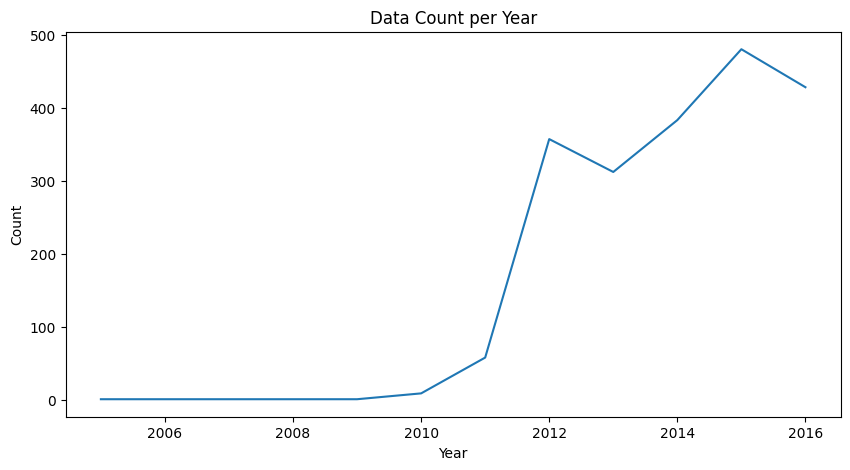

In [ ]:
# prompt: count of data per year
!pip install matplotlib
# Import matplotlib.pyplot
import matplotlib.pyplot as plt
# Group data by year and count the number of entries for each year
year_counts = df.groupby(df['Date'].dt.year)['Symbol'].count()

# Print the year and its corresponding count
for year, count in year_counts.items():
  print(f"Year: {year}, Count: {count}")

# You can also plot this data using matplotlib
plt.figure(figsize=(10, 5))
plt.plot(year_counts.index, year_counts.values)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Data Count per Year')
plt.show()

In [ ]:
# prompt: count of data for sector and year

# Group data by sector and year, and count the number of entries
sector_year_counts = df.groupby(['Sector', df['Date'].dt.year])['Symbol'].count()

# Print the sector, year, and its corresponding count
for (sector, year), count in sector_year_counts.items():
  print(f"Sector: {sector}, Year: {year}, Count: {count}")

# You can also create a pivot table for better visualization
pivot_table = pd.pivot_table(df, values='Symbol', index='Sector', columns=df['Date'].dt.year, aggfunc='count')
print(pivot_table)

Sector: Basic Industries, Year: 2009, Count: 1
Sector: Basic Industries, Year: 2010, Count: 2
Sector: Basic Industries, Year: 2011, Count: 4
Sector: Basic Industries, Year: 2012, Count: 53
Sector: Basic Industries, Year: 2013, Count: 31
Sector: Basic Industries, Year: 2014, Count: 56
Sector: Basic Industries, Year: 2015, Count: 64
Sector: Basic Industries, Year: 2016, Count: 49
Sector: Capital Goods, Year: 2011, Count: 6
Sector: Capital Goods, Year: 2012, Count: 42
Sector: Capital Goods, Year: 2013, Count: 34
Sector: Capital Goods, Year: 2014, Count: 42
Sector: Capital Goods, Year: 2015, Count: 60
Sector: Capital Goods, Year: 2016, Count: 49
Sector: Consumer Durables, Year: 2012, Count: 15
Sector: Consumer Durables, Year: 2013, Count: 10
Sector: Consumer Durables, Year: 2014, Count: 17
Sector: Consumer Durables, Year: 2015, Count: 20
Sector: Consumer Durables, Year: 2016, Count: 12
Sector: Consumer Non-Durables, Year: 2011, Count: 4
Sector: Consumer Non-Durables, Year: 2012, Count: 24


In [ ]:
# prompt: count of data for sector and year sort by year

# Group data by sector and year, and count the number of entries
sector_year_counts = df.groupby(['Sector', df['Date'].dt.year])['Symbol'].count()

# Sort the results by year in ascending order
sector_year_counts = sector_year_counts.sort_index(level=1)

# Print the sector, year, and its corresponding count
for (sector, year), count in sector_year_counts.items():
  print(f"Sector: {sector}, Year: {year}, Count: {count}")

# You can also create a pivot table for better visualization and sort by year
pivot_table = pd.pivot_table(df, values='Symbol', index='Sector', columns=df['Date'].dt.year, aggfunc='count')
pivot_table = pivot_table.sort_index(axis=1)  # Sort columns (years) in ascending order
print(pivot_table)

Sector: Energy, Year: 2005, Count: 1
Sector: Basic Industries, Year: 2009, Count: 1
Sector: Basic Industries, Year: 2010, Count: 2
Sector: Consumer Services, Year: 2010, Count: 2
Sector: Energy, Year: 2010, Count: 1
Sector: Health Care, Year: 2010, Count: 2
Sector: Miscellaneous, Year: 2010, Count: 1
Sector: Technology, Year: 2010, Count: 1
Sector: Basic Industries, Year: 2011, Count: 4
Sector: Capital Goods, Year: 2011, Count: 6
Sector: Consumer Non-Durables, Year: 2011, Count: 4
Sector: Consumer Services, Year: 2011, Count: 8
Sector: Energy, Year: 2011, Count: 13
Sector: Health Care, Year: 2011, Count: 2
Sector: Public Utilities, Year: 2011, Count: 9
Sector: Technology, Year: 2011, Count: 9
Sector: Transportation, Year: 2011, Count: 3
Sector: Basic Industries, Year: 2012, Count: 53
Sector: Capital Goods, Year: 2012, Count: 42
Sector: Consumer Durables, Year: 2012, Count: 15
Sector: Consumer Non-Durables, Year: 2012, Count: 24
Sector: Consumer Services, Year: 2012, Count: 41
Sector: E

In [ ]:
# prompt: total count of symbokks and unique symbosl and Name and unique names

# Total count of symbols
total_symbols = df['Symbol'].count()
print(f"Total Symbols: {total_symbols}")

# Unique symbols
unique_symbols = df['Symbol'].nunique()
print(f"Unique Symbols: {unique_symbols}")

# Total count of names
total_names = df['Name'].count()
print(f"Total Names: {total_names}")

# Unique names
unique_names = df['Name'].nunique()
print(f"Unique Names: {unique_names}")


# prompt: Name	Symbol create mapping for these two, total

name_symbol_mapping = dict(zip(df['Name'], df['Symbol']))

# Print the mapping
print(name_symbol_mapping)

# Get the total number of unique mappings
total_mappings = len(name_symbol_mapping)
print(f"Total unique mappings: {total_mappings}")

Total Symbols: 2029
Unique Symbols: 593
Total Names: 2029
Unique Names: 593
{'Whirlpool Corporation': 'WHR', 'Schlumberger N.V.': 'SLB', 'Honeywell International Inc.': 'HON', 'Sysco Corporation': 'SYY', 'Philip Morris International Inc': 'PM', 'AT&T Inc.': 'T', 'Duke Energy Corporation': 'DUK', 'Danaher Corporation': 'DHR', 'CACI International, Inc.': 'CACI', 'Southwest Gas Holdings, Inc.': 'SWX', 'America Movil, S.A.B. de C.V.': 'AMOV', 'Nektar Therapeutics': 'NKTR', 'WEC Energy Group, Inc.': 'WEC', 'FirstEnergy Corp.': 'FE', 'Vector Group Ltd.': 'VGR', 'CMS Energy Corporation': 'CMS', 'General Electric Company': 'GE', 'Lockheed Martin Corporation': 'LMT', 'Occidental Petroleum Corporation': 'OXY', 'Pinnacle West Capital Corporation': 'PNW', 'CVS Health Corporation': 'CVS', 'Weyerhaeuser Company': 'WY', 'Bottomline Technologies, Inc.': 'EPAY', 'Universal Corporation': 'UVV', 'Emerson Electric Company': 'EMR', 'Marathon Oil Corporation': 'MRO', 'California Resources Corporation': 'CRC

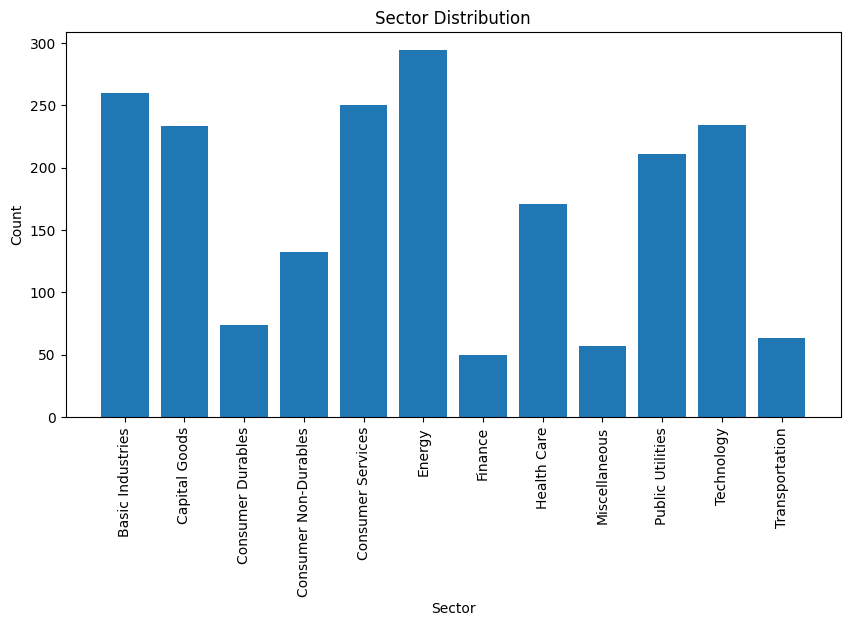

Total unique sectors: 12


In [ ]:
# prompt: group by Sector and count  as a graph and print total unique Sector

# Group by 'Sector' and count occurrences
sector_counts = df.groupby('Sector')['Sector'].count()

# Create a bar graph
plt.figure(figsize=(10, 5))
plt.bar(sector_counts.index, sector_counts.values)
plt.xlabel('Sector')
plt.ylabel('Count')
plt.title('Sector Distribution')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()

# Print total unique sectors
print(f"Total unique sectors: {len(sector_counts)}")

In [ ]:
# prompt: count the numbe of symbols for each year , month and print teh symbok, month, year and count

# Group by year, month, and symbol and count occurrences
symbol_counts = df.groupby([df['Date'].dt.year, df['Date'].dt.month, 'Symbol'])['Symbol'].count()

# Print the symbol, month, year, and count
for (year, month, symbol), count in symbol_counts.items():
  print(f"Symbol: {symbol}, Month: {month}, Year: {year}, Count: {count}")

Symbol: TOT, Month: 8, Year: 2005, Count: 1
Symbol: X, Month: 4, Year: 2009, Count: 1
Symbol: MMP, Month: 8, Year: 2010, Count: 1
Symbol: THC, Month: 8, Year: 2010, Count: 1
Symbol: PBI, Month: 9, Year: 2010, Count: 1
Symbol: JBL, Month: 11, Year: 2010, Count: 1
Symbol: TPC, Month: 11, Year: 2010, Count: 1
Symbol: BIIB, Month: 12, Year: 2010, Count: 1
Symbol: CRS, Month: 12, Year: 2010, Count: 1
Symbol: DIS, Month: 12, Year: 2010, Count: 1
Symbol: IRS, Month: 12, Year: 2010, Count: 1
Symbol: CVE, Month: 1, Year: 2011, Count: 1
Symbol: ETN, Month: 1, Year: 2011, Count: 1
Symbol: NM, Month: 1, Year: 2011, Count: 1
Symbol: CCOI, Month: 2, Year: 2011, Count: 1
Symbol: DVN, Month: 3, Year: 2011, Count: 1
Symbol: EC, Month: 3, Year: 2011, Count: 1
Symbol: GFF, Month: 3, Year: 2011, Count: 1
Symbol: NBR, Month: 3, Year: 2011, Count: 1
Symbol: NWE, Month: 3, Year: 2011, Count: 1
Symbol: PEP, Month: 3, Year: 2011, Count: 1
Symbol: PHI, Month: 3, Year: 2011, Count: 1
Symbol: BCE, Month: 4, Year:

In [ ]:
# prompt: count the numbe of symbols for each year  and print teh symbok, year and count

# Group by year and symbol and count occurrences
symbol_year_counts = df.groupby([df['Date'].dt.year, 'Symbol'])['Symbol'].count()

# Print the symbol, year, and count
for (year, symbol), count in symbol_year_counts.items():
  print(f"Symbol: {symbol}, Year: {year}, Count: {count}")

Symbol: TOT, Year: 2005, Count: 1
Symbol: X, Year: 2009, Count: 1
Symbol: BIIB, Year: 2010, Count: 1
Symbol: CRS, Year: 2010, Count: 1
Symbol: DIS, Year: 2010, Count: 1
Symbol: IRS, Year: 2010, Count: 1
Symbol: JBL, Year: 2010, Count: 1
Symbol: MMP, Year: 2010, Count: 1
Symbol: PBI, Year: 2010, Count: 1
Symbol: THC, Year: 2010, Count: 1
Symbol: TPC, Year: 2010, Count: 1
Symbol: BCE, Year: 2011, Count: 1
Symbol: BG, Year: 2011, Count: 1
Symbol: BZH, Year: 2011, Count: 1
Symbol: CCOI, Year: 2011, Count: 1
Symbol: CHK, Year: 2011, Count: 1
Symbol: CLGX, Year: 2011, Count: 2
Symbol: CMI, Year: 2011, Count: 2
Symbol: CSX, Year: 2011, Count: 1
Symbol: CVE, Year: 2011, Count: 1
Symbol: CVGI, Year: 2011, Count: 1
Symbol: DIS, Year: 2011, Count: 1
Symbol: DVN, Year: 2011, Count: 1
Symbol: EC, Year: 2011, Count: 1
Symbol: EIX, Year: 2011, Count: 1
Symbol: ENDP, Year: 2011, Count: 1
Symbol: EPR, Year: 2011, Count: 1
Symbol: EQT, Year: 2011, Count: 1
Symbol: ETN, Year: 2011, Count: 1
Symbol: EXC, 

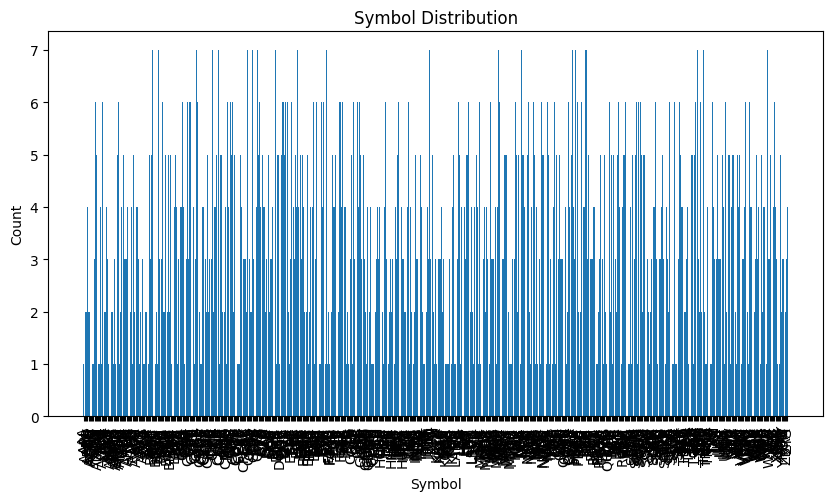

Symbol: AA, Count: 1
Symbol: AAL, Count: 2
Symbol: AAPL, Count: 2
Symbol: ABB, Count: 4
Symbol: ABBV, Count: 2
Symbol: ABG, Count: 2
Symbol: ACCO, Count: 6
Symbol: ACHC, Count: 1
Symbol: ACIW, Count: 1
Symbol: ACM, Count: 3
Symbol: ACN, Count: 6
Symbol: ADM, Count: 5
Symbol: ADSW, Count: 1
Symbol: ADT, Count: 1
Symbol: AEE, Count: 4
Symbol: AES, Count: 1
Symbol: AGCO, Count: 6
Symbol: AIN, Count: 2
Symbol: ALB, Count: 2
Symbol: ALGT, Count: 4
Symbol: ALKS, Count: 3
Symbol: ALLE, Count: 1
Symbol: ALV, Count: 1
Symbol: AMAG, Count: 2
Symbol: AMAT, Count: 2
Symbol: AMC, Count: 1
Symbol: AMCX, Count: 3
Symbol: AMD, Count: 1
Symbol: AMGN, Count: 5
Symbol: AMKR, Count: 6
Symbol: AMOV, Count: 1
Symbol: ANTM, Count: 2
Symbol: AON, Count: 4
Symbol: APA, Count: 5
Symbol: APD, Count: 3
Symbol: APH, Count: 3
Symbol: AR, Count: 3
Symbol: ARCO, Count: 4
Symbol: ASNA, Count: 2
Symbol: AT, Count: 2
Symbol: ATI, Count: 4
Symbol: ATKR, Count: 1
Symbol: ATO, Count: 5
Symbol: AUY, Count: 2
Symbol: AVA, Co

In [ ]:
# prompt: print count of symboks and count in plot

import matplotlib.pyplot as plt

# ... (Your existing code) ...

# Group by 'Symbol' and count occurrences
symbol_counts = df.groupby('Symbol')['Symbol'].count()

# Create a bar graph
plt.figure(figsize=(10, 5))
plt.bar(symbol_counts.index, symbol_counts.values)
plt.xlabel('Symbol')
plt.ylabel('Count')
plt.title('Symbol Distribution')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()

# Print the symbol and count
for symbol, count in symbol_counts.items():
    print(f"Symbol: {symbol}, Count: {count}")


In [ ]:
# prompt: Fikter data for one symbok and print the data

# Assuming you want to filter data for a specific symbol, e.g., 'AAPL'

symbol_to_filter = 'AAPL'  # Replace with the symbol you want to filter

filtered_df = df[df['Symbol'] == symbol_to_filter]

# Print the filtered data
print(filtered_df)

    Rating        Name Symbol                  Rating Agency Name       Date  \
977     AA  Apple Inc.   AAPL  Standard & Poor's Ratings Services 2016-05-20   
978     AA  Apple Inc.   AAPL  Standard & Poor's Ratings Services 2015-05-28   

         Sector  currentRatio  quickRatio  cashRatio  daysOfSalesOutstanding  \
977  Technology      1.108771    0.725096   0.262002               26.313608   
978  Technology      1.080113    0.670423   0.218194               34.863645   

     ...  effectiveTaxRate  freeCashFlowOperatingCashFlowRatio  \
977  ...          0.263683                            0.858637   
978  ...          0.261261                            0.835664   

     freeCashFlowPerShare  cashPerShare  companyEquityMultiplier  \
977             12.128089      7.230655                 2.433740   
978              8.199722      4.120730                 2.078397   

     ebitPerRevenue  enterpriseValueMultiple  operatingCashFlowPerShare  \
977        0.310271                 7.8

In [ ]:
# Display the dimensions
df_rating=df.copy()

print("The credit rating dataset has", df.shape[0], "records, each with", df.shape[1],
    "attributes")

df.Rating.value_counts()


The credit rating dataset has 2029 records, each with 31 attributes


,count
Rating,
BBB,671
BB,490
A,398
B,302
AA,89
CCC,64
AAA,7
CC,5
C,2


In [ ]:

rating_dict = {'AAA':'Lowest Risk',
               'AA':'Low Risk',
               'A':'Low Risk',
               'BBB':'Medium Risk',
               'BB':'High Risk',
               'B':'High Risk',
               'CCC':'Highest Risk',
               'CC':'Highest Risk',
               'C':'Highest Risk',
               'D':'In Default'}





df_rating.Rating = df_rating.Rating.map(rating_dict)

In [ ]:
df.Rating.value_counts()

,count
Rating,
BBB,671
BB,490
A,398
B,302
AA,89
CCC,64
AAA,7
CC,5
C,2


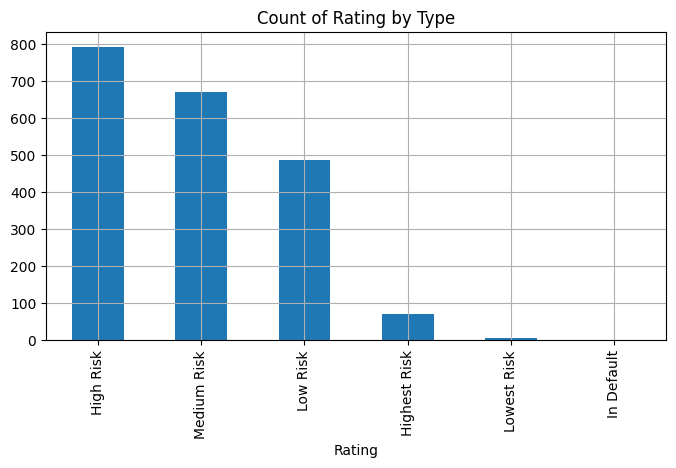

In [ ]:

ax = df_rating['Rating'].value_counts().plot(kind='bar',
                                             figsize=(8,4),
                                             title="Count of Rating by Type",
                                             grid=True)

Rating: Low Risk, Year: 2005, Count: 1
Rating: High Risk, Year: 2009, Count: 1
Rating: High Risk, Year: 2010, Count: 3
Rating: Highest Risk, Year: 2010, Count: 1
Rating: Low Risk, Year: 2010, Count: 1
Rating: Medium Risk, Year: 2010, Count: 4
Rating: High Risk, Year: 2011, Count: 26
Rating: Highest Risk, Year: 2011, Count: 1
Rating: Low Risk, Year: 2011, Count: 9
Rating: Medium Risk, Year: 2011, Count: 22
Rating: High Risk, Year: 2012, Count: 124
Rating: Highest Risk, Year: 2012, Count: 11
Rating: Low Risk, Year: 2012, Count: 80
Rating: Medium Risk, Year: 2012, Count: 142
Rating: High Risk, Year: 2013, Count: 116
Rating: Highest Risk, Year: 2013, Count: 14
Rating: Low Risk, Year: 2013, Count: 78
Rating: Lowest Risk, Year: 2013, Count: 3
Rating: Medium Risk, Year: 2013, Count: 101
Rating: High Risk, Year: 2014, Count: 143
Rating: Highest Risk, Year: 2014, Count: 12
Rating: Low Risk, Year: 2014, Count: 117
Rating: Lowest Risk, Year: 2014, Count: 2
Rating: Medium Risk, Year: 2014, Count: 

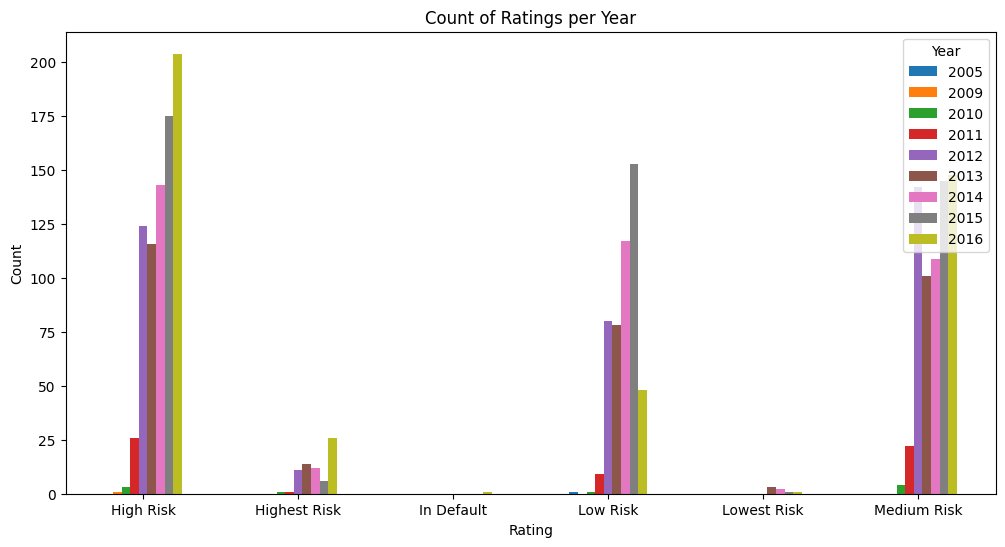

In [ ]:
# prompt: count of type of Ratings per year print it, plot it

# Group by year and rating, and count occurrences
rating_year_counts = df_rating.groupby([df_rating['Date'].dt.year, 'Rating'])['Rating'].count()

# Print the rating, year, and count
for (year, rating), count in rating_year_counts.items():
    print(f"Rating: {rating}, Year: {year}, Count: {count}")

# Create a pivot table to visualize the counts
pivot_table_rating_year = pd.pivot_table(df_rating, values='Symbol', index='Rating', columns=df_rating['Date'].dt.year, aggfunc='count')
print(pivot_table_rating_year)


# Plot the rating counts for each year
pivot_table_rating_year.plot(kind='bar', figsize=(12, 6), title='Count of Ratings per Year')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Year', loc='upper right')
plt.show()

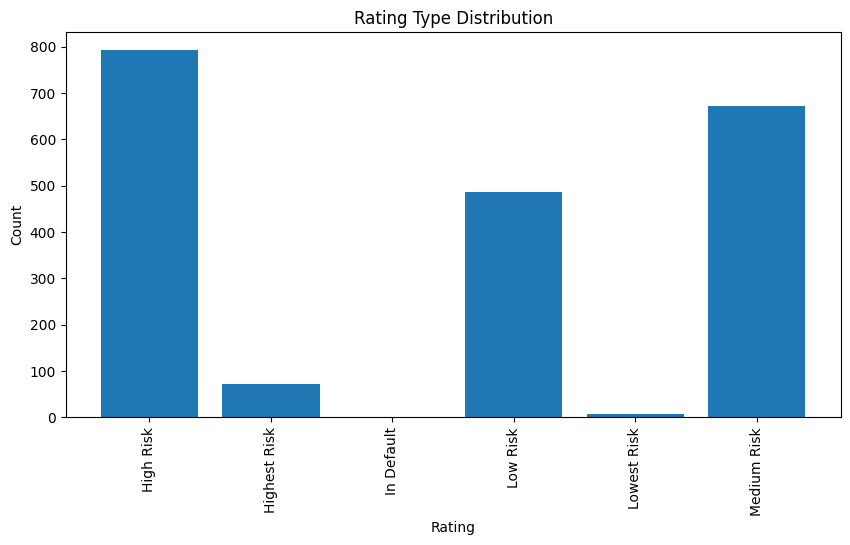

Rating: High Risk, Count: 792
Rating: Highest Risk, Count: 71
Rating: In Default, Count: 1
Rating: Low Risk, Count: 487
Rating: Lowest Risk, Count: 7
Rating: Medium Risk, Count: 671


In [ ]:
# prompt: plot count of types of rating from df_rating and count

# Assuming df_rating is your DataFrame and you want to plot the count of each rating type

# Group by 'Rating' and count occurrences
rating_counts = df_rating.groupby('Rating')['Rating'].count()

# Create a bar graph
plt.figure(figsize=(10, 5))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Type Distribution')
plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
plt.show()

# Print the rating and count
for rating, count in rating_counts.items():
    print(f"Rating: {rating}, Count: {count}")

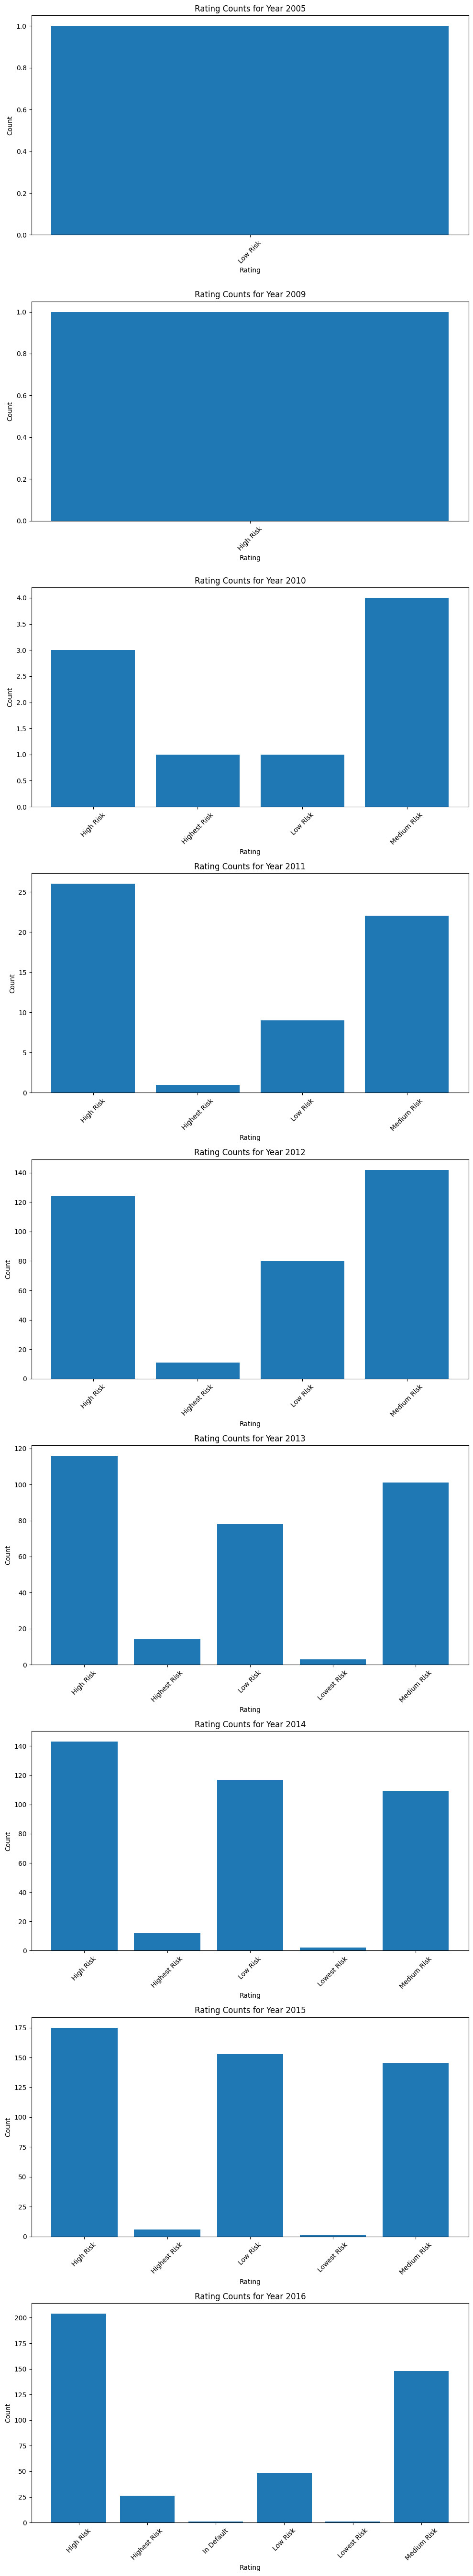


Statistics for Year 2005:
Rating
Low Risk    1
Name: Rating, dtype: int64

Statistics for Year 2009:
Rating
High Risk    1
Name: Rating, dtype: int64

Statistics for Year 2010:
Rating
High Risk       3
Highest Risk    1
Low Risk        1
Medium Risk     4
Name: Rating, dtype: int64

Statistics for Year 2011:
Rating
High Risk       26
Highest Risk     1
Low Risk         9
Medium Risk     22
Name: Rating, dtype: int64

Statistics for Year 2012:
Rating
High Risk       124
Highest Risk     11
Low Risk         80
Medium Risk     142
Name: Rating, dtype: int64

Statistics for Year 2013:
Rating
High Risk       116
Highest Risk     14
Low Risk         78
Lowest Risk       3
Medium Risk     101
Name: Rating, dtype: int64

Statistics for Year 2014:
Rating
High Risk       143
Highest Risk     12
Low Risk        117
Lowest Risk       2
Medium Risk     109
Name: Rating, dtype: int64

Statistics for Year 2015:
Rating
High Risk       175
Highest Risk      6
Low Risk        153
Lowest Risk       1
Me

In [ ]:
# prompt: Show plot for each year the types of rating and the count , one plot for each year  as subplots and print statustics yearwise

import matplotlib.pyplot as plt

# Group data by year and rating, and count occurrences
rating_year_counts = df_rating.groupby([df_rating['Date'].dt.year, 'Rating'])['Rating'].count()

# Create subplots for each year
fig, axes = plt.subplots(nrows=len(rating_year_counts.index.levels[0]), ncols=1, figsize=(10, 6 * len(rating_year_counts.index.levels[0])))

for i, year in enumerate(rating_year_counts.index.levels[0]):
  year_data = rating_year_counts.loc[year]
  ax = axes[i]
  ax.bar(year_data.index, year_data.values)
  ax.set_title(f"Rating Counts for Year {year}")
  ax.set_xlabel("Rating")
  ax.set_ylabel("Count")
  ax.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

# Print yearwise statistics
for year in rating_year_counts.index.levels[0]:
  year_data = rating_year_counts.loc[year]
  print(f"\nStatistics for Year {year}:")
  print(year_data)

In [ ]:
df_rating.head()

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,Low Risk,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,Medium Risk,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,Medium Risk,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,Medium Risk,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,Medium Risk,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [ ]:
# prompt: save df_rating to drive

df_rating.to_csv('/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/Data/df_rating.csv', index=False)

In [ ]:
# prompt: list all columns
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/

print(df_rating.columns)
import pandas as pd
import os

# Read the CSV file
df = df_rating
# Convert the 'date_column' to datetime format
df['date_column'] = pd.to_datetime(df['Date'])

# Extract the year and create a new column 'year'
df['Year'] = df['date_column'].dt.year

# Extract relevant columns
df = df[['Year', 'Name', 'Symbol', 'Rating']]

# Ensure the 'Year' column is of integer type
df['Year'] = df['Year'].astype(int)

# Filter the DataFrame for years 2011 to 2016
df_filtered = df[df['Year'].between(2011, 2016)]

# Group by 'Year' and save each group to a separate CSV file
for year, group in df_filtered.groupby('Year'):
    # Define the filename
    filename = 'labelled_data_'+str(year)+'.csv'

    # Save the group to a CSV file
    group.to_csv(filename, index=False)
    print(f'Saved data for year {year} to {filename}')


/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction
Index(['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector',
       'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding',
       'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin',
       'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed',
       'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover',
       'debtEquityRatio', 'debtRatio', 'effectiveTaxRate',
       'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare',
       'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue',
       'enterpriseValueMultiple', 'operatingCashFlowPerShare',
       'operatingCashFlowSalesRatio', 'payablesTurnover'],
      dtype='object')
Saved data for year 2011 to labelled_data_2011.csv
Saved data for year 2012 to labelled_data_2012.csv
Saved data for year 2013 to labelled_data_2013.csv
Saved data for year 2014 to labelled_data_2014.csv
Saved data for year 20

<ipython-input-243-54d473694445>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype(int)


In [ ]:
# Statistical summary
df_rating.describe()

,Date,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,date_column,Year
count,2029,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,2029.000000,...,2.029000e+03,2.029000e+03,2029.000000,2029.000000,2029.000000,2.029000e+03,2029.000000,2029.000000,2029,2029.000000
mean,2014-07-31 06:53:03.045835264,3.529607,2.653986,0.667364,333.795606,0.278447,0.431483,0.497968,0.587322,-37.517928,...,5.094719e+03,4.227549e+03,3.323579,0.437454,48.287985,6.515123e+03,1.447653,38.002718,2014-07-31 06:53:03.045835264,2014.042385
min,2005-08-16 00:00:00,-0.932005,-1.893266,-0.192736,-811.845623,-101.845815,-124.343612,-14.800817,-124.343612,-40213.178290,...,-4.912742e+03,-1.915035e+01,-2555.419643,-124.343612,-3749.921337,-1.195049e+04,-4.461837,-76.662850,2005-08-16 00:00:00,2005.000000
25%,2013-04-29 00:00:00,1.071930,0.602825,0.130630,22.905093,0.021006,0.025649,0.233127,0.044610,0.019176,...,4.119924e-01,1.566038e+00,2.046822,0.028057,6.238066,2.356735e+00,0.073886,2.205912,2013-04-29 00:00:00,2013.000000
50%,2014-09-24 00:00:00,1.493338,0.985679,0.297493,42.374120,0.064753,0.084965,0.414774,0.107895,0.045608,...,2.131742e+00,3.686513e+00,2.652456,0.087322,9.274398,4.352584e+00,0.133050,5.759722,2014-09-24 00:00:00,2014.000000
75%,2015-11-10 00:00:00,2.166891,1.453820,0.624906,59.323563,0.114807,0.144763,0.849693,0.176181,0.077468,...,4.230253e+00,8.086152e+00,3.658331,0.149355,12.911759,7.319759e+00,0.240894,9.480892,2015-11-10 00:00:00,2015.000000
max,2016-12-23 00:00:00,1725.505005,1139.541703,125.917417,115961.637400,198.517873,309.694856,2.702533,410.182214,0.487826,...,5.753380e+06,4.786803e+06,2562.871795,309.694856,11153.607090,6.439270e+06,688.526591,20314.880400,2016-12-23 00:00:00,2016.000000
std,NaN,44.052361,32.944817,3.583943,4447.839583,6.064134,8.984982,0.525307,11.224622,1166.172220,...,1.469156e+05,1.224000e+05,87.529866,8.984299,529.118961,1.775290e+05,19.483294,758.923588,NaN,1.522409


In [ ]:
# Create Labels with time

In [ ]:
# import pandas as pd

# # Load the dataset
# df = df_rating

# # Function to create triplets
# def create_triplet(subject, predicate, obj):
#     return (subject, predicate, obj)

# # List to hold all triplets
# triplets = []

# # Extract Entities and Relationships
# def extract_entities_and_relations(df):
#     # Iterate through the rows of the dataframe
#     for index, row in df.iterrows():
#         company = row['Name']

#         # Company to sector relationship
#         if pd.notnull(row['Sector']):
#             triplets.append(create_triplet(company, 'operatesInSector', row['Sector']))

#         # Company to credit rating relationship
#         if pd.notnull(row['Rating']):
#             triplets.append(create_triplet(company, 'hasRating', row['Rating']))
#             if pd.notnull(row['Rating Agency Name']):
#                 triplets.append(create_triplet(row['Rating'], 'ratedBy', row['Rating Agency Name']))

#         # Financial metrics relationships
#         financial_metrics = ['currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
#                              'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
#                              'returnOnAssets', 'returnOnEquity',
#                              'freeCashFlowOperatingCashFlowRatio', 'grossProfitMargin']

#         for metric in financial_metrics:
#             if pd.notnull(row[metric]):
#                 metric_value = f"{metric}: {row[metric]}"
#                 #triplets.append(create_triplet(company, 'hasMetric', metric_value))
#                 triplets.append(create_triplet(company, metric, row[metric]))


#         # Temporal relationship (date)
#         if pd.notnull(row['Date']):
#             triplets.append(create_triplet(company, 'reportedIn', row['Date']))

# # Call the function to extract entities and relationships
# extract_entities_and_relations(df)

# # Output triplets
# for triplet in triplets:
#     print(triplet)

# # Optionally, you can save the triplets to a file
# triplets_df = pd.DataFrame(triplets, columns=['Subject', 'Predicate', 'Object'])
# triplets_df.to_csv('credit_risk_triplets.csv', index=False)


In [ ]:
import pandas as pd

# Load the dataset
df = df_rating

# Function to create triplets
def create_triplet(subject, predicate, obj):
    return (subject, predicate, obj)

# List to hold all triplets
triplets = []

# Extract Entities and Relationships
def extract_entities_and_relations(df):
    # Iterate through the rows of the dataframe
    for index, row in df.iterrows():
        company = row['Name']

        # Company to sector relationship
        if pd.notnull(row['Sector']):
            triplets.append(create_triplet(company, 'operatesInSector', row['Sector']))

        # Company to credit rating relationship
        if pd.notnull(row['Rating']):
            triplets.append(create_triplet(company, 'hasRating', row['Rating']))
            if pd.notnull(row['Rating Agency Name']):
                triplets.append(create_triplet(row['Rating'], 'ratedBy', row['Rating Agency Name']))

        # Financial metrics relationships
        financial_metrics = ['currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
                             'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
                             'returnOnAssets', 'returnOnEquity',
                             'freeCashFlowOperatingCashFlowRatio', 'grossProfitMargin']

        for metric in financial_metrics:
            if pd.notnull(row[metric]):
                metric_value = row[metric]  # Use the metric value directly
                triplets.append(create_triplet(company, metric, metric_value))  # Use metric name as predicate

        # Temporal relationship (date)
        if pd.notnull(row['Date']):
            triplets.append(create_triplet(company, 'reportedIn', row['Date']))

# Call the function to extract entities and relationships
extract_entities_and_relations(df)

# Output triplets
for triplet in triplets:
    print(triplet)

# Optionally, you can save the triplets to a file
triplets_df = pd.DataFrame(triplets, columns=['Subject', 'Predicate', 'Object'])
triplets_df.to_csv('credit_risk_triplets1.csv', index=False)


Streaming output truncated to the last 5000 lines.
('Accenture plc', 'returnOnAssets', 0.144784385)
('Accenture plc', 'returnOnEquity', 0.587188908)
('Accenture plc', 'freeCashFlowOperatingCashFlowRatio', 0.882700577)
('Accenture plc', 'grossProfitMargin', 0.306611537)
('Accenture plc', 'reportedIn', Timestamp('2012-06-15 00:00:00'))
('Accenture plc', 'operatesInSector', 'Miscellaneous')
('Accenture plc', 'hasRating', 'Low Risk')
('Low Risk', 'ratedBy', "Standard & Poor's Ratings Services")
('Accenture plc', 'currentRatio', 1.459221221)
('Accenture plc', 'quickRatio', 1.076659591)
('Accenture plc', 'cashRatio', 0.603243116)
('Accenture plc', 'debtEquityRatio', 2.128112791)
('Accenture plc', 'debtRatio', 0.680318433)
('Accenture plc', 'netProfitMargin', 0.092283222)
('Accenture plc', 'operatingProfitMargin', 0.134919386)
('Accenture plc', 'returnOnAssets', 0.16405041)
('Accenture plc', 'returnOnEquity', 0.513168185)
('Accenture plc', 'freeCashFlowOperatingCashFlowRatio', 0.907670065)
('

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction

/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction


In [ ]:
triplets_df.to_csv('credit_risk_triplets.csv', index=False)

In [ ]:
# !pip install networkx matplotlib

# import networkx as nx
# # Initialize a directed graph
# G = nx.DiGraph()
# i=0
# # Add edges to the graph based on triplets
# for _, row in triplets_df.iterrows():
#     subject = row['Subject']
#     predicate = row['Predicate']
#     obj = row['Object']
#     i=i=+1
#     if (i<=10):

#       G.add_edge(subject, obj, label=predicate)
#     else:
#       break


In [ ]:

# # Draw the knowledge graph
# plt.figure(figsize=(15, 15))
# pos = nx.spring_layout(G, k=0.3, seed=42)  # Positioning for nodes

# # Draw nodes and edges
# nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
# nx.draw_networkx_edges(G, pos, arrows=True)
# nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif")

# # Draw edge labels
# edge_labels = nx.get_edge_attributes(G, 'label')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="red")

# plt.title("Credit Risk Knowledge Graph")
# plt.show()

In [ ]:
triplets_df.head()

,Subject,Predicate,Object
0,Whirlpool Corporation,operatesInSector,Consumer Durables
1,Whirlpool Corporation,hasRating,Low Risk
2,Low Risk,ratedBy,Egan-Jones Ratings Company
3,Whirlpool Corporation,currentRatio,0.945894
4,Whirlpool Corporation,quickRatio,0.426395


In [ ]:
# import os
# import pandas as pd

# # Function to extract triplets for a given year
# def extract_entities_and_relations(df, year):
#     """
#     Extracts triplets for a given year from the dataset.
#     """
#     triplets = []

#     # Filter data for the specific year
#     df_year = df[df['Date'].str.contains(str(year), na=False)]

#     for _, row in df_year.iterrows():
#         company = row['Name']

#         # Company to Sector relationship
#         if pd.notnull(row['Sector']):
#             triplets.append((company, 'operatesInSector', row['Sector']))

#         # Company to Credit Rating relationship
#         if pd.notnull(row['Rating']):
#             triplets.append((company, 'hasRating', row['Rating']))
#             if pd.notnull(row['Rating Agency Name']):
#                 triplets.append((row['Rating'], 'ratedBy', row['Rating Agency Name']))

#         # Financial Metrics Relationships
#         financial_metrics = [
#             'currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
#             'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
#             'returnOnAssets', 'returnOnEquity', 'freeCashFlowOperatingCashFlowRatio',
#             'grossProfitMargin'
#         ]

#         for metric in financial_metrics:
#             if pd.notnull(row[metric]):
#                 triplets.append((company, metric, row[metric]))

#         # Temporal Relationship (Date)
#         if pd.notnull(row['Date']):
#             triplets.append((company, 'reportedIn', row['Date']))

#     return triplets

# # Dictionary to store company presence across years
# company_presence = {}

# # Extract triplets for each year and save to CSV files
# years = [2011, 2012, 2013, 2014, 2015, 2016]

# for year in years:
#     print(f"Processing {year}...")
#     triplets = extract_entities_and_relations(df, year)
#     triplets_df = pd.DataFrame(triplets, columns=['Subject', 'Predicate', 'Object'])

#     # Save triplets to CSV
#     filename = f'credit_risk_triplets_{year}.csv'
#     triplets_df.to_csv(filename, index=False)
#     print(f"Saved triplets for {year} to {filename}")

#     # Track companies appearing in each year
#     companies_in_year = set(triplets_df[triplets_df['Predicate'] == 'reportedIn']['Subject'])

#     for company in companies_in_year:
#         if company in company_presence:
#             company_presence[company].add(year)
#         else:
#             company_presence[company] = {year}

# # Identify companies present across all years
# companies_all_years = [company for company, years_present in company_presence.items() if len(years_present) == len(years)]
# print("\nCompanies present across all years:")
# print(companies_all_years)


In [ ]:
import pandas as pd
import glob

# Define the file paths (assuming they are in the same directory)
file_paths = ["credit_risk_triplets_2012.csv", "credit_risk_triplets_2013.csv", "credit_risk_triplets_2014.csv"]

def extract_companies(file_path):
    """Reads a CSV file and extracts unique companies from the 'Subject' column."""
    df = pd.read_csv(file_path)
    return set(df['Subject'].dropna())

# Extract companies for each year
companies_2012 = extract_companies("credit_risk_triplets_2012.csv")
companies_2013 = extract_companies("credit_risk_triplets_2013.csv")
companies_2014 = extract_companies("credit_risk_triplets_2014.csv")

# Find companies present in all three years
common_companies = companies_2012 & companies_2013 & companies_2014

# Display results
if common_companies:
    print("Companies present in 2012, 2013, and 2014:")
    for company in common_companies:
        print(company)
else:
    print("No company found in all three years.")

#print Accenture plc value for each year


Companies present in 2012, 2013, and 2014:
Cogent Communications Holdings, Inc.
MGM Resorts International
Vishay Intertechnology, Inc.
Xcel Energy Inc.
Transocean Ltd.
Verint Systems Inc.
Foot Locker, Inc.
General Mills, Inc.
TEGNA Inc.
Service Corporation International
Newell Brands Inc.
V.F. Corporation
International Business Machines Corporation
Stryker Corporation
Hormel Foods Corporation
Southwest Gas Holdings, Inc.
Silgan Holdings Inc.
Campbell Soup Company
Plains All American Pipeline, L.P.
Harsco Corporation
Pepsico, Inc.
QEP Resources, Inc.
Target Corporation
ManpowerGroup
Altria Group
Valmont Industries, Inc.
HollyFrontier Corporation
Equifax, Inc.
Vulcan Materials Company
Edison International
Owens Corning Inc
Fidelity National Information Services, Inc.
Great Lakes Dredge & Dock Corporation
ConocoPhillips
United States Steel Corporation
Chevron Corporation
Rayonier Inc.
Eastman Chemical Company
SM Energy Company
Olin Corporation
Acco Brands Corporation
Sonoco Products Compa

In [ ]:
import pandas as pd
import glob

# Define the file paths (assuming they are in the same directory)
file_paths = ["credit_risk_triplets_2012.csv", "credit_risk_triplets_2013.csv", "credit_risk_triplets_2014.csv"]

def extract_companies(file_path):
    """Reads a CSV file and extracts unique companies from the 'Subject' column."""
    df = pd.read_csv(file_path)
    return set(df['Subject'].dropna()), df

# Extract companies for each year
companies_2012, df_2012 = extract_companies("credit_risk_triplets_2012.csv")
companies_2013, df_2013 = extract_companies("credit_risk_triplets_2013.csv")
companies_2014, df_2014 = extract_companies("credit_risk_triplets_2014.csv")

# Find companies present in all three years
common_companies = companies_2012 & companies_2013 & companies_2014

# Display results
if common_companies:
    print("Companies present in 2012, 2013, and 2014:")
    for company in common_companies:
        print(company)
else:
    print("No company found in all three years.")

# Print values for Accenture plc
for year, df in zip([2012, 2013, 2014], [df_2012, df_2013, df_2014]):
    values = df[df['Subject'] == "Accenture plc"]
    print(f"Values for Accenture plc in {year}:")
    print(values)


Companies present in 2012, 2013, and 2014:
Cogent Communications Holdings, Inc.
MGM Resorts International
Vishay Intertechnology, Inc.
Xcel Energy Inc.
Transocean Ltd.
Verint Systems Inc.
Foot Locker, Inc.
General Mills, Inc.
TEGNA Inc.
Service Corporation International
Newell Brands Inc.
V.F. Corporation
International Business Machines Corporation
Stryker Corporation
Hormel Foods Corporation
Southwest Gas Holdings, Inc.
Silgan Holdings Inc.
Campbell Soup Company
Plains All American Pipeline, L.P.
Harsco Corporation
Pepsico, Inc.
QEP Resources, Inc.
Target Corporation
ManpowerGroup
Altria Group
Valmont Industries, Inc.
HollyFrontier Corporation
Equifax, Inc.
Vulcan Materials Company
Edison International
Owens Corning Inc
Fidelity National Information Services, Inc.
Great Lakes Dredge & Dock Corporation
ConocoPhillips
United States Steel Corporation
Chevron Corporation
Rayonier Inc.
Eastman Chemical Company
SM Energy Company
Olin Corporation
Acco Brands Corporation
Sonoco Products Compa

In [ ]:
import pandas as pd
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Load the triplets
triplets_df = pd.read_csv('credit_risk_triplets.csv')

# Create a directed graph from the triplets
G = nx.DiGraph()

# Populate the graph with nodes and edges, storing financial metrics as node attributes
for _, row in triplets_df.iterrows():
    subject = row['Subject']
    predicate = row['Predicate']
    obj = row['Object']

    # Ensure the subject node exists in the graph
    if subject not in G:
        G.add_node(subject)

    # Add relationships as edges with labels
    if predicate == 'hasRating':
        G.add_edge(subject, obj, label=predicate)
        # Store the rating as a node attribute for easy access
        G.nodes[subject]['rating'] = obj

    elif predicate == 'ratedBy':
        G.add_edge(subject, obj, label=predicate)

    elif predicate == 'operatesInSector':
        G.nodes[subject]['sector'] = obj

    elif predicate == 'reportedIn':
        G.nodes[subject]['reportingDate'] = obj

    # Add financial metrics as node attributes
    elif predicate in ['currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
                       'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
                       'returnOnAssets', 'returnOnEquity', 'freeCashFlowOperatingCashFlowRatio',
                       'grossProfitMargin']:
        # Extract the numerical part of the metric
        metric_value = float(obj.split(": ")[1])
        G.nodes[subject][predicate] = metric_value

# Extract financial metrics and ratings as features for nodes
financial_metrics = ['currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
                     'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
                     'returnOnAssets', 'returnOnEquity', 'freeCashFlowOperatingCashFlowRatio',
                     'grossProfitMargin']
features = []
labels = []

# Loop over nodes to collect features and labels for nodes with a rating and complete metrics
for node in G.nodes:
    if 'rating' in G.nodes[node] and all(metric in G.nodes[node] for metric in financial_metrics):
        feature_values = [G.nodes[node][metric] for metric in financial_metrics]
        features.append(feature_values)
        labels.append(G.nodes[node]['rating'])

# Debugging: check the number of nodes with full features and ratings
print(f"Total nodes with complete metrics and rating: {len(features)}")

# Ensure there is data for training
if len(features) == 0:
    print("No nodes found with complete financial metrics and rating.")
else:
    # Create a DataFrame for features and labels
    df_features = pd.DataFrame(features, columns=financial_metrics)
    df_labels = pd.Series(labels)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(df_features, df_labels, test_size=0.2, random_state=42)

    # Train a logistic regression model for simplicity
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Predict missing ratings for nodes with complete metrics but no rating
    for node in G.nodes:
        if 'rating' not in G.nodes[node] and all(metric in G.nodes[node] for metric in financial_metrics):
            feature_values = [G.nodes[node].get(metric) for metric in financial_metrics]
            predicted_rating = model.predict([feature_values])
            print(f"Predicted rating for {node}: {predicted_rating[0]}")


IndexError: list index out of range

In [ ]:
df_rating.head()

# Train without time dimension and save results
# Compare with time dimention approach

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,date_column,Year
0,Low Risk,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2015-11-27,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655,2015-11-27,2015
1,Medium Risk,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2014-02-13,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846,2014-02-13,2014
2,Medium Risk,Whirlpool Corporation,WHR,Fitch Ratings,2015-03-06,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510,2015-03-06,2015
3,Medium Risk,Whirlpool Corporation,WHR,Fitch Ratings,2012-06-15,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150,2012-06-15,2012
4,Medium Risk,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,2016-10-24,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790,2016-10-24,2016


In [ ]:
#((((((((((((((((()))))))))))))))))

import pandas as pd

# Load the dataset (Ensure 'Date' is in datetime format)
df=df_rating

# Function to create triplets with Rating and Date as additional columns
def extract_entities_and_relations(df, year):
    triplets = []
    # Filter the data for the specific year
    df_year = df[df['Date'].dt.year == year]

    # Iterate through the rows of the filtered dataframe
    for index, row in df_year.iterrows():
        company = row['Name']
        rating = row['Rating'] if pd.notnull(row['Rating']) else "Unknown"
        date = row['Date'].strftime("%Y-%m-%d") if pd.notnull(row['Date']) else "Unknown"

        # Company to sector relationship
        if pd.notnull(row['Sector']):
            triplets.append((company, 'operatesInSector', row['Sector'], rating, date))

        # Company to credit rating relationship
        if pd.notnull(row['Rating']):
            triplets.append((company, 'hasRating', row['Rating'], rating, date))

            # Rating Agency relationship
            if pd.notnull(row['Rating Agency Name']):
                triplets.append((row['Rating'], 'ratedBy', row['Rating Agency Name'], rating, date))

        # Financial metrics relationships
        financial_metrics = ['currentRatio', 'quickRatio', 'cashRatio', 'debtEquityRatio',
                             'debtRatio', 'netProfitMargin', 'operatingProfitMargin',
                             'returnOnAssets', 'returnOnEquity',
                             'freeCashFlowOperatingCashFlowRatio', 'grossProfitMargin']

        for metric in financial_metrics:
            if pd.notnull(row[metric]):
                triplets.append((company, metric, row[metric], rating, date))

        # Temporal relationship (date)
        if pd.notnull(row['Date']):
            triplets.append((company, 'reportedIn', date, rating, date))

    return triplets

# Extract triplets for each year and save to CSV files with Rating and Date as columns
for year in [2011, 2012, 2013, 2014, 2015, 2016]:
    triplets = extract_entities_and_relations(df_rating, year)
    triplets_df = pd.DataFrame(triplets, columns=['Subject', 'Predicate', 'Object', 'Rating', 'Date'])
    filename = f'credit_risk_triplets_{year}.csv'
    triplets_df.to_csv(filename, index=False)
    print(triplets_df.head())
    print(f"Saved triplets for {year} to {filename}")


                        Subject         Predicate  \
0  Southwest Gas Holdings, Inc.  operatesInSector   
1  Southwest Gas Holdings, Inc.         hasRating   
2                   Medium Risk           ratedBy   
3  Southwest Gas Holdings, Inc.      currentRatio   
4  Southwest Gas Holdings, Inc.        quickRatio   

                               Object       Rating        Date  
0                    Public Utilities  Medium Risk  2011-04-27  
1                         Medium Risk  Medium Risk  2011-04-27  
2  Standard & Poor's Ratings Services  Medium Risk  2011-04-27  
3                             0.74694  Medium Risk  2011-04-27  
4                            0.505028  Medium Risk  2011-04-27  
Saved triplets for 2011 to credit_risk_triplets_2011.csv
                 Subject         Predicate             Object       Rating  \
0  Whirlpool Corporation  operatesInSector  Consumer Durables  Medium Risk   
1  Whirlpool Corporation         hasRating        Medium Risk  Medium Risk   


In [ ]:
# Total number of unique entities
unique_entities = pd.concat([triplets_df['Subject'], triplets_df['Object']]).nunique()

# Relationship distribution
relationship_counts = triplets_df['Predicate'].value_counts()

# Unique values for categorical attributes
sectors = triplets_df[triplets_df['Predicate'] == 'operatesInSector']['Object'].unique()
ratings = triplets_df[triplets_df['Predicate'] == 'hasRating']['Object'].unique()

# Extract metrics and calculate summary statistics
metric_triplets = triplets_df[triplets_df['Predicate'] == 'hasMetric']
metrics_df = metric_triplets['Object'].str.extract(r'(?P<metric>[\w]+): (?P<value>[-+]?[0-9]*\.?[0-9]+)')
metrics_df['value'] = metrics_df['value'].astype(float)
metric_stats = metrics_df.groupby('metric')['value'].describe()

# Temporal distribution (if date-related entries exist)
temporal_triplets = triplets_df[triplets_df['Predicate'] == 'reportedIn']
temporal_triplets['Object'] = pd.to_datetime(temporal_triplets['Object'], errors='coerce')
earliest_date = temporal_triplets['Object'].min()
latest_date = temporal_triplets['Object'].max()
date_distribution = temporal_triplets['Object'].dt.year.value_counts().sort_index()

# Summary
print(f"Total Unique Entities: {unique_entities}")
print("\nRelationship Counts:\n", relationship_counts)
print("\nSectors in Dataset:", sectors)
print("Credit Ratings in Dataset:", ratings)
print("\nMetric Statistics:\n", metric_stats)
print(f"\nEarliest Date: {earliest_date}")
print(f"Latest Date: {latest_date}")
print("\nYearly Distribution of Dates:\n", date_distribution)

Total Unique Entities: 5110

Relationship Counts:
 Predicate
operatesInSector                      428
hasRating                             428
ratedBy                               428
currentRatio                          428
quickRatio                            428
cashRatio                             428
debtEquityRatio                       428
debtRatio                             428
netProfitMargin                       428
operatingProfitMargin                 428
returnOnAssets                        428
returnOnEquity                        428
freeCashFlowOperatingCashFlowRatio    428
grossProfitMargin                     428
reportedIn                            428
Name: count, dtype: int64

Sectors in Dataset: ['Consumer Durables' 'Capital Goods' 'Consumer Non-Durables'
 'Public Utilities' 'Technology' 'Energy' 'Health Care'
 'Consumer Services' 'Miscellaneous' 'Basic Industries' 'Transportation'
 'Finance']
Credit Ratings in Dataset: ['Medium Risk' 'Low Risk' 'High R

<ipython-input-258-aa66a3f05313>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temporal_triplets['Object'] = pd.to_datetime(temporal_triplets['Object'], errors='coerce')


In [ ]:
import pandas as pd

# Define function to compute statistics
def compute_kg_statistics(filenames):
    stats_list = []

    for filename in filenames:
        try:
            # Load triplet data
            df = pd.read_csv(filename)

            # Basic statistics
            num_triplets = len(df)
            num_unique_subjects = df['Subject'].nunique()
            num_unique_predicates = df['Predicate'].nunique()
            num_unique_objects = df['Object'].nunique()

            # Most frequent predicates
            predicate_counts = df['Predicate'].value_counts().head(5)

            # Average triplets per subject
            avg_triplets_per_subject = num_triplets / num_unique_subjects if num_unique_subjects > 0 else 0

            # Degree distribution: count how many times each entity appears as a subject
            subject_degree = df['Subject'].value_counts()
            avg_degree = subject_degree.mean()
            max_degree = subject_degree.max()
            min_degree = subject_degree.min()

            # Store statistics
            stats_list.append({
                'Filename': filename,
                'Total Triplets': num_triplets,
                'Unique Subjects': num_unique_subjects,
                'Unique Predicates': num_unique_predicates,
                'Unique Objects': num_unique_objects,
                'Avg Triplets per Subject': round(avg_triplets_per_subject, 2),
                'Avg Entity Degree': round(avg_degree, 2),
                'Max Entity Degree': max_degree,
                'Min Entity Degree': min_degree,
                'Top Predicates': predicate_counts.to_dict()
            })

        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")

    # Convert results to DataFrame and display
    stats_df = pd.DataFrame(stats_list)
    return stats_df

# List of files to process
filenames = [
    "credit_risk_triplets_2011.csv",
    "credit_risk_triplets_2012.csv",
    "credit_risk_triplets_2013.csv",
    "credit_risk_triplets_2014.csv",
    "credit_risk_triplets_2015.csv",
    "credit_risk_triplets_2016.csv"
]

# Compute statistics
kg_stats_df = compute_kg_statistics(filenames)

# Display results
# import ace_tools as tools
# tools.display_dataframe_to_user(name="Knowledge Graph Statistics", dataframe=kg_stats_df
#                               )

print(kg_stats_df)

#List  all predicates
predicates = kg_stats_df['Top Predicates'].explode().unique()
print(predicates)


                        Filename  Total Triplets  Unique Subjects  \
0  credit_risk_triplets_2011.csv             870               54   
1  credit_risk_triplets_2012.csv            5355              293   
2  credit_risk_triplets_2013.csv            4680              268   
3  credit_risk_triplets_2014.csv            5745              317   
4  credit_risk_triplets_2015.csv            7200              373   
5  credit_risk_triplets_2016.csv            6420              345   

   Unique Predicates  Unique Objects  Avg Triplets per Subject  \
0                 15             677                     16.11   
1                 15            3873                     18.28   
2                 15            3485                     17.46   
3                 15            4272                     18.12   
4                 15            5326                     19.30   
5                 15            4771                     18.61   

   Avg Entity Degree  Max Entity Degree  Min Entity D

In [ ]:
# %cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/
# current_year="2016"

# df = pd.read_csv("credit_risk_triplets_"+current_year+".csv", delimiter=',')
# print(len(df))

# df = df.rename(columns={
#     "Subject": "Source",
#     "Predicate": "Edge",
#     "Object": "Dest"
# })

# print(df.head())

In [ ]:
# #%cd /content/drive/My Drive/Colab Notebooks/Research/RGCN-master
# #df = pd.read_csv("2018_data/clean_entities_with_labels_src_v0.1.csv", delimiter=',')
# #print(len(df))
# #df = pd.read_csv("credit_risk_triplets_2011.csv", delimiter=',')
# print(len(df))
# %cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/
# current_year="2016"
# '''

# df = pd.read_csv("timestep2_data.csv", delimiter=',')
# print(len(df))

# df = pd.read_csv("timestep3_data.csv", delimiter=',')
# print(len(df))
# '''
# directory = str(year)
# if not os.path.exists(directory):
#     os.makedirs(directory)
#     print(f"Directory {directory} created.")
# else:
#     print(f"Directory {directory} already exists.")

# #%cd /content/drive/My Drive/Colab Notebooks/Research/RGCN-master
# test=250
# valid=250
# train=len(df)-test-valid
# print("Total ",len(df))
# print("train ",train)
# def prepareTest(dfTest):
#   dfTest=df[0:test]
#   fl = open(str(current_year)+"/test_"+str(current_year)+".txt", "w")
#   print("Processing ",len(dfTest))
#   for index, row in dfTest.iterrows():
#     if(index==0):
#       strText=row["Source"].strip()+"\t"+row["Edge"].strip()+"\t"+row["Dest"].strip()
#     else:
#       strText="\n"+row["Source"].strip()+"\t"+str(row["Edge"]).strip()+"\t"+row["Dest"].strip()
#     #print(strText)
#     fl.write(strText)
#   fl.close()

# def prepareTrain(dfTrain):
#   dfTrain=df[test+valid:len(dfTrain)]
#   print("Processing ",len(dfTrain))
#   fl = open(str(current_year)+"/train_"+str(current_year)+".txt", "w")
#   for index, row in dfTrain.iterrows():

#     if(index==test+valid):
#       strText=row["Source"].strip()+"\t"+row["Edge"].strip()+"\t"+row["Dest"].strip()
#     else:
#       strText="\n"+row["Source"].strip()+"\t"+str(row["Edge"]).strip()+"\t"+row["Dest"].strip()
#     #print(strText)
#     fl.write(strText)
#   fl.close()

# def prepareValidation(dfValidation):
#   dfValidation=df[test:test+valid]
#   print("Processing ",len(dfValidation))
#   fl = open(str(current_year)+"/valid_"+str(current_year)+".txt", "w")
#   for index, row in dfValidation.iterrows():
#     #print(index)
#     if(index==test):
#       strText=row["Source"].strip()+"\t"+row["Edge"].strip()+"\t"+row["Dest"].strip()
#     else:
#       strText="\n"+row["Source"].strip()+"\t"+str(row["Edge"]).strip()+"\t"+row["Dest"].strip()
#     #print(strText)
#     fl.write(strText)
#   fl.close()

# prepareTest(df)
# prepareTrain(df)
# prepareValidation(df)


In [ ]:
import os

!pip install torch_scatter
!pip install torch_geometric
!pip install torch_sparse

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_scatter: filename=torch_scatter-2.1.2-cp311-cp311-linux_x86_64.whl size=3615893 sha256=7509a0a58f1693cb7508d7250ec1019afd14d27cc4860f1d919b770885ffa29b
  Stored in directory: /root/.cache/pip/wheels/b8/d4/0e/a80af2465354ea7355a2c153b11af2da739cfcf08b6c0b28e2
Successfully built torch_scatter
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 15.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch_sparse: filename=torch_sparse-0.6.18-cp311-cp311-linux_x86_64.whl size=2804096 sha256=3ad8f1a7352613a1413f96b6133cc94a2e337b70857dbb254c1b478e1715962e
  Stored in directory: /root/.cache/pip/wheels/75/e2/1e/299c596063839303657c211f587f05591891cc6cf126d

In [ ]:

# %cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/

# df = pd.read_csv("credit_risk_triplets_"+current_year+".csv", delimiter=',')
# print ("Reading file "+"credit_risk_triplets_"+current_year+".csv")
# print(len(df))

# df = df.rename(columns={
#     "Subject": "Source",
#     "Predicate": "Edge",
#     "Object": "Dest"
# })

# print(df.head())

# path="/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"+current_year+"/"


# def rgcn_pre_process(df):

#     entity_file = path + "entities_" + str(current_year) + ".dict"
#     relation_file = path + "relations_" + str(current_year) + ".dict"

#     # Delete existing files if they exist
#     if os.path.exists(entity_file):
#         os.remove(entity_file)
#         print(f"Deleted existing file: {entity_file}")
#     if os.path.exists(relation_file):
#         os.remove(relation_file)
#         print(f"Deleted existing file: {relation_file}")



#     f = open(path+"entities_"+str(current_year)+".dict", "w")
#     fl = open(path+"relations_"+str(current_year)+".dict", "w")
#     lstEntities=[]
#     lstRelations=[]


#     for index, row in df.iterrows():
#       print ( str(row))

#       lstEntities.append(row["Source"].strip())
#       lstEntities.append(row["Dest"].strip())
#       lstRelations.append(row["Edge"].strip())

#       if index ==5:
#         break


#     distinct_entities = set(lstEntities)
#     distinct_relations = set(lstRelations)

#     for entity in distinct_entities:
#       global i

#       if(i==0):
#         strText=str(i)+"\t"+entity
#       else:
#         strText="\n"+str(i)+"\t"+entity

#       f.write(strText)
#       i=i+1
#     f.close()

#     for rel in distinct_relations:
#       global j

#       if(j==0):
#         strText=str(j)+"\t"+rel
#       else:
#         strText="\n"+str(j)+"\t"+rel
#       #print(strText)
#       fl.write(strText)
#       j=j+1
#     fl.close()


# j=0
# i=0
# rgcn_pre_process(df)

In [ ]:
import os
import pandas as pd
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction

# Function to prepare data for testing
def prepareTest(dfTest, current_year, path):
    dfTest = df[0:test]
    file_path = path + "test_" + str(current_year) + ".txt"
    with open(file_path, "w") as fl:
        print(f"Processing {len(dfTest)} for Test")
        for index, row in dfTest.iterrows():
            strText = f"{row['Source'].strip()}\t{row['Edge'].strip()}\t{row['Dest'].strip()}"
            if index > 0:
                strText = "\n" + strText
            fl.write(strText)

# Function to prepare data for training
def prepareTrain(dfTrain, current_year, path):
    dfTrain = df[test + valid:len(dfTrain)]
    file_path = path + "train_" + str(current_year) + ".txt"
    with open(file_path, "w") as fl:
        print(f"Processing {len(dfTrain)} for Train")
        for index, row in dfTrain.iterrows():
            strText = f"{row['Source'].strip()}\t{row['Edge'].strip()}\t{row['Dest'].strip()}"
            if index > test + valid:
                strText = "\n" + strText
            fl.write(strText)

# Function to prepare data for validation
def prepareValidation(dfValidation, current_year, path):
    dfValidation = df[test:test + valid]
    file_path = path + "valid_" + str(current_year) + ".txt"
    with open(file_path, "w") as fl:
        print(f"Processing {len(dfValidation)} for Validation")
        for index, row in dfValidation.iterrows():
            strText = f"{row['Source'].strip()}\t{row['Edge'].strip()}\t{row['Dest'].strip()}"
            if index > test:
                strText = "\n" + strText
            fl.write(strText)

# Function to preprocess for RGCN
def rgcn_pre_process(df, current_year, path):
    entity_file = path + "entities_1_" + str(current_year) + ".dict"
    relation_file = path + "relations_1_" + str(current_year) + ".dict"

    # Delete existing files if they exist
    for file in [entity_file, relation_file]:
        if os.path.exists(file):
            os.remove(file)
            print(f"Deleted existing file: {file}")

    lstEntities = []
    lstRelations = []

    for index, row in df.iterrows():
        lstEntities.append(row["Source"].strip())
        lstEntities.append(row["Dest"].strip())
        lstRelations.append(row["Edge"].strip())

    distinct_entities = set(lstEntities)
    print(f"Distinct Entities: {len(distinct_entities)}")
    distinct_relations = set(lstRelations)

    with open(entity_file, "w") as f:
        for i, entity in enumerate(distinct_entities):
            strText = f"{i}\t{entity}\n"
            f.write(strText)

    with open(relation_file, "w") as fl:
        for j, rel in enumerate(distinct_relations):
            strText = f"{j}\t{rel}\n"
            fl.write(strText)

    print(f"Files written for year {current_year}:\n - {entity_file}\n - {relation_file}")

# Iterate over years 2011 to 2016
for year in range(2011, 2017):
    current_year = str(year)
    print(f"Processing for year {current_year}")

    # Change directory and load data
    base_path = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"
    path = base_path + current_year + "/"
    os.makedirs(path, exist_ok=True)

    # Load data for the current year
    file_name = f"credit_risk_triplets_{current_year}.csv"
    df = pd.read_csv(file_name, delimiter=',')
    print(f"Total rows: {len(df)} for {current_year}")

    # Rename columns
    df = df.rename(columns={
        "Subject": "Source",
        "Predicate": "Edge",
        "Object": "Dest"
    })

    print(df.head())

    # Define splits (20% for Test, 20% for Validation, 60% for Train)
    total_rows = len(df)
    test = int(0.2 * total_rows)
    valid = int(0.2 * total_rows)
    train_count = total_rows - test - valid

    print(f"Train: {train_count}, Test: {test}, Valid: {valid}")


    # Prepare files
    prepareTest(df, current_year, path)
    prepareTrain(df, current_year, path)
    prepareValidation(df, current_year, path)

    # Preprocess for RGCN
    rgcn_pre_process(df, current_year, path)


/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction
Processing for year 2011
Total rows: 870 for 2011
                         Source              Edge  \
0  Southwest Gas Holdings, Inc.  operatesInSector   
1  Southwest Gas Holdings, Inc.         hasRating   
2                   Medium Risk           ratedBy   
3  Southwest Gas Holdings, Inc.      currentRatio   
4  Southwest Gas Holdings, Inc.        quickRatio   

                                 Dest  
0                    Public Utilities  
1                         Medium Risk  
2  Standard & Poor's Ratings Services  
3                         0.746939917  
4                         0.505027967  
Train: 522, Test: 174, Valid: 174
Processing 174 for Test
Processing 522 for Train
Processing 174 for Validation
Distinct Entities: 727
Files written for year 2011:
 - /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011/entities_1_2011.dict
 - /content/drive/My Drive/Colab N

In [ ]:
import os


import os
import math
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from torch_scatter import scatter_add
from torch_geometric.data import Data

def uniform(size, tensor):
    bound = 1.0 / math.sqrt(size)
    if tensor is not None:
        tensor.data.uniform_(-bound, bound)

def load_data(file_path,current_year):
    '''
        argument:
            file_path: ./data/FB15k-237

        return:
            entity2id, relation2id, train_triplets, valid_triplets, test_triplets
    '''

    print("load data from {}".format(file_path))

    with open(os.path.join(file_path, 'entities_'+current_year+'.dict')) as f:
        entity2id = dict()

        for line in f:
            eid, entity = line.strip().split('\t')
            entity2id[entity] = int(eid)

    with open(os.path.join(file_path, 'relations_'+current_year+'.dict')) as f:
        relation2id = dict()

        for line in f:
            rid, relation = line.strip().split('\t')
            relation2id[relation] = int(rid)

    train_triplets = read_triplets(os.path.join(file_path, 'train_'+current_year+'.txt'), entity2id, relation2id)
    valid_triplets = read_triplets(os.path.join(file_path, 'valid_'+current_year+'.txt'), entity2id, relation2id)
    test_triplets = read_triplets(os.path.join(file_path, 'test_'+current_year+'.txt'), entity2id, relation2id)

    print('num_entity: {}'.format(len(entity2id)))
    print('num_relation: {}'.format(len(relation2id)))
    print('num_train_triples: {}'.format(len(train_triplets)))
    print('num_valid_triples: {}'.format(len(valid_triplets)))
    print('num_test_triples: {}'.format(len(test_triplets)))

    return entity2id, relation2id, train_triplets, valid_triplets, test_triplets

def read_triplets(file_path, entity2id, relation2id):
    triplets = []

    with open(file_path) as f:
        for line in f:
            head, relation, tail = line.strip().split('\t')
            triplets.append((entity2id[head], relation2id[relation], entity2id[tail]))

    return np.array(triplets)

def sample_edge_uniform(n_triples, sample_size):
    """Sample edges uniformly from all the edges."""
    all_edges = np.arange(n_triples)
    return np.random.choice(all_edges, sample_size, replace=True)

def negative_sampling(pos_samples, num_entity, negative_rate):
    size_of_batch = len(pos_samples)
    num_to_generate = size_of_batch * negative_rate
    neg_samples = np.tile(pos_samples, (negative_rate, 1))
    labels = np.zeros(size_of_batch * (negative_rate + 1), dtype=np.float32)
    labels[: size_of_batch] = 1
    values = np.random.choice(num_entity, size=num_to_generate)
    choices = np.random.uniform(size=num_to_generate)
    subj = choices > 0.5
    obj = choices <= 0.5
    neg_samples[subj, 0] = values[subj]
    neg_samples[obj, 2] = values[obj]

    return np.concatenate((pos_samples, neg_samples)), labels

def edge_normalization(edge_type, edge_index, num_entity, num_relation):
    '''
        Edge normalization trick
        - one_hot: (num_edge, num_relation)
        - deg: (num_node, num_relation)
        - index: (num_edge)
        - deg[edge_index[0]]: (num_edge, num_relation)
        - edge_norm: (num_edge)
    '''
    one_hot = F.one_hot(edge_type, num_classes = 2 * num_relation).to(torch.float)
    deg = scatter_add(one_hot, edge_index[0], dim = 0, dim_size = num_entity)
    index = edge_type + torch.arange(len(edge_index[0])) * (2 * num_relation)
    edge_norm = 1 / deg[edge_index[0]].view(-1)[index]

    return edge_norm

def generate_sampled_graph_and_labels(triplets, sample_size, split_size, num_entity, num_rels, negative_rate):
    """
        Get training graph and signals
        First perform edge neighborhood sampling on graph, then perform negative
        sampling to generate negative samples
    """

    edges = sample_edge_uniform(len(triplets), sample_size)

    # Select sampled edges
    edges = triplets[edges]
    src, rel, dst = edges.transpose()
    uniq_entity, edges = np.unique((src, dst), return_inverse=True)
    src, dst = np.reshape(edges, (2, -1))
    relabeled_edges = np.stack((src, rel, dst)).transpose()

    # Negative sampling
    samples, labels = negative_sampling(relabeled_edges, len(uniq_entity), negative_rate)

    # further split graph, only half of the edges will be used as graph
    # structure, while the rest half is used as unseen positive samples
    split_size = int(sample_size * split_size)
    graph_split_ids = np.random.choice(np.arange(sample_size),
                                       size=split_size, replace=True)

    src = torch.tensor(src[graph_split_ids], dtype = torch.long).contiguous()
    dst = torch.tensor(dst[graph_split_ids], dtype = torch.long).contiguous()
    rel = torch.tensor(rel[graph_split_ids], dtype = torch.long).contiguous()

    # Create bi-directional graph
    src, dst = torch.cat((src, dst)), torch.cat((dst, src))
    rel = torch.cat((rel, rel + num_rels))

    edge_index = torch.stack((src, dst))
    edge_type = rel

    data = Data(edge_index = edge_index)
    data.entity = torch.from_numpy(uniq_entity)
    data.edge_type = edge_type
    data.edge_norm = edge_normalization(edge_type, edge_index, len(uniq_entity), num_rels)
    data.samples = torch.from_numpy(samples)
    data.labels = torch.from_numpy(labels)

    return data

def build_test_graph(num_nodes, num_rels, triplets):
    src, rel, dst = triplets.transpose()

    src = torch.from_numpy(src)
    rel = torch.from_numpy(rel)
    dst = torch.from_numpy(dst)

    src, dst = torch.cat((src, dst)), torch.cat((dst, src))
    rel = torch.cat((rel, rel + num_rels))

    edge_index = torch.stack((src, dst))
    edge_type = rel

    data = Data(edge_index = edge_index)
    data.entity = torch.from_numpy(np.arange(num_nodes))
    data.edge_type = edge_type
    data.edge_norm = edge_normalization(edge_type, edge_index, num_nodes, num_rels)

    return data

def sort_and_rank(score, target):
    _, indices = torch.sort(score, dim=1, descending=True)
    indices = torch.nonzero(indices == target.view(-1, 1))
    indices = indices[:, 1].view(-1)
    return indices

# return MRR (filtered), and Hits @ (1, 3, 10)
def calc_mrr(embedding, w, test_triplets, all_triplets, hits=[]):
    with torch.no_grad():

        num_entity = len(embedding)

        ranks_s = []
        ranks_o = []

        head_relation_triplets = all_triplets[:, :2]
        tail_relation_triplets = torch.stack((all_triplets[:, 2], all_triplets[:, 1])).transpose(0, 1)

        for test_triplet in tqdm(test_triplets):

            # Perturb object
            subject = test_triplet[0]
            relation = test_triplet[1]
            object_ = test_triplet[2]

            subject_relation = test_triplet[:2]
            delete_index = torch.sum(head_relation_triplets == subject_relation, dim = 1)
            delete_index = torch.nonzero(delete_index == 2).squeeze()

            delete_entity_index = all_triplets[delete_index, 2].view(-1).numpy()
            perturb_entity_index = np.array(list(set(np.arange(num_entity)) - set(delete_entity_index)))
            perturb_entity_index = torch.from_numpy(perturb_entity_index)
            perturb_entity_index = torch.cat((perturb_entity_index, object_.view(-1)))

            emb_ar = embedding[subject] * w[relation]
            emb_ar = emb_ar.view(-1, 1, 1)

            emb_c = embedding[perturb_entity_index]
            emb_c = emb_c.transpose(0, 1).unsqueeze(1)

            out_prod = torch.bmm(emb_ar, emb_c)
            score = torch.sum(out_prod, dim = 0)
            score = torch.sigmoid(score)

            target = torch.tensor(len(perturb_entity_index) - 1)
            ranks_s.append(sort_and_rank(score, target))

            # Perturb subject
            object_ = test_triplet[2]
            relation = test_triplet[1]
            subject = test_triplet[0]

            object_relation = torch.tensor([object_, relation])
            delete_index = torch.sum(tail_relation_triplets == object_relation, dim = 1)
            delete_index = torch.nonzero(delete_index == 2).squeeze()

            delete_entity_index = all_triplets[delete_index, 0].view(-1).numpy()
            perturb_entity_index = np.array(list(set(np.arange(num_entity)) - set(delete_entity_index)))
            perturb_entity_index = torch.from_numpy(perturb_entity_index)
            perturb_entity_index = torch.cat((perturb_entity_index, subject.view(-1)))

            emb_ar = embedding[object_] * w[relation]
            emb_ar = emb_ar.view(-1, 1, 1)

            emb_c = embedding[perturb_entity_index]
            emb_c = emb_c.transpose(0, 1).unsqueeze(1)

            out_prod = torch.bmm(emb_ar, emb_c)
            score = torch.sum(out_prod, dim = 0)
            score = torch.sigmoid(score)

            target = torch.tensor(len(perturb_entity_index) - 1)
            ranks_o.append(sort_and_rank(score, target))

        ranks_s = torch.cat(ranks_s)
        ranks_o = torch.cat(ranks_o)

        ranks = torch.cat([ranks_s, ranks_o])
        ranks += 1 # change to 1-indexed

        mrr = torch.mean(1.0 / ranks.float())
        print("MRR (filtered): {:.6f}".format(mrr.item()))

        for hit in hits:
            avg_count = torch.mean((ranks <= hit).float())
            print("Hits (filtered) @ {}: {:.6f}".format(hit, avg_count.item()))

    return mrr.item()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import MessagePassing

#from utils import uniform

class RGCN(torch.nn.Module):
    def __init__(self, num_entities, num_relations, num_bases, dropout):
        super(RGCN, self).__init__()

        self.entity_embedding = nn.Embedding(num_entities, 100)
        self.relation_embedding = nn.Parameter(torch.Tensor(num_relations, 100))

        nn.init.xavier_uniform_(self.relation_embedding, gain=nn.init.calculate_gain('relu'))

        self.conv1 = RGCNConv(
            100, 100, num_relations * 2, num_bases=num_bases)
        self.conv2 = RGCNConv(
            100, 100, num_relations * 2, num_bases=num_bases)

        self.dropout_ratio = dropout

    def forward(self, entity, edge_index, edge_type, edge_norm):
        x = self.entity_embedding(entity)
        x = F.relu(self.conv1(x, edge_index, edge_type, edge_norm))
        x = F.dropout(x, p = self.dropout_ratio, training = self.training)
        x = self.conv2(x, edge_index, edge_type, edge_norm)

        return x

    def distmult(self, embedding, triplets):
        print(len(triplets))
        s = embedding[triplets[:,0]]
        print("Source Shape",s.shape)
        r = self.relation_embedding[triplets[:,1]]
        print("Relation Shape",r.shape)
        print("triplets[:,1] ",triplets[:,1].shape)
        o = embedding[triplets[:,2]]
        print("Destination Shape",o.shape)
        score = torch.sum(s * r * o, dim=1)
        print("score", score)
        print("score", score.shape)
        emb=s * r * o

        print("Combination Shape",emb.shape)
        return score

    def score_loss(self, embedding, triplets, target):
        score = self.distmult(embedding, triplets)

        return F.binary_cross_entropy_with_logits(score, target)

    def reg_loss(self, embedding):
        return torch.mean(embedding.pow(2)) + torch.mean(self.relation_embedding.pow(2))

class RGCNConv(MessagePassing):
    r"""The relational graph convolutional operator from the `"Modeling
    Relational Data with Graph Convolutional Networks"
    <https://arxiv.org/abs/1703.06103>`_ paper

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{\Theta}_{\textrm{root}} \cdot
        \mathbf{x}_i + \sum_{r \in \mathcal{R}} \sum_{j \in \mathcal{N}_r(i)}
        \frac{1}{|\mathcal{N}_r(i)|} \mathbf{\Theta}_r \cdot \mathbf{x}_j,

    where :math:`\mathcal{R}` denotes the set of relations, *i.e.* edge types.
    Edge type needs to be a one-dimensional :obj:`torch.long` tensor which
    stores a relation identifier
    :math:`\in \{ 0, \ldots, |\mathcal{R}| - 1\}` for each edge.

    Args:
        in_channels (int): Size of each input sample.
        out_channels (int): Size of each output sample.
        num_relations (int): Number of relations.
        num_bases (int): Number of bases used for basis-decomposition.
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.
    """

    def __init__(self, in_channels, out_channels, num_relations, num_bases,
                 root_weight=True, bias=True, **kwargs):
        super(RGCNConv, self).__init__(aggr='mean', **kwargs)

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.num_relations = num_relations
        self.num_bases = num_bases

        self.basis = nn.Parameter(torch.Tensor(num_bases, in_channels, out_channels))
        self.att = nn.Parameter(torch.Tensor(num_relations, num_bases))

        if root_weight:
            self.root = nn.Parameter(torch.Tensor(in_channels, out_channels))
        else:
            self.register_parameter('root', None)

        if bias:
            self.bias = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)

        self.reset_parameters()

    def reset_parameters(self):
        size = self.num_bases * self.in_channels
        uniform(size, self.basis)
        uniform(size, self.att)
        uniform(size, self.root)
        uniform(size, self.bias)


    def forward(self, x, edge_index, edge_type, edge_norm=None, size=None):
        """"""
        return self.propagate(edge_index, size=size, x=x, edge_type=edge_type,
                              edge_norm=edge_norm)


    def message(self, x_j, edge_index_j, edge_type, edge_norm):
        w = torch.matmul(self.att, self.basis.view(self.num_bases, -1))

        # If no node features are given, we implement a simple embedding
        # loopkup based on the target node index and its edge type.
        if x_j is None:
            w = w.view(-1, self.out_channels)
            index = edge_type * self.in_channels + edge_index_j
            out = torch.index_select(w, 0, index)
        else:
            w = w.view(self.num_relations, self.in_channels, self.out_channels)
            w = torch.index_select(w, 0, edge_type)
            out = torch.bmm(x_j.unsqueeze(1), w).squeeze(-2)

        return out if edge_norm is None else out * edge_norm.view(-1, 1)

    def update(self, aggr_out, x):
        if self.root is not None:
            if x is None:
                out = aggr_out + self.root
            else:
                out = aggr_out + torch.matmul(x, self.root)

        if self.bias is not None:
            out = out + self.bias
        return out

    def __repr__(self):
        return '{}({}, {}, num_relations={})'.format(
            self.__class__.__name__, self.in_channels, self.out_channels,
            self.num_relations)


In [ ]:
#%ls
%cd /content/drive/My Drive/Colab Notebooks/Research/RGCN-master
import argparse
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm, trange

#from utils import load_data, generate_sampled_graph_and_labels, build_test_graph, calc_mrr
#from models import RGCN

def train(train_triplets, model, use_cuda, batch_size, split_size, negative_sample, reg_ratio, num_entities, num_relations):

    train_data = generate_sampled_graph_and_labels(train_triplets, batch_size, split_size, num_entities, num_relations, negative_sample)

    if use_cuda:
        device = torch.device('cuda')
        train_data.to(device)

    entity_embedding = model(train_data.entity, train_data.edge_index, train_data.edge_type, train_data.edge_norm)
    loss = model.score_loss(entity_embedding, train_data.samples, train_data.labels) + reg_ratio * model.reg_loss(entity_embedding)

    return loss

def train2(train_triplets, model, use_cuda, batch_size, split_size, negative_sample, reg_ratio, num_entities, num_relations):

    train_data = generate_sampled_graph_and_labels(train_triplets, batch_size, split_size, num_entities, num_relations, negative_sample)

    if use_cuda:
        device = torch.device('cuda')
        train_data.to(device)

    entity_embedding = model(train_data.entity, train_data.edge_index, train_data.edge_type, train_data.edge_norm)
    loss = model.score_loss(entity_embedding, train_data.samples, train_data.labels) + reg_ratio * model.reg_loss(entity_embedding)

    return entity_embedding

def valid(valid_triplets, model, test_graph, all_triplets):

    entity_embedding = model(test_graph.entity, test_graph.edge_index, test_graph.edge_type, test_graph.edge_norm)
    mrr = calc_mrr(entity_embedding, model.relation_embedding, valid_triplets, all_triplets, hits=[1, 3, 10])

    return mrr

def test(test_triplets, model, test_graph, all_triplets):

    entity_embedding = model(test_graph.entity, test_graph.edge_index, test_graph.edge_type, test_graph.edge_norm)
    mrr = calc_mrr(entity_embedding, model.relation_embedding, test_triplets, all_triplets, hits=[1, 3, 10])

    return mrr,entity_embedding

def test2(test_triplets, model, test_graph, all_triplets):

    entity_embedding = model(test_graph.entity, test_graph.edge_index, test_graph.edge_type, test_graph.edge_norm)

    return entity_embedding,model.relation_embedding

def main(args):

    use_cuda = gpu >= 0 and torch.cuda.is_available()
    if use_cuda:
        torch.cuda.set_device(gpu)

    best_mrr = 0
    current_year="2016"
    #entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data('./data/FB15k-237')
    #entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data('./data/FinTech')
    #entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data('./data/fintechkg')
    #entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data('./data/fintechkg_2016',current_year+)
    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data('/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016',current_year)
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))

    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)
    valid_triplets = torch.LongTensor(valid_triplets)
    test_triplets = torch.LongTensor(test_triplets)

    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    print(model)

    if use_cuda:
        model.cuda()

    for epoch in trange(1, (n_epochs + 1), desc='Epochs', position=0):

        model.train()
        optimizer.zero_grad()

        loss = train(train_triplets, model, use_cuda, batch_size=graph_batch_size, split_size=graph_split_size,
            negative_sample=negative_sample, reg_ratio = regularization, num_entities=len(entity2id), num_relations=len(relation2id))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)
        optimizer.step()

        if epoch % evaluate_every == 0:

            tqdm.write("Train Loss {} at epoch {}".format(loss, epoch))

            if use_cuda:
                model.cpu()

            model.eval()
            valid_mrr = valid(valid_triplets, model, test_graph, all_triplets)

            if valid_mrr > best_mrr:
                best_mrr = valid_mrr
                torch.save({'state_dict': model.state_dict(), 'epoch': epoch},
                            'best_mrr_model.pth')

            if use_cuda:
                model.cuda()

    if use_cuda:
        model.cpu()

    model.eval()

    #checkpoint = torch.load('best_mrr_model.pth')
    #model.load_state_dict(checkpoint['state_dict'])

    entity_embedding,rel_embedd=test2(test_triplets, model, test_graph, all_triplets)
    torch.save(entity_embedding,"2016/"+ str(year)+"_"+str(n_epochs)+"_tensor_entity.pt")
    torch.save(rel_embedd, "2016/"+ str(year)+"_"+str(n_epochs)+"_tensor_rel.pt")
    print("test", entity_embedding.shape)
    print("test", rel_embedd.shape)
    print("entity_embedding", entity_embedding)
    print("rel_embedd", rel_embedd)

# graph_batch_size =30000
# graph_split_size =0.5
# negative_sample  =  1
# n_epochs         =10
# evaluate_every   =500
# dropout          = 0.2
# gpu              =   -1
# lr               =1e-2
# n_bases          =   4
# regularization   =  1e-2
# grad_norm        =  1.0
# main("")

# if __name__ == '__main__':

#     parser = argparse.ArgumentParser(description='RGCN')

#     parser.add_argument("--graph-batch-size", type=int, default=30000)
#     parser.add_argument("--graph-split-size", type=float, default=0.5)
#     #15-1000, check loss function and convergence
#     parser.add_argument("--negative-sample", type=int, default=1)

#     #epoch 30
#     parser.add_argument("--n-epochs", type=int, default=60)
#     parser.add_argument("--evaluate-every", type=int, default=500)

#     parser.add_argument("--dropout", type=float, default=0.2)
#     parser.add_argument("--gpu", type=int, default=-1)
#     parser.add_argument("--lr", type=float, default=1e-2)
#     parser.add_argument("--n-bases", type=int, default=4)

#     parser.add_argument("--regularization", type=float, default=1e-2)
#     parser.add_argument("--grad-norm", type=float, default=1.0)

#     args = parser.parse_args()
#     print(args)

#     main(args)

[Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/Research/RGCN-master'
/content


/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master


In [ ]:
import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master


import torch
import numpy as np
from tqdm import trange

# Define model parameters
n_epochs = 30
dropout = 0.2
graph_batch_size = 30000
graph_split_size = 0.5
negative_sample = 1
evaluate_every = 500
lr = 1e-3  # Lowered from 1e-2 to stabilize training
n_bases = 4
regularization = 1e-2
grad_norm = 0.5  # Reduce threshold to prevent exploding gradients
gpu = -1  # Set to -1 for CPU, change to GPU index if using CUDA
use_cuda = gpu >= 0 and torch.cuda.is_available()

if use_cuda:
    torch.cuda.set_device(gpu)

# Weight Initialization Function
def weights_init(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

# Iterate over years 2011 to 2016
for year in range(2011, 2017):
    current_year = str(year)
    print(f"Processing Year: {current_year}")

    # Load data
    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data(f'data/{current_year}',current_year)

    # Convert triplets to tensor format
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))
    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)

    valid_triplets = torch.LongTensor(valid_triplets)
    test_triplets = torch.LongTensor(test_triplets)

    # Initialize Model and Optimizer
    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    model.apply(weights_init)  # Apply weight initialization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(model)
    if use_cuda:
        model.cuda()

    best_mrr = 0

    # Training Loop
    for epoch in trange(1, n_epochs + 1, desc=f'Training {current_year}', position=0):

        model.train()
        optimizer.zero_grad()

        loss = train(
            train_triplets, model, use_cuda,
            batch_size=graph_batch_size, split_size=graph_split_size,
            negative_sample=negative_sample, reg_ratio=regularization,
            num_entities=len(entity2id), num_relations=len(relation2id)
        )

        # Debugging: Check for NaNs
        if torch.isnan(loss):
            print(f"NaN detected in loss at epoch {epoch}. Stopping training.")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)  # Clipping gradients
        optimizer.step()

        # Evaluate Model
        if epoch % evaluate_every == 0:
            tqdm.write(f"Epoch {epoch}: Train Loss = {loss.item()}")

            if use_cuda:
                model.cpu()

            model.eval()
            valid_mrr = valid(valid_triplets, model, test_graph, all_triplets)

            if valid_mrr > best_mrr:
                best_mrr = valid_mrr
                torch.save({'state_dict': model.state_dict(), 'epoch': epoch}, f'data/{current_year}/best_mrr_model.pth')
                print(f"***** Model Saved for {current_year} at Epoch {epoch} *****")

            if use_cuda:
                model.cuda()

    # Save Final Model
    #torch.save({'state_dict': model.state_dict(), 'epoch': epoch}, f'data/{current_year}/final_model.pth')
    #print(f"***** Final Model Saved for {current_year} *****")

    # Evaluate on Test Set
    if use_cuda:
        model.cpu()

    model.eval()
    print(f"Testing on {len(test_triplets)} triplets for {current_year}")

    mrr, entity_embedding = test(test_triplets, model, test_graph, all_triplets)
    print("test mrr",mrr)
    print("test entity_embedding",entity_embedding)
    entity_embedding, rel_embedding = test2(test_triplets, model, test_graph, all_triplets)
    print("test2 entity_embedding ",entity_embedding)
    print("test2 rel_embedding ",rel_embedding)

    # Debugging: Check for NaN values in embeddings
    if torch.isnan(entity_embedding).any():
        print("Warning: NaN detected in entity embeddings!")

    if torch.isnan(rel_embedding).any():
        print("Warning: NaN detected in relation embeddings!")

    # Save Embeddings
    entity_embed_path = f'data/{current_year}/{current_year}_{n_epochs}_tensor_entity.pt'
    relation_embed_path = f'data/{current_year}/{current_year}_{n_epochs}_tensor_rel.pt'

    torch.save(entity_embedding, entity_embed_path)
    torch.save(rel_embedding, relation_embed_path)

    print(f"Embeddings for {current_year} Saved - Entities: {entity_embedding.shape}, Relations: {rel_embedding.shape}")


/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master
Processing Year: 2011
load data from data/2011
num_entity: 727
num_relation: 15
num_train_triples: 522
num_valid_triples: 174
num_test_triples: 174
RGCN(
  (entity_embedding): Embedding(727, 100)
  (conv1): RGCNConv(100, 100, num_relations=30)
  (conv2): RGCNConv(100, 100, num_relations=30)
)


Training 2011:   0%|          | 0/30 [00:00<?, ?it/s]

60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([-0.0109, -0.0047,  0.0054,  ..., -0.0250, -0.0122, -0.0130],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


Training 2011:   3%|▎         | 1/30 [00:01<00:39,  1.36s/it]

60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([-0.0047,  0.0051,  0.0012,  ..., -0.0248, -0.0169, -0.0175],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


...

60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([ 0.1485,  0.1184,  0.1440,  ...,  0.1699,  0.2676, -1.0489],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


Training 2016: 100%|██████████| 30/30 [00:33<00:00,  1.11s/it]


Testing on 1284 triplets for 2016


100%|██████████| 1284/1284 [00:09<00:00, 140.47it/s]


MRR (filtered): 0.095269
Hits (filtered) @ 1: 0.077492
Hits (filtered) @ 3: 0.106308
Hits (filtered) @ 10: 0.122274
test mrr 0.09526854753494263
test entity_embedding tensor([[-0.0287, -0.1327,  0.1015,  ..., -0.1012,  0.0731,  0.1741],
        [ 0.1648, -0.1804,  0.0464,  ..., -0.1141, -0.0585,  0.1094],
        [-0.0418, -0.4209, -0.1908,  ..., -0.1922, -0.1252,  0.2654],
        ...,
        [ 0.1721, -0.0651,  0.2071,  ..., -0.0381, -0.0550, -0.0059],
        [ 0.2174, -0.1372,  0.0981,  ..., -0.0171,  0.1899,  0.1813],
        [-0.0043,  0.1021, -0.1048,  ...,  0.1063,  0.0753,  0.6127]],
       grad_fn=<AddBackward0>)
test2 entity_embedding  tensor([[-0.0287, -0.1327,  0.1015,  ..., -0.1012,  0.0731,  0.1741],
        [ 0.1648, -0.1804,  0.0464,  ..., -0.1141, -0.0585,  0.1094],
        [-0.0418, -0.4209, -0.1908,  ..., -0.1922, -0.1252,  0.2654],
        ...,
        [ 0.1721, -0.0651,  0.2071,  ..., -0.0381, -0.0550, -0.0059],
        [ 0.2174, -0.1372,  0.0981,  ..., -0.0171, 

In [ ]:
# Mount drive @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
from google.colab import drive
drive.mount('/content/drive')
!pwd
import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction

Mounted at /content/drive
/content
/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction


In [ ]:
import os

!pip install torch_scatter
!pip install torch_geometric
!pip install torch_sparse

In [ ]:
# Trainig with epochs and years
import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master


import torch
import numpy as np
from tqdm import trange

# Define model parameters
n_epochs = 30
dropout = 0.2
graph_batch_size = 30000
graph_split_size = 0.5
negative_sample = 1
evaluate_every = 500
lr = 1e-3  # Lowered from 1e-2 to stabilize training
n_bases = 4
regularization = 1e-2
grad_norm = 0.5  # Reduce threshold to prevent exploding gradients
gpu = -1  # Set to -1 for CPU, change to GPU index if using CUDA
use_cuda = gpu >= 0 and torch.cuda.is_available()

if use_cuda:
    torch.cuda.set_device(gpu)

# Weight Initialization Function
def weights_init(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.constant_(m.bias, 0)

# Iterate over years 2011 to 2016
for year in range(2011, 2017):
    current_year = str(year)
    print(f"Processing Year: {current_year}")

    # Load data
    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data(f'/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{current_year}',current_year)

    # Convert triplets to tensor format
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))
    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)

    valid_triplets = torch.LongTensor(valid_triplets)
    test_triplets = torch.LongTensor(test_triplets)

    # Initialize Model and Optimizer
    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    model.apply(weights_init)  # Apply weight initialization
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(model)
    if use_cuda:
        model.cuda()

    best_mrr = 0

    # Training Loop
    for epoch in [30, 60, 90]:
        print(f"Training for {epoch} epochs in year {current_year}")
        for _ in trange(1, epoch + 1, desc=f'Training {current_year}', position=0):
            model.train()
            optimizer.zero_grad()

            loss = train(
                train_triplets, model, use_cuda,
                batch_size=graph_batch_size, split_size=graph_split_size,
                negative_sample=negative_sample, reg_ratio=regularization,
                num_entities=len(entity2id), num_relations=len(relation2id)
            )

            # Debugging: Check for NaNs
            if torch.isnan(loss):
                print(f"NaN detected in loss at epoch {epoch}. Stopping training.")
                break

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)  # Clipping gradients
            optimizer.step()

            print(f"Epoch {epoch}: Train Loss = {loss.item()}")

        # Evaluate Model
        if use_cuda:
            model.cpu()

        model.eval()
        print(f"Testing on {len(test_triplets)} triplets for {current_year} after {epoch} epochs")
        mrr, entity_embedding = test(test_triplets, model, test_graph, all_triplets)
        print("test mrr", mrr)
        entity_embedding, rel_embedding = test2(test_triplets, model, test_graph, all_triplets)
        print("test2 entity_embedding ", entity_embedding)
        print("test2 rel_embedding ", rel_embedding)

        # Debugging: Check for NaN values in embeddings
        if torch.isnan(entity_embedding).any():
            print("Warning: NaN detected in entity embeddings!")

        if torch.isnan(rel_embedding).any():
            print("Warning: NaN detected in relation embeddings!")

        # Save Embeddings
        entity_embed_path = f'data/{current_year}/{current_year}_{epoch}_tensor_entity.pt'
        relation_embed_path = f'data/{current_year}/{current_year}_{epoch}_tensor_rel.pt'

        torch.save(entity_embedding, entity_embed_path)
        torch.save(rel_embedding, relation_embed_path)

        print(f"Embeddings for {current_year} Saved for {epoch} epochs - Entities: {entity_embedding.shape}, Relations: {rel_embedding.shape}")

/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master
Processing Year: 2011
load data from /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011
num_entity: 727
num_relation: 15
num_train_triples: 522
num_valid_triples: 174
num_test_triples: 174
RGCN(
  (entity_embedding): Embedding(727, 100)
  (conv1): RGCNConv(100, 100, num_relations=30)
  (conv2): RGCNConv(100, 100, num_relations=30)
)
Training for 30 epochs in year 2011


Training 2011:   0%|          | 0/30 [00:00<?, ?it/s]

60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([ 0.0115,  0.0054, -0.0049,  ..., -0.0014, -0.0075, -0.0074],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


Training 2011:   3%|▎         | 1/30 [00:01<00:32,  1.11s/it]

Epoch 30: Train Loss = 0.6936306953430176
60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([-0.0156, -0.0037,  0.0138,  ..., -0.0164,  0.0056,  0.0182],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


...

Epoch 90: Train Loss = 0.16078010201454163
60000
Source Shape torch.Size([60000, 100])
Relation Shape torch.Size([60000, 100])
triplets[:,1]  torch.Size([60000])
Destination Shape torch.Size([60000, 100])
score tensor([  1.1410,   3.5384,   2.1725,  ...,  -2.7282,  -9.7980, -14.5630],
       grad_fn=<SumBackward1>)
score torch.Size([60000])
Combination Shape torch.Size([60000, 100])


Training 2016: 100%|██████████| 90/90 [01:40<00:00,  1.12s/it]


Epoch 90: Train Loss = 0.16434252262115479
Testing on 1284 triplets for 2016 after 90 epochs


100%|██████████| 1284/1284 [00:09<00:00, 132.21it/s]


MRR (filtered): 0.072463
Hits (filtered) @ 1: 0.064252
Hits (filtered) @ 3: 0.073988
Hits (filtered) @ 10: 0.085670
test mrr 0.07246268540620804
test2 entity_embedding  tensor([[ 1.0215, -1.5404, -0.6804,  ...,  0.5835,  1.7703, -0.1020],
        [ 1.2947, -1.5362, -1.2895,  ..., -0.2617,  2.2113,  0.5300],
        [ 1.0196, -2.4457, -1.0684,  ...,  0.5474,  2.4243, -0.3487],
        ...,
        [-0.2494, -1.1268, -2.9349,  ..., -2.5072,  5.1553,  2.0140],
        [ 1.8679, -4.3385,  0.1364,  ...,  1.4627,  2.4459, -1.1294],
        [ 0.1998, -1.0469, -1.4501,  ..., -0.6926,  1.4113,  0.4477]],
       grad_fn=<AddBackward0>)
test2 rel_embedding  Parameter containing:
tensor([[-0.0605, -0.1829, -0.1654,  ..., -0.1278, -0.3845,  0.2190],
        [-0.0720, -0.1872,  0.2773,  ...,  0.2214, -0.2049,  0.1499],
        [ 0.0254,  0.1752, -0.4178,  ...,  0.0239, -0.2347,  0.3449],
        ...,
        [ 0.2529,  0.3119, -0.0793,  ...,  0.3152,  0.0679, -0.0179],
        [-0.0589,  0.0067,  0.

In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/
import torch
import pandas as pd

def create_dataframe(embedding_file, tensor_file, year, embedding_type="entity"):
  """
  Creates a DataFrame containing names (entity or relation) and their list-based embeddings.

  Args:
      embedding_file: Path to the CSV file containing names (entity_name or relation_name).
      tensor_file: Path to the PyTorch tensor file (e.g., 2016_30_tensor_entity.pt).
      year: The year (e.g., 2016).
      embedding_type: "entity" or "relation" (default: "entity").

  Returns:
      A pandas DataFrame with names and list-based embeddings.
  """

  # Read names from CSV
  df_names = pd.read_csv(embedding_file)
  names = df_names[f"{embedding_type}_name"].tolist()  # Assuming column name is "{embedding_type}_name"

  # Load tensor and convert to NumPy array (detaching gradients)
  tensor = torch.load(tensor_file, map_location=torch.device('cpu'), weights_only=True)
  numpy_tensor = tensor.detach().numpy().tolist()  # Convert to list

  # Combine data into DataFrame
  data = []
  for i, name in enumerate(names):
    data.append({
      "Year": year,
      f"{embedding_type} Name": name,
      f"{embedding_type} Embedding (List)": numpy_tensor[i],
    })

  df = pd.DataFrame(data)
  return df

def save_dataframe(df, filename):
  """
  Saves the DataFrame to a CSV file.

  Args:
      df: The DataFrame to save.
      filename: The filename to use.
  """
  df.to_csv(filename, index=False)  # Save without index column

if __name__ == "__main__":
  # Loop through years 2011-2016
  for year in range(2011, 2017):
    entity_embedding_file = f"{year}/{year}_entity_embeddings.csv"
    entity_tensor_file = f"{year}/{year}_30_tensor_entity.pt"
    relation_embedding_file = f"{year}/{year}_relation_embeddings.csv"
    relation_tensor_file = f"{year}/{year}_30_tensor_rel.pt"

    try:
      # Create DataFrames for entity and relation embeddings
      entity_df = create_dataframe(entity_embedding_file, entity_tensor_file, year)
      relation_df = create_dataframe(relation_embedding_file, relation_tensor_file, year, embedding_type="relation")

      # Save DataFrames to CSV files (replace "your_folder" with your desired location)
      entity_filename = f"{year}/{year}_entity_embeddings_v1.csv"
      relation_filename = f"{year}/{year}_relation_embeddings_v1.csv"
      save_dataframe(entity_df, entity_filename)
      save_dataframe(relation_df, relation_filename)

      print(f"Year {year} DataFrames saved successfully!")
      print("-" * 20)  # Separator between years
    except FileNotFoundError:
      print(f"Files for year {year} not found. Skipping...")
      print("-" * 20)  # Separator between years

/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data
Year 2011 DataFrames saved successfully!
--------------------
Year 2012 DataFrames saved successfully!
--------------------
Year 2013 DataFrames saved successfully!
--------------------
Year 2014 DataFrames saved successfully!
--------------------
Year 2015 DataFrames saved successfully!
--------------------
Year 2016 DataFrames saved successfully!
--------------------


In [ ]:
import pandas as pd
import os

# Define the base paths
base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

# Iterate over the years 2011 to 2016
for year in range(2011, 2017):
    # Load the triplets DataFrame
    triplets_file = os.path.join(base_path_triplets, f"credit_risk_triplets_{year}.csv")
    triplets_df = pd.read_csv(triplets_file)

    # Load the embeddings DataFrame
    embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_entity_embeddings_v2.csv")
    embeddings_df = pd.read_csv(embeddings_file)

    # Create a dictionary mapping entity names to embeddings
    entity_embeddings = dict(zip(embeddings_df['entity_name'], embeddings_df['entity_embedding_list']))

    # Add new columns for subject and object embeddings
    triplets_df['subject_embedding'] = triplets_df['Subject'].map(entity_embeddings)
    triplets_df['object_embedding'] = triplets_df['Object'].map(entity_embeddings)

    # Load the relation embeddings DataFrame
    relation_embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_relation_embeddings_v2.csv")
    relation_embeddings_df = pd.read_csv(relation_embeddings_file)

    # Create a dictionary mapping relation names to embeddings
    relation_embeddings = dict(zip(relation_embeddings_df['relation_name'], relation_embeddings_df['relation_embedding_list']))

    # Add new column for predicate embeddings
    triplets_df['Predicate_embedding'] = triplets_df['Predicate'].map(relation_embeddings)

    # Concatenate embeddings as a single list
    triplets_df['concatenated_embeddings'] = triplets_df.apply(
        lambda row: row['subject_embedding'] + row['Predicate_embedding'] + row['object_embedding'], axis=1
    )


    # Print the head of the updated DataFrame
    print(f"Data for year {year}:")
    print(triplets_df.head())
    # Save the merged DataFrame to a new file

    output_file = os.path.join(base_path_embeddings, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
    triplets_df.to_csv(output_file, index=False)


    print("\n")

Data for year 2011:
                        Subject         Predicate  \
0  Southwest Gas Holdings, Inc.  operatesInSector   
1  Southwest Gas Holdings, Inc.         hasRating   
2                   Medium Risk           ratedBy   
3  Southwest Gas Holdings, Inc.      currentRatio   
4  Southwest Gas Holdings, Inc.        quickRatio   

                               Object  \
0                    Public Utilities   
1                         Medium Risk   
2  Standard & Poor's Ratings Services   
3                         0.746939917   
4                         0.505027967   

                                   subject_embedding  \
0  [-0.07245049625635147, 0.02280450612306595, -0...   
1  [-0.07245049625635147, 0.02280450612306595, -0...   
2  [-0.586338460445404, 0.2962277829647064, 0.078...   
3  [-0.07245049625635147, 0.02280450612306595, -0...   
4  [-0.07245049625635147, 0.02280450612306595, -0...   

                                    object_embedding  \
0  [-0.05796244740486

In [ ]:
import pandas as pd
import os
import ast  # To safely convert string representation of lists to actual lists

# Define the base path
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

# Iterate over the years 2011 to 2016
for year in range(2011, 2017):
    # Load the triplets DataFrame
    triplets_file = os.path.join(base_path_embeddings, f"credit_risk_triplets_{year}.csv")
    triplets_df = pd.read_csv(triplets_file)

    # Load the entity embeddings DataFrame
    embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_entity_embeddings_v2.csv")
    embeddings_df = pd.read_csv(embeddings_file)

    # Convert the string representation of lists to actual lists
    embeddings_df['entity_embedding_list'] = embeddings_df['entity_embedding_list'].apply(ast.literal_eval)

    # Create a dictionary mapping entity names to embeddings
    entity_embeddings = dict(zip(embeddings_df['entity_name'], embeddings_df['entity_embedding_list']))

    # Add new columns for subject and object embeddings
    triplets_df['subject_embedding'] = triplets_df['Subject'].map(entity_embeddings)
    triplets_df['object_embedding'] = triplets_df['Object'].map(entity_embeddings)

    # Load the relation embeddings DataFrame
    relation_embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_relation_embeddings_v2.csv")
    relation_embeddings_df = pd.read_csv(relation_embeddings_file)

    # Convert the string representation of lists to actual lists
    relation_embeddings_df['relation_embedding_list'] = relation_embeddings_df['relation_embedding_list'].apply(ast.literal_eval)

    # Create a dictionary mapping relation names to embeddings
    relation_embeddings = dict(zip(relation_embeddings_df['relation_name'], relation_embeddings_df['relation_embedding_list']))

    # Add new column for predicate embeddings
    triplets_df['Predicate_embedding'] = triplets_df['Predicate'].map(relation_embeddings)

    # Concatenate all three embeddings into a single list
    triplets_df['combined_embedding'] = triplets_df.apply(
        lambda row: row['subject_embedding'] + row['object_embedding'] + row['Predicate_embedding']
        if all(isinstance(i, list) for i in [row['subject_embedding'], row['object_embedding'], row['Predicate_embedding']]) else None,
        axis=1
    )

    # Print the head of the updated DataFrame
    print(f"Data for year {year}:")
    print(triplets_df.head())

    # Save the merged DataFrame to a new file
    output_file = os.path.join(base_path_embeddings, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
    triplets_df.to_csv(output_file, index=False)

    print(f"Saved: {output_file}\n")


Data for year 2011:
                        Subject         Predicate  \
0  Southwest Gas Holdings, Inc.  operatesInSector   
1  Southwest Gas Holdings, Inc.         hasRating   
2                   Medium Risk           ratedBy   
3  Southwest Gas Holdings, Inc.      currentRatio   
4  Southwest Gas Holdings, Inc.        quickRatio   

                               Object       Rating        Date  \
0                    Public Utilities  Medium Risk  2011-04-27   
1                         Medium Risk  Medium Risk  2011-04-27   
2  Standard & Poor's Ratings Services  Medium Risk  2011-04-27   
3                         0.746939917  Medium Risk  2011-04-27   
4                         0.505027967  Medium Risk  2011-04-27   

                                   subject_embedding  \
0  [-0.07245049625635147, 0.02280450612306595, -0...   
1  [-0.07245049625635147, 0.02280450612306595, -0...   
2  [-0.586338460445404, 0.2962277829647064, 0.078...   
3  [-0.07245049625635147, 0.022804506123

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Define base paths (assuming data is structured as before)
#base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"


def train_and_evaluate_model(model_name, X_train, X_test, y_train, y_test, hyperparam_configs):
  """
  Trains a model with different hyperparameter configurations, evaluates them, and prints the results.

  Args:
      model_name: Name of the model (e.g., LogisticRegression, RandomForestClassifier, SVC).
      X_train: Training features.
      X_test: Testing features.
      y_train: Training labels.
      y_test: Testing labels.
      hyperparam_configs: List of dictionaries, each containing hyperparameter configurations for the model.
  """

  for config in hyperparam_configs:
    print(f"Training {model_name} with hyperparameters: {config}")
    model = eval(model_name)(**config)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")


if __name__ == "__main__":
  # Load data (assuming 'combined_embedding' and 'Rating' are the relevant columns)
  year = 2015  # Load data for 2015 (assuming you want to use 2015 data for training)
  triplets_file = os.path.join(base_path_embeddings, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
  df = pd.read_csv(triplets_file)
  X = df['combined_embedding'].tolist()
  y = df['Rating']
  # Split data into training and testing sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Ensure embeddings are NumPy arrays of floats before training
  X_train = [np.fromstring(x[1:-1], dtype=float, sep=',') for x in X_train]
  X_test = [np.fromstring(x[1:-1], dtype=float, sep=',') for x in X_test]

  # Hyperparameter configurations for each model
  logistic_reg_configs = [
      {'C': 1.0},
      {'C': 10.0},
      {'C': 100.0},
  ]
  random_forest_configs = [
      {'n_estimators': 100, 'max_depth': 5},
      {'n_estimators': 200, 'max_depth': 10},
      {'n_estimators': 500, 'max_depth': 15},
  ]
  svm_configs = [
      {'kernel': 'linear', 'C': 1.0},
      {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1},
      {'kernel': 'rbf', 'C': 10.0, 'gamma': 0.01},
  ]

  # Train and evaluate models
  train_and_evaluate_model('LogisticRegression', X_train, X_test, y_train, y_test, logistic_reg_configs)
  train_and_evaluate_model('RandomForestClassifier', X_train, X_test, y_train, y_test, random_forest_configs)
  train_and_evaluate_model('SVC', X_train, X_test, y_train, y_test, svm_configs)

TypeError: 'float' object is not subscriptable

In [ ]:
import pandas as pd
import numpy as np
import ast
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define file paths for 2015 and 2016 datasets
file_2015 = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2015/credit_risk_triplets_with_embeddings_2015.csv"
file_2016 = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load the datasets (Training: 2015, Testing: 2016)
df_2015 = pd.read_csv(file_2015)
df_2016 = pd.read_csv(file_2016)

# Ensure 'combined_embedding' exists in both datasets
if 'combined_embedding' not in df_2015.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

# Function to safely convert string representations of lists to NumPy arrays
def safe_convert(value):
    if isinstance(value, str):  # Ensure it's a string
        try:
            return np.array(ast.literal_eval(value), dtype=float)
        except:
            return np.nan  # Handle errors gracefully
    return np.nan  # If it's not a string, return NaN

# Convert embeddings from string to NumPy arrays
df_2015["combined_embedding"] = df_2015["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN values from embeddings
df_2015 = df_2015.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# Convert embeddings to NumPy arrays
X_train = np.vstack(df_2015["combined_embedding"].values)
y_train = df_2015["Rating"].values  # Target variable

X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values  # True labels for evaluation

# Train a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on 2016 data
y_pred = clf.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

# Display results
accuracy, report


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.34662883845126835,
 '              precision    recall  f1-score   support\n\n   High Risk       0.62      0.00      0.01      2856\nHighest Risk       0.00      0.00      0.00       364\n  In Default       0.00      0.00      0.00        14\n    Low Risk       0.00      0.00      0.00       672\n Lowest Risk       0.00      0.00      0.00        14\n Medium Risk       0.35      1.00      0.51      2072\n\n    accuracy                           0.35      5992\n   macro avg       0.16      0.17      0.09      5992\nweighted avg       0.41      0.35      0.18      5992\n')

In [ ]:
# Static RGCN Code for 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Define hyperparameter settings for each model
hyperparams = {
    "LogisticRegression": [
        {"C": 0.1, "max_iter": 200},
        {"C": 1.0, "max_iter": 200},
        {"C": 10, "max_iter": 200},
    ],
    "RandomForest": [
        {"n_estimators": 50, "max_depth": 10},
        {"n_estimators": 100, "max_depth": 20},
        {"n_estimators": 200, "max_depth": None},
    ],
    "SVR": [
        {"C": 0.1, "kernel": "linear"},
        {"C": 1.0, "kernel": "rbf"},
        {"C": 10, "kernel": "poly"},
    ],
}
from sklearn.preprocessing import LabelEncoder


# Combine labels from both years before encoding to handle unseen labels
all_labels = np.concatenate([df_2015["Rating"].values, df_2016["Rating"].values])

# Fit label encoder on all unique labels from both datasets
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

# Transform labels
y_train_encoded = label_encoder.transform(df_2015["Rating"].values)
y_test_encoded = label_encoder.transform(df_2016["Rating"].values)
# Initialize a results list to store evaluation metrics
results = []

# Logistic Regression
for params in hyperparams["LogisticRegression"]:
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    y_pred_labels = label_encoder.inverse_transform(y_pred)  # Convert back to original labels
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Logistic Regression", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Random Forest
for params in hyperparams["RandomForest"]:
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    y_pred_labels = label_encoder.inverse_transform(y_pred)
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Random Forest", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Support Vector Regressor (SVR) - Note: SVR is for regression, so treating labels as continuous
for params in hyperparams["SVR"]:
    model = SVR(**params)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)


    # Ensure predicted labels are within the valid range
    y_pred_class = np.clip(np.round(y_pred), 0, len(label_encoder.classes_) - 1).astype(int)

    # Convert back to original categorical labels
    y_pred_labels = label_encoder.inverse_transform(y_pred_class)
    acc = accuracy_score(y_test_encoded, y_pred_class)
    cm = confusion_matrix(y_test_encoded, y_pred_class)
    report = classification_report(y_test_encoded, y_pred_class, output_dict=True)
    results.append(
        {"Model": "SVR", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Save results to file
output_file = "model_evaluation_results.csv"
results_df.to_csv(output_file, index=False)

# Extract overall metrics for each model
overall_results = []

for result in results:
    model_name = result["Model"]
    params = result["Params"]
    accuracy = result["Accuracy"]

    # Extract weighted average recall and F1-score from the classification report
    report = result["Classification_Report"]
    weighted_recall = report["weighted avg"]["recall"]
    weighted_f1 = report["weighted avg"]["f1-score"]

    # Extract confusion matrix
    confusion_mat = result["Confusion_Matrix"]

    # Append to overall results
    overall_results.append({
        "Model": model_name,
        "Params": params,
        "Accuracy": accuracy,
        "Weighted Recall": weighted_recall,
        "Weighted F1-Score": weighted_f1,
        "Confusion Matrix": confusion_mat
    })

# Convert results into a DataFrame
overall_results_df = pd.DataFrame(overall_results)

# Save results to file
output_file = "overall_model_evaluation_results.csv"
overall_results_df.to_csv(output_file, index=False)

# Display results to user
tools.display_dataframe_to_user(name="Overall Model Evaluation Results", dataframe=overall_results_df)



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/l

ModuleNotFoundError: No module named 'ace_tools'

In [ ]:
# Model  4 GRNN

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader, TensorDataset

# Define training (2011-2015) and testing (2016) datasets
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load Training Data (2011-2015)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

# Load Test Data (2016)
df_2016 = pd.read_csv(test_file)

# Combine all training datasets (2011-2015)
df_train = pd.concat(train_dfs, ignore_index=True)

# Ensure 'combined_embedding' exists in both datasets
if 'combined_embedding' not in df_train.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

import ast

# Function to safely convert embeddings
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):  # Only apply eval if it's a string
            return np.array(ast.literal_eval(embedding))
        elif isinstance(embedding, list):  # If already a list, just convert
            return np.array(embedding)
        else:
            return np.nan  # Return NaN for unexpected types
    except Exception as e:
        print(f"Error converting embedding: {embedding}, Error: {e}")
        return np.nan

# Apply conversion to DataFrame
df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN values
df_train = df_train.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# Extract embeddings and labels
X_train = np.vstack(df_train["combined_embedding"].values)
y_train = df_train["Rating"].values
X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values

# Encode labels
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])  # Ensure all labels are included
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)  # Add time dimension
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]  # Take the last time step
        out = self.fc(last_output)
        return self.softmax(out)

# Model Parameters
input_dim = X_train.shape[1]  # Embedding size
hidden_dim = 64
output_dim = len(label_encoder.classes_)  # Number of credit risk categories
num_layers = 1

# Initialize Model, Loss, and Optimizer
lstm_model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# Prepare DataLoader for Training
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Train LSTM Model
num_epochs = 50
for epoch in range(num_epochs):
    lstm_model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = lstm_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    print(f"LSTM Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss / len(train_loader)}")

# Evaluate LSTM Model on 2016 Data
lstm_model.eval()
with torch.no_grad():
    test_output = lstm_model(X_test_tensor)
    test_pred = torch.argmax(test_output, dim=1).numpy()

# Compute Performance Metrics
accuracy = accuracy_score(y_test_encoded, test_pred)
report = classification_report(y_test_encoded, test_pred, target_names=label_encoder.classes_)

print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


LSTM Epoch 1/50, Loss: 1.630586994619205
LSTM Epoch 2/50, Loss: 1.5779034750557495
LSTM Epoch 3/50, Loss: 1.54685503621211
LSTM Epoch 4/50, Loss: 1.5260930677940105
LSTM Epoch 5/50, Loss: 1.504988897463371
LSTM Epoch 6/50, Loss: 1.4866694460312526
LSTM Epoch 7/50, Loss: 1.4700167394917587
LSTM Epoch 8/50, Loss: 1.455409354005737
LSTM Epoch 9/50, Loss: 1.442185529860957
LSTM Epoch 10/50, Loss: 1.429421013799207
LSTM Epoch 11/50, Loss: 1.4178859240364754
LSTM Epoch 12/50, Loss: 1.4055115178056148
LSTM Epoch 13/50, Loss: 1.392716861833101
LSTM Epoch 14/50, Loss: 1.3822082753839164
LSTM Epoch 15/50, Loss: 1.3708126346270244
LSTM Epoch 16/50, Loss: 1.3605004487366512
LSTM Epoch 17/50, Loss: 1.34810251322971
LSTM Epoch 18/50, Loss: 1.3378126936397334
LSTM Epoch 19/50, Loss: 1.3266557432796764
LSTM Epoch 20/50, Loss: 1.3187868081290146
LSTM Epoch 21/50, Loss: 1.3111172645598992
LSTM Epoch 22/50, Loss: 1.3031930921749137
LSTM Epoch 23/50, Loss: 1.2949208672019257
LSTM Epoch 24/50, Loss: 1.2865

In [ ]:
# Model 4 with different hyperparameters
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import ast

# 📌 Define Training (2011-2015) and Testing (2016) Datasets
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# 📌 Load Training Data (2011-2015)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

df_2016 = pd.read_csv(test_file)
df_train = pd.concat(train_dfs, ignore_index=True)

# 📌 Ensure 'combined_embedding' Exists
if 'combined_embedding' not in df_train.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

# 📌 Function to Convert Embeddings
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):
            return np.array(ast.literal_eval(embedding))
        elif isinstance(embedding, list):
            return np.array(embedding)
        else:
            return np.nan
    except Exception as e:
        print(f"Error converting embedding: {embedding}, Error: {e}")
        return np.nan

df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# 📌 Remove NaN Values
df_train = df_train.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# 📌 Extract Embeddings & Labels
X_train = np.vstack(df_train["combined_embedding"].values)
y_train = df_train["Rating"].values
X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values

# 📌 Encode Labels
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 📌 Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 📌 Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        return self.softmax(out)

# 📌 Hyperparameter Configurations
hyperparams = [
    {"hidden_dim": 32, "num_layers": 1, "lr": 0.001, "batch_size": 16, "epochs": 30},
    {"hidden_dim": 64, "num_layers": 2, "lr": 0.001, "batch_size": 32, "epochs": 50},
    {"hidden_dim": 128, "num_layers": 1, "lr": 0.005, "batch_size": 64, "epochs": 30},
    {"hidden_dim": 64, "num_layers": 1, "lr": 0.005, "batch_size": 32, "epochs": 50},
    {"hidden_dim": 32, "num_layers": 2, "lr": 0.001, "batch_size": 16, "epochs": 30},
]

# 📌 Run Experiments for Each Hyperparameter Setting
results = []

for config in hyperparams:
    print(f"\nTraining with config: {config}")

    # Initialize Model, Loss, and Optimizer
    lstm_model = LSTMModel(input_dim=X_train.shape[1], hidden_dim=config["hidden_dim"], output_dim=len(label_encoder.classes_), num_layers=config["num_layers"])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(lstm_model.parameters(), lr=config["lr"])

    # Prepare DataLoader for Training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)

    # Train LSTM Model
    for epoch in range(config["epochs"]):
        lstm_model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = lstm_model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{config['epochs']}, Loss: {epoch_loss / len(train_loader)}")

    # Evaluate LSTM Model on 2016 Data
    lstm_model.eval()
    with torch.no_grad():
        test_output = lstm_model(X_test_tensor)
        test_pred = torch.argmax(test_output, dim=1).numpy()

    # Compute Performance Metrics
    accuracy = accuracy_score(y_test_encoded, test_pred)
    report = classification_report(y_test_encoded, test_pred, target_names=label_encoder.classes_, output_dict=True)

    # Store Results
    results.append({
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "lr": config["lr"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "accuracy": accuracy,
        "weighted_f1_score": report["weighted avg"]["f1-score"]
    })

# 📌 Convert Results to DataFrame
results_df = pd.DataFrame(results)
print("\nFinal Results:")
print(results_df)

# 📌 Save Results to CSV
results_df.to_csv("/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/lstm_experiment_results.csv", index=False)



Training with config: {'hidden_dim': 32, 'num_layers': 1, 'lr': 0.001, 'batch_size': 16, 'epochs': 30}
Epoch 1/30, Loss: 1.6276885175156868
Epoch 10/30, Loss: 1.3979295887823762
Epoch 20/30, Loss: 1.297180688244173
Epoch 30/30, Loss: 1.246508368644221

Training with config: {'hidden_dim': 64, 'num_layers': 2, 'lr': 0.001, 'batch_size': 32, 'epochs': 50}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/50, Loss: 1.6342179775238037
Epoch 10/50, Loss: 1.403493451661077
Epoch 20/50, Loss: 1.316324523639405
Epoch 30/50, Loss: 1.2693723858087913
Epoch 40/50, Loss: 1.2478345889469673
Epoch 50/50, Loss: 1.2361399074052941

Training with config: {'hidden_dim': 128, 'num_layers': 1, 'lr': 0.005, 'batch_size': 64, 'epochs': 30}


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 1/30, Loss: 1.6069216899488163
Epoch 10/30, Loss: 1.2839037871908867
Epoch 20/30, Loss: 1.1862464934244923
Epoch 30/30, Loss: 1.15743156479693

Training with config: {'hidden_dim': 64, 'num_layers': 1, 'lr': 0.005, 'batch_size': 32, 'epochs': 50}
Epoch 1/50, Loss: 1.5999745961235858
Epoch 10/50, Loss: 1.2778181274389397
Epoch 20/50, Loss: 1.1868984646153176
Epoch 30/50, Loss: 1.1687730931002518
Epoch 40/50, Loss: 1.160724249550666
Epoch 50/50, Loss: 1.1533668662967353

Training with config: {'hidden_dim': 32, 'num_layers': 2, 'lr': 0.001, 'batch_size': 16, 'epochs': 30}
Epoch 1/30, Loss: 1.633063829236332
Epoch 10/30, Loss: 1.3938407536553241
Epoch 20/30, Loss: 1.327071245802545
Epoch 30/30, Loss: 1.2856536123088036

Final Results:
   hidden_dim  num_layers     lr  batch_size  epochs  accuracy  \
0          32           1  0.001          16      30  0.423064   
1          64           2  0.001          32      50  0.330274   
2         128           1  0.005          64      30  

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Model 4 with different hyperparameters - Iteration 2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import DataLoader, TensorDataset
import ast

# 📌 Define Training (2011-2015) and Testing (2016) Datasets
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# 📌 Load Training Data (2011-2015)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

df_2016 = pd.read_csv(test_file)
df_train = pd.concat(train_dfs, ignore_index=True)

# 📌 Ensure 'combined_embedding' Exists
if 'combined_embedding' not in df_train.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

# 📌 Function to Convert Embeddings
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):
            return np.array(ast.literal_eval(embedding))
        elif isinstance(embedding, list):
            return np.array(embedding)
        else:
            return np.nan
    except Exception as e:
        print(f"Error converting embedding: {embedding}, Error: {e}")
        return np.nan

df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# 📌 Remove NaN Values
df_train = df_train.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# 📌 Extract Embeddings & Labels
X_train = np.vstack(df_train["combined_embedding"].values)
y_train = df_train["Rating"].values
X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values

# 📌 Encode Labels
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])
label_encoder.fit(all_labels)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 📌 Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 📌 Define LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        return self.softmax(out)

# 📌 Hyperparameter Configurations
hyperparams = [
    {"hidden_dim": 1024, "num_layers": 1, "lr": 0.001, "batch_size": 16, "epochs": 30},
    {"hidden_dim": 512, "num_layers": 2, "lr": 0.001, "batch_size": 32, "epochs": 50},
    {"hidden_dim": 256, "num_layers": 1, "lr": 0.005, "batch_size": 64, "epochs": 30},
    {"hidden_dim": 512, "num_layers": 1, "lr": 0.005, "batch_size": 32, "epochs": 50},
    {"hidden_dim": 1024, "num_layers": 2, "lr": 0.001, "batch_size": 16, "epochs": 30},
]

# 📌 Run Experiments for Each Hyperparameter Setting
results = []

for config in hyperparams:
    print(f"\nTraining with config: {config}")

    # Initialize Model, Loss, and Optimizer
    lstm_model = LSTMModel(input_dim=X_train.shape[1], hidden_dim=config["hidden_dim"], output_dim=len(label_encoder.classes_), num_layers=config["num_layers"])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(lstm_model.parameters(), lr=config["lr"])

    # Prepare DataLoader for Training
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)

    # Train LSTM Model
    for epoch in range(config["epochs"]):
        lstm_model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            output = lstm_model(batch_x)
            loss = criterion(output, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{config['epochs']}, Loss: {epoch_loss / len(train_loader)}")

    # Evaluate LSTM Model on 2016 Data
    lstm_model.eval()
    with torch.no_grad():
        test_output = lstm_model(X_test_tensor)
        test_pred = torch.argmax(test_output, dim=1).numpy()

    # Compute Performance Metrics
    accuracy = accuracy_score(y_test_encoded, test_pred)
    report = classification_report(y_test_encoded, test_pred, target_names=label_encoder.classes_, output_dict=True)

    # Store Results
    results.append({
        "hidden_dim": config["hidden_dim"],
        "num_layers": config["num_layers"],
        "lr": config["lr"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "accuracy": accuracy,
        "weighted_f1_score": report["weighted avg"]["f1-score"]
    })

# 📌 Convert Results to DataFrame
results_df = pd.DataFrame(results)
print("\nFinal Results:")
print(results_df)

# 📌 Save Results to CSV
results_df.to_csv("/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/lstm_experiment_results_v2.csv", index=False)


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define File Paths
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load Data (2011-2015 Training, 2016 Testing)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

df_2016 = pd.read_csv(test_file)
df_train = pd.concat(train_dfs, ignore_index=True)

# Ensure 'combined_embedding' Column Exists
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):
            return np.array(eval(embedding))
        elif isinstance(embedding, list):
            return np.array(embedding)
        else:
            return np.nan
    except Exception as e:
        print(f"Error converting: {embedding}, Error: {e}")
        return np.nan

df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN Values
df_train.dropna(subset=["combined_embedding"], inplace=True)
df_2016.dropna(subset=["combined_embedding"], inplace=True)

# Aggregation Strategies
def mean_aggregation(df):
    """Mean of embeddings across years, with padding for varying dimensions."""
    max_dim = max([len(emb) for emb in df['combined_embedding'].values])
    def pad_embeddings(embeddings):
        padded_embeddings = []
        for emb in embeddings:
            padding = np.zeros(max_dim - len(emb))
            padded_embeddings.append(np.concatenate([emb, padding]))
        return np.mean(padded_embeddings, axis=0)
    return df.groupby("Subject")["combined_embedding"].apply(pad_embeddings)

def concat_aggregation(df):
    """Concatenation of embeddings across years."""
    def concatenate_embeddings(embeddings):
        # Check if all embeddings have the same shape
        shapes = set([emb.shape for emb in embeddings])
        if len(shapes) > 1:
            print(f"Warning: Embeddings have different shapes: {shapes}")
            # Handle shape inconsistencies (e.g., padding, reshaping)
            # For example, pad shorter embeddings with zeros:
            max_shape = max(shapes, key=lambda x: np.prod(x))
            padded_embeddings = []
            for emb in embeddings:
                padding = np.zeros(max_shape)
                padding[:emb.shape[0]] = emb
                padded_embeddings.append(padding)
            return np.vstack(padded_embeddings)
        else:
            return np.hstack(np.vstack(embeddings))

    return df.groupby("Subject")["combined_embedding"].apply(concatenate_embeddings)
# Iterate Over Aggregation Methods
#aggregation_methods = ["mean", "concat"]
aggregation_methods = ["mean"]
results = []

for aggregation_method in aggregation_methods:
    print(f"\n📌 Running for Aggregation Method: {aggregation_method.upper()}")

    # Apply Aggregation
    if aggregation_method == "mean":
        X_train_agg = mean_aggregation(df_train)
        X_test_agg = mean_aggregation(df_2016)
    elif aggregation_method == "concat":
        X_train_agg = concat_aggregation(df_train)
        X_test_agg = concat_aggregation(df_2016)

    # Extract Corresponding Labels (After Aggregation)
    y_train_agg = df_train.groupby("Subject")["Rating"].first().reindex(X_train_agg.index).values
    y_test_agg = df_2016.groupby("Subject")["Rating"].first().reindex(X_test_agg.index).values

    # 📌 Convert Labels to Numeric Encoding
    label_encoder = LabelEncoder()
    all_labels = np.concatenate([y_train_agg, y_test_agg])
    label_encoder.fit(all_labels)

    y_train_encoded = label_encoder.transform(y_train_agg)
    y_test_encoded = label_encoder.transform(y_test_agg)

    # 📌 Convert Aggregated Features to NumPy Arrays
    X_train_final = np.vstack(X_train_agg.values)
    X_test_final = np.vstack(X_test_agg.values)

    # 📌 Train Logistic Regression Model
    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train_final, y_train_encoded)
    y_pred_log_reg = log_reg.predict(X_test_final)

    # 📌 Train Random Forest Model
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
    rf_model.fit(X_train_final, y_train_encoded)
    y_pred_rf = rf_model.predict(X_test_final)

    # 📌 Evaluate Models
    acc_log_reg = accuracy_score(y_test_encoded, y_pred_log_reg)
    acc_rf = accuracy_score(y_test_encoded, y_pred_rf)

    report_log_reg = classification_report(y_test_encoded, y_pred_log_reg, output_dict=True)
    report_rf = classification_report(y_test_encoded, y_pred_rf, output_dict=True)

    # 📌 Store Results
    results.append({
        "Aggregation Method": aggregation_method,
        "Model": "Logistic Regression",
        "Accuracy": acc_log_reg,
        "Weighted Avg F1-Score": report_log_reg["weighted avg"]["f1-score"]
    })

    results.append({
        "Aggregation Method": aggregation_method,
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "Weighted Avg F1-Score": report_rf["weighted avg"]["f1-score"]
    })

# 📌 Convert Results to DataFrame and Savea
results_df = pd.DataFrame(results)
output_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/rgcn_aggregation_results.csv"
results_df.to_csv(output_file, index=False)

# 📌 Display Results
print(results_df)


📌 Running for Aggregation Method: MEAN
  Aggregation Method                Model  Accuracy  Weighted Avg F1-Score
0               mean  Logistic Regression  0.371014               0.212461
1               mean        Random Forest  0.443478               0.314443


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
import pandas as pd
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

# Define File Paths
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load Data (2011-2015 Training, 2016 Testing)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

df_2016 = pd.read_csv(test_file)
df_train = pd.concat(train_dfs, ignore_index=True)

# Ensure 'combined_embedding' Column Exists
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):
            return np.array(eval(embedding))
        elif isinstance(embedding, list):
            return np.array(embedding)
        else:
            return np.nan
    except Exception as e:
        print(f"Error converting: {embedding}, Error: {e}")
        return np.nan

df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN Values
df_train.dropna(subset=["combined_embedding"], inplace=True)
df_2016.dropna(subset=["combined_embedding"], inplace=True)

# Aggregation Strategies
def mean_aggregation(df):
    """Mean of embeddings across years, with padding for varying dimensions."""
    max_dim = max([len(emb) for emb in df['combined_embedding'].values])

    def pad_embeddings(embeddings):
        padded_embeddings = []
        for emb in embeddings:
            padding = np.zeros(max_dim - len(emb))
            padded_embeddings.append(np.concatenate([emb, padding]))
        return np.mean(padded_embeddings, axis=0)

    return df.groupby("Subject")["combined_embedding"].apply(pad_embeddings)

def concat_aggregation(df):
    """Concatenation of embeddings across years."""
    def concatenate_embeddings(embeddings):
        # Check if all embeddings have the same shape
        shapes = set([emb.shape for emb in embeddings])
        if len(shapes) > 1:
            print(f"Warning: Embeddings have different shapes: {shapes}")
            # Handle shape inconsistencies (e.g., padding, reshaping)
            max_shape = max(shapes, key=lambda x: np.prod(x))
            padded_embeddings = []
            for emb in embeddings:
                padding = np.zeros(max_shape)
                padding[:emb.shape[0]] = emb
                padded_embeddings.append(padding)
            return np.hstack(padded_embeddings)
        else:
            return np.hstack(np.vstack(embeddings))

    return df.groupby("Subject")["combined_embedding"].apply(concatenate_embeddings)

# Iterate Over Aggregation Methods
aggregation_methods = ["mean", "concat"]
results = []

for aggregation_method in aggregation_methods:
    print(f"\n📌 Running for Aggregation Method: {aggregation_method.upper()}")

    # Apply Aggregation
    if aggregation_method == "mean":
        X_train_agg = mean_aggregation(df_train)
        X_test_agg = mean_aggregation(df_2016)
    elif aggregation_method == "concat":
        X_train_agg = concat_aggregation(df_train)
        X_test_agg = concat_aggregation(df_2016)

    # Extract Corresponding Labels (After Aggregation)
    y_train_agg = df_train.groupby("Subject")["Rating"].first().reindex(X_train_agg.index).values
    y_test_agg = df_2016.groupby("Subject")["Rating"].first().reindex(X_test_agg.index).values

    # 📌 Convert Labels to Numeric Encoding
    label_encoder = LabelEncoder()
    all_labels = np.concatenate([y_train_agg, y_test_agg])
    label_encoder.fit(all_labels)

    y_train_encoded = label_encoder.transform(y_train_agg)
    y_test_encoded = label_encoder.transform(y_test_agg)

    # Check the shapes after aggregation
    print("Shape of X_train_agg:", [x.shape for x in X_train_agg])
    print("Shape of X_test_agg:", [x.shape for x in X_test_agg])

    # 📌 Convert Aggregated Features to NumPy Arrays
    X_train_final = np.vstack(X_train_agg.values)
    X_test_final = np.vstack(X_test_agg.values)

    print("Shape of X_train_final:", X_train_final.shape)
    print("Shape of X_test_final:", X_test_final.shape)

    # 📌 Train Logistic Regression Model
    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train_final, y_train_encoded)
    y_pred_log_reg = log_reg.predict(X_test_final)

    # 📌 Train Random Forest Model
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, class_weight='balanced')
    rf_model.fit(X_train_final, y_train_encoded)
    y_pred_rf = rf_model.predict(X_test_final)

    # 📌 Evaluate Models
    acc_log_reg = accuracy_score(y_test_encoded, y_pred_log_reg)
    acc_rf = accuracy_score(y_test_encoded, y_pred_rf)

    report_log_reg = classification_report(
        y_test_encoded, y_pred_log_reg, output_dict=True, zero_division=0
    )
    report_rf = classification_report(
        y_test_encoded, y_pred_rf, output_dict=True, zero_division=0
    )

    # 📌 Store Results
    results.append({
        "Aggregation Method": aggregation_method,
        "Model": "Logistic Regression",
        "Accuracy": acc_log_reg,
        "Weighted Avg F1-Score": report_log_reg["weighted avg"]["f1-score"]
    })

    results.append({
        "Aggregation Method": aggregation_method,
        "Model": "Random Forest",
        "Accuracy": acc_rf,
        "Weighted Avg F1-Score": report_rf["weighted avg"]["f1-score"]
    })

# 📌 Convert Results to DataFrame and Save
results_df = pd.DataFrame(results)
output_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/rgcn_aggregation_results.csv"
results_df.to_csv(output_file, index=False)

# 📌 Display Results
print(results_df)


📌 Running for Aggregation Method: MEAN
Shape of X_train_agg: [(300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (300,), (

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 15600 and the array at index 2 has size 3900

In [ ]:
# Re-import necessary libraries since execution state was reset
# Re-import necessary libraries
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 📌 Load the CSV file
file_path = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/credit_risk_predictions_2016_consolidated.csv"
df = pd.read_csv(file_path)

# 📌 Extract True Labels and Predicted Labels
y_true = df["Label"]
y_pred = df["predicted_label"]

# 📌 Compute Metrics
accuracy = accuracy_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
classification_rep = classification_report(y_true, y_pred, output_dict=True)

# 📌 Display Results
print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
classification_df = pd.DataFrame(classification_rep).transpose()
print(classification_df)

import pandas as pd


Accuracy: 0.8580

Confusion Matrix:
[[134   0   0   2   0  16]
 [ 11   6   0   0   0   2]
 [  0   0   1   0   0   0]
 [  0   0   0  35   0   6]
 [  0   0   0   0   1   0]
 [  4   0   0   7   0 113]]

Classification Report:
              precision    recall  f1-score     support
High Risk      0.899329  0.881579  0.890365  152.000000
Highest Risk   1.000000  0.315789  0.480000   19.000000
In Default     1.000000  1.000000  1.000000    1.000000
Low Risk       0.795455  0.853659  0.823529   41.000000
Lowest Risk    1.000000  1.000000  1.000000    1.000000
Medium Risk    0.824818  0.911290  0.865900  124.000000
accuracy       0.857988  0.857988  0.857988    0.857988
macro avg      0.919933  0.827053  0.843299  338.000000
weighted avg   0.865648  0.857988  0.850864  338.000000


In [ ]:
# Model 3 Gemini Results


In [2]:
# Model 2 GCN
!pip install torch torch-geometric torch-scatter torch-sparse torch-cluster torch-spline-conv pandas scikit-learn networkx numpy

import pandas as pd
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 📌 Define File Paths
years_train = list(range(2011, 2016))
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# 📌 Load Data (2011-2015 Training, 2016 Testing)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

df_2016 = pd.read_csv(test_file)
df_train = pd.concat(train_dfs, ignore_index=True)

# 📌 Ensure 'combined_embedding' Column Exists
def safe_convert(embedding):
    try:
        if isinstance(embedding, str):
            return np.array(eval(embedding))
        elif isinstance(embedding, list):
            return np.array(embedding)
        else:
            return np.nan
    except Exception as e:
        print(f"Error converting: {embedding}, Error: {e}")
        return np.nan

df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# 📌 Remove NaN Values
df_train.dropna(subset=["combined_embedding"], inplace=True)
df_2016.dropna(subset=["combined_embedding"], inplace=True)

# 📌 Convert Embeddings to NumPy Arrays
X_train = np.vstack(df_train["combined_embedding"].values)
y_train = df_train["Rating"].values

X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values

# 📌 Encode Labels
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])
label_encoder.fit(all_labels)
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# 📌 Aggregation Strategies
def mean_aggregation(df):
    """Mean of embeddings across years."""
    grouped = df.groupby("Company_ID")["combined_embedding"].apply(lambda x: np.mean(np.vstack(x), axis=0))
    return grouped

def concat_aggregation(df):
    """Concatenation of embeddings across years."""
    grouped = df.groupby("Company_ID")["combined_embedding"].apply(lambda x: np.hstack(np.vstack(x)))
    return grouped

# 📌 Choose Aggregation Method
aggregation_method = "mean"  # Options: "mean", "concat"

if aggregation_method == "mean":
    X_train_agg = mean_aggregation(df_train)
elif aggregation_method == "concat":
    X_train_agg = concat_aggregation(df_train)

X_test_agg = mean_aggregation(df_2016)

# 📌 Convert to PyTorch Tensors
X_train_tensor = torch.tensor(np.vstack(X_train_agg.values), dtype=torch.float32)
X_test_tensor = torch.tensor(np.vstack(X_test_agg.values), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# 📌 Graph Construction
G = nx.Graph()
for index, row in df_train.iterrows():
    G.add_node(row["Company_ID"], embedding=row["combined_embedding"])
    if "operatesInSector" in row:
        G.add_edge(row["Company_ID"], row["operatesInSector"])
    if "hasRating" in row:
        G.add_edge(row["Company_ID"], row["hasRating"])

# 📌 Convert to PyTorch Geometric Data
edge_index = torch.tensor(list(G.edges)).t().contiguous()
node_features = torch.tensor([G.nodes[n]["embedding"] for n in G.nodes], dtype=torch.float32)
graph_data = Data(x=node_features, edge_index=edge_index)

# 📌 Define GCN Model
class GCN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# 📌 Train GCN Model
gcn_model = GCN(input_dim=128, hidden_dim=64, output_dim=32)
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)

for epoch in range(50):
    optimizer.zero_grad()
    out = gcn_model(graph_data.x, graph_data.edge_index)
    loss = F.cross_entropy(out, y_train_tensor)
    loss.backward()
    optimizer.step()

# 📌 Use Learned Embeddings for Logistic Regression
clf = LogisticRegression()
clf.fit(out.detach().numpy(), y_train_encoded)
y_pred = clf.predict(X_test_tensor.numpy())

# 📌 Evaluate Model
accuracy = accuracy_score(y_test_encoded, y_pred)
report = classification_report(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy}")
print(report)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 21.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

ModuleNotFoundError: No module named 'torch_geometric'

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import ast
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define file paths for 2015 and 2016 datasets
file_2015 = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2015/credit_risk_triplets_with_embeddings_2015.csv"
file_2016 = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load the datasets (Training: 2015, Testing: 2016)
df_2015 = pd.read_csv(file_2015)
df_2016 = pd.read_csv(file_2016)

# Ensure 'combined_embedding' exists in both datasets
if 'combined_embedding' not in df_2015.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

# Function to safely convert string representations of lists to NumPy arrays
def safe_convert(value):
    if isinstance(value, str):  # Ensure it's a string
        try:
            return np.array(ast.literal_eval(value), dtype=float)
        except:
            return np.nan  # Handle errors gracefully
    return np.nan  # If it's not a string, return NaN

# Convert embeddings from string to NumPy arrays
df_2015["combined_embedding"] = df_2015["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN values from embeddings
df_2015 = df_2015.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# Convert embeddings to NumPy arrays
X_train = np.vstack(df_2015["combined_embedding"].values)
y_train = df_2015["Rating"].values  # Target variable

X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values  # True labels for evaluation

# Encode categorical labels into numeric values
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])  # Combine labels to handle unseen labels
label_encoder.fit(all_labels)

# Transform labels
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Define hyperparameter settings for each model
hyperparams = {
    "LogisticRegression": [
        {"C": 0.1, "max_iter": 200},
        {"C": 1.0, "max_iter": 200},
        {"C": 10, "max_iter": 200},
    ],
    "RandomForest": [
        {"n_estimators": 50, "max_depth": 10},
        {"n_estimators": 100, "max_depth": 20},
        {"n_estimators": 200, "max_depth": None},
    ],
    "SVR": [
        {"C": 0.1, "kernel": "linear"},
        {"C": 1.0, "kernel": "rbf"},
        {"C": 10, "kernel": "poly"},
    ],
}

# Initialize a results list to store evaluation metrics
results = []

# Logistic Regression
for params in hyperparams["LogisticRegression"]:
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Logistic Regression", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Random Forest
for params in hyperparams["RandomForest"]:
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Random Forest", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Support Vector Regressor (SVR) - Note: SVR is for regression, so treating labels as continuous
for params in hyperparams["SVR"]:
    model = SVR(**params)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)

    # Ensure predicted labels are within the valid range
    y_pred_class = np.clip(np.round(y_pred), 0, len(label_encoder.classes_) - 1).astype(int)

    # Convert back to original categorical labels
    acc = accuracy_score(y_test_encoded, y_pred_class)
    cm = confusion_matrix(y_test_encoded, y_pred_class)
    report = classification_report(y_test_encoded, y_pred_class, output_dict=True)
    results.append(
        {"Model": "SVR", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Extract overall metrics for each model
overall_results = []

for result in results:
    model_name = result["Model"]
    params = result["Params"]
    accuracy = result["Accuracy"]

    # Extract weighted average recall and F1-score from the classification report
    report = result["Classification_Report"]
    weighted_recall = report["weighted avg"]["recall"]
    weighted_f1 = report["weighted avg"]["f1-score"]

    # Extract confusion matrix
    confusion_mat = result["Confusion_Matrix"]

    # Append to overall results
    overall_results.append({
        "Model": model_name,
        "Params": params,
        "Accuracy": accuracy,
        "Weighted Recall": weighted_recall,
        "Weighted F1-Score": weighted_f1,
        "Confusion Matrix": confusion_mat
    })

# Convert overall results into a DataFrame
overall_results_df = pd.DataFrame(overall_results)

# Save results to files
results_output_file = "model_evaluation_results.csv"
overall_output_file = "overall_model_evaluation_results.csv"

results_df.to_csv(results_output_file, index=False)
overall_results_df.to_csv(overall_output_file, index=False)
print(overall_results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/l

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [ ]:
# Define years for training and testing
years = list(range(2011, 2017))

# Initialize results storage
all_results = []

# Iterate through each year and train/test on the same year's data
for year in years:
    try:
        # Define file paths
        file_path = f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv"

        # Load dataset
        df = pd.read_csv(file_path)

        # Ensure 'combined_embedding' column exists
        if 'combined_embedding' not in df.columns:
            print(f"Skipping year {year}: Missing 'combined_embedding' column.")
            continue

        # Convert embeddings from string to NumPy arrays
        df["combined_embedding"] = df["combined_embedding"].apply(safe_convert)

        # Remove NaN values
        df = df.dropna(subset=["combined_embedding"])

        # Convert embeddings to NumPy arrays
        X = np.vstack(df["combined_embedding"].values)
        y = df["Rating"].values  # Target variable

        # Encode categorical labels into numeric values
        label_encoder = LabelEncoder()
        y_encoded = label_encoder.fit_transform(y)

        # Train-test split (80-20 split for evaluation within the same year)
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

        # Initialize results list
        results = []

        # Logistic Regression
        for params in hyperparams["LogisticRegression"]:
            model = LogisticRegression(**params, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)
            report = classification_report(y_test, y_pred, output_dict=True)
            results.append({"Year": year, "Model": "Logistic Regression", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report})

        # Random Forest
        for params in hyperparams["RandomForest"]:
            model = RandomForestClassifier(**params, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            cm = confusion_matrix(y_test, y_pred)
            report = classification_report(y_test, y_pred, output_dict=True)
            results.append({"Year": year, "Model": "Random Forest", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report})

        # Support Vector Regressor (SVR) - Treat labels as continuous values
        for params in hyperparams["SVR"]:
            model = SVR(**params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Ensure predicted labels are within the valid range
            y_pred_class = np.clip(np.round(y_pred), 0, len(label_encoder.classes_) - 1).astype(int)

            # Convert back to original categorical labels
            acc = accuracy_score(y_test, y_pred_class)
            cm = confusion_matrix(y_test, y_pred_class)
            report = classification_report(y_test, y_pred_class, output_dict=True)
            results.append({"Year": year, "Model": "SVR", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report})

        # Store results for all years
        all_results.extend(results)

    except FileNotFoundError:
        print(f"File for {year} not found. Skipping...")

# Convert results into a DataFrame
all_results_df = pd.DataFrame(all_results)

# Save results to file
output_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/yearly_model_evaluation_results.csv"
all_results_df.to_csv(output_file, index=False)

# Display results to user
print(all_results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

    Year                Model                                    Params  \
0   2011  Logistic Regression               {'C': 0.1, 'max_iter': 200}   
1   2011  Logistic Regression               {'C': 1.0, 'max_iter': 200}   
2   2011  Logistic Regression                {'C': 10, 'max_iter': 200}   
3   2011        Random Forest     {'n_estimators': 50, 'max_depth': 10}   
4   2011        Random Forest    {'n_estimators': 100, 'max_depth': 20}   
5   2011        Random Forest  {'n_estimators': 200, 'max_depth': None}   
6   2011                  SVR            {'C': 0.1, 'kernel': 'linear'}   
7   2011                  SVR               {'C': 1.0, 'kernel': 'rbf'}   
8   2011                  SVR               {'C': 10, 'kernel': 'poly'}   
9   2012  Logistic Regression               {'C': 0.1, 'max_iter': 200}   
10  2012  Logistic Regression               {'C': 1.0, 'max_iter': 200}   
11  2012  Logistic Regression                {'C': 10, 'max_iter': 200}   
12  2012        Random Fo

In [ ]:
# Define file paths for training (2011-2015) and testing (2016)
years_train = list(range(2011, 2016))
#train_files =[f "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]
train_files = [f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{year}/credit_risk_triplets_with_embeddings_{year}.csv" for year in years_train]

test_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2016/credit_risk_triplets_with_embeddings_2016.csv"

# Load training datasets (2011-2015)
train_dfs = []
for file in train_files:
    try:
        df = pd.read_csv(file)
        train_dfs.append(df)
    except FileNotFoundError:
        print(f"File {file} not found. Skipping...")

# Load test dataset (2016)
df_2016 = pd.read_csv(test_file)

# Combine all training datasets (2011-2015)
df_train = pd.concat(train_dfs, ignore_index=True)

# Ensure 'combined_embedding' column exists in both datasets
if 'combined_embedding' not in df_train.columns or 'combined_embedding' not in df_2016.columns:
    raise ValueError("Missing 'combined_embedding' column in one of the datasets.")

# Convert embeddings from string to NumPy arrays
df_train["combined_embedding"] = df_train["combined_embedding"].apply(safe_convert)
df_2016["combined_embedding"] = df_2016["combined_embedding"].apply(safe_convert)

# Remove NaN values from embeddings
df_train = df_train.dropna(subset=["combined_embedding"])
df_2016 = df_2016.dropna(subset=["combined_embedding"])

# Convert embeddings to NumPy arrays
X_train = np.vstack(df_train["combined_embedding"].values)
y_train = df_train["Rating"].values  # Target variable

X_test = np.vstack(df_2016["combined_embedding"].values)
y_test = df_2016["Rating"].values  # True labels for evaluation

# Encode categorical labels into numeric values
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train, y_test])  # Combine labels to handle unseen labels
label_encoder.fit(all_labels)

# Transform labels
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Initialize results list to store evaluation metrics
results = []

# Logistic Regression
for params in hyperparams["LogisticRegression"]:
    model = LogisticRegression(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Logistic Regression", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Random Forest
for params in hyperparams["RandomForest"]:
    model = RandomForestClassifier(**params, random_state=42)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_encoded, y_pred)
    cm = confusion_matrix(y_test_encoded, y_pred)
    report = classification_report(y_test_encoded, y_pred, output_dict=True)
    results.append(
        {"Model": "Random Forest", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Support Vector Regressor (SVR) - Treat labels as continuous values
for params in hyperparams["SVR"]:
    model = SVR(**params)
    model.fit(X_train, y_train_encoded)
    y_pred = model.predict(X_test)

    # Ensure predicted labels are within the valid range
    y_pred_class = np.clip(np.round(y_pred), 0, len(label_encoder.classes_) - 1).astype(int)

    # Convert back to original categorical labels
    acc = accuracy_score(y_test_encoded, y_pred_class)
    cm = confusion_matrix(y_test_encoded, y_pred_class)
    report = classification_report(y_test_encoded, y_pred_class, output_dict=True)
    results.append(
        {"Model": "SVR", "Params": str(params), "Accuracy": acc, "Confusion_Matrix": cm, "Classification_Report": report}
    )

# Convert results into a DataFrame
results_df = pd.DataFrame(results)

# Save results to file
output_file = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/model_evaluation_results_combined_2011_2015.csv"
results_df.to_csv(output_file, index=False)

print(results_df)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/l

In [ ]:
import pandas as pd
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

# Define base paths
base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

def load_year_data(year):
    """
    Loads the triplets DataFrame for a given year and extracts relevant columns.

    Args:
        year: The year to load data for.

    Returns:
        A DataFrame containing 'Subject', 'Predicate', 'Object', and 'concatenated_embeddings'.
    """
    triplets_file = os.path.join(base_path_triplets, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
    df = pd.read_csv(triplets_file)
    return df[['Subject', 'combined_embedding']]

def create_graph_data(year_dfs):
    """
    Creates a list of PyTorch Geometric Data objects from the yearly DataFrames.

    Args:
        year_dfs: A list of DataFrames, one for each year.

    Returns:
        A list of PyTorch Geometric Data objects.
    """
    graph_data_list = []
    for year, df in enumerate(year_dfs):
        # Assuming 'Subject' is unique within each year
        node_features = torch.tensor([np.fromstring(x[1:-1], dtype=float, sep=',') for x in df['combined_embedding'].values])
        # Create a simple graph (fully connected within each year)
        edges = torch.combinations(torch.arange(len(node_features)), 2, replace=False)
        edge_index = torch.transpose(edges, 0, 1)
        graph_data = Data(x=node_features, edge_index=edge_index)
        graph_data_list.append(graph_data)
    return graph_data_list

# Define the GCN model
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Load data for each year
year_dfs = []
for year in range(2011, 2017):
    year_dfs.append(load_year_data(year))

# Create PyTorch Geometric Data objects
graph_data_list = create_graph_data(year_dfs)

# Create DataLoaders
dataloader = DataLoader(graph_data_list, batch_size=32, shuffle=True)

# Define model hyperparameters
input_dim = 30  # Assuming 30-dimensional embeddings
hidden_dim = 64
output_dim = 1  # Binary classification (e.g., default/no default)

# Create the GCN model
model = GCN(input_dim, hidden_dim, output_dim)

# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(100):
    for data in dataloader:
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        # Assuming you have labels associated with each node (e.g., in a separate file)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()

    print(f'Epoch: {epoch+1}, Loss: {loss.item():.4f}')

# Evaluate the model (on a separate test set)
# ...

In [ ]:

# Save results to files
results_output_file = "model_evaluation_results.csv"
overall_output_file = "overall_model_evaluation_results.csv"

results_df.to_csv(results_output_file, index=False)
overall_results_df.to_csv(overall_output_file, index=False)
print(overall_results_df)

                 Model                                    Params  Accuracy  \
0  Logistic Regression               {'C': 0.1, 'max_iter': 200}  0.345794   
1  Logistic Regression               {'C': 1.0, 'max_iter': 200}  0.351469   
2  Logistic Regression                {'C': 10, 'max_iter': 200}  0.373331   
3        Random Forest     {'n_estimators': 50, 'max_depth': 10}  0.346796   
4        Random Forest    {'n_estimators': 100, 'max_depth': 20}  0.346963   
5        Random Forest  {'n_estimators': 200, 'max_depth': None}  0.347630   
6                  SVR            {'C': 0.1, 'kernel': 'linear'}  0.258511   
7                  SVR               {'C': 1.0, 'kernel': 'rbf'}  0.025200   
8                  SVR               {'C': 10, 'kernel': 'poly'}  0.101302   

   Weighted Recall  Weighted F1-Score  \
0         0.345794           0.177700   
1         0.351469           0.197243   
2         0.373331           0.338765   
3         0.346796           0.195463   
4         0.34

In [ ]:
import pandas as pd
import os
import numpy as np

# Define base paths
base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

def load_year_data(year):
    """
    Loads the triplets DataFrame for a given year and extracts relevant columns.

    Args:
        year: The year to load data for.

    Returns:
        A DataFrame containing 'Subject', 'Predicate', 'Object', and 'concatenated_embeddings'.
    """
    triplets_file = os.path.join(base_path_triplets, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
    df = pd.read_csv(triplets_file)
    return df[['Subject', 'combined_embedding']]

def combine_embeddings(year_dfs):
    """
    Combines embeddings for each subject across all years.

    Args:
        year_dfs: A list of DataFrames, one for each year.

    Returns:
        A DataFrame with columns for each year's subject embeddings.
    """
    combined_df = pd.DataFrame()

    for subject in year_dfs[0]['Subject'].unique():
        subject_data = {}
        subject_data['Subject'] = subject
        for year, df in enumerate(year_dfs):
            year_str = str(year + 2011)  # Adjust for 0-based indexing
            subject_df = df[df['Subject'] == subject]
            if not subject_df.empty:
                subject_data[f"{year_str}_combined_embedding"] = subject_df['combined_embedding'].values[0]
            else:
                subject_data[f"{year_str}_combined_embedding"] = np.nan  # Handle missing data
        # Use concat to add the row to the DataFrame
        combined_df = pd.concat([combined_df, pd.DataFrame.from_dict([subject_data])], ignore_index=True)

    return combined_df

# Load data for each year
year_dfs = []
for year in range(2011, 2017):
    year_dfs.append(load_year_data(year))

# Combine embeddings
combined_df = combine_embeddings(year_dfs)

# Save the combined DataFrame to a CSV file
combined_df.to_csv("combined_subject_embeddings_2011_2016.csv", index=False)

print("Combined DataFrame saved to combined_subject_embeddings_2011_2016.csv")

Combined DataFrame saved to combined_subject_embeddings_2011_2016.csv


In [ ]:
import pandas as pd
import os
import numpy as np

# Define base paths
base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

def load_year_data(year):
    """
    Loads the triplets DataFrame for a given year and extracts relevant columns.

    Args:
        year: The year to load data for.

    Returns:
        A DataFrame containing 'Subject', 'Predicate', 'Object', and 'concatenated_embeddings'.
    """
    triplets_file = os.path.join(base_path_triplets, f"{year}/credit_risk_triplets_with_embeddings_{year}.csv")
    df = pd.read_csv(triplets_file)
    return df[['Subject', 'combined_embedding']]

def combine_embeddings(year_dfs):
    """
    Combines embeddings for each subject across all years.

    Args:
        year_dfs: A list of DataFrames, one for each year.

    Returns:
        A DataFrame with columns for each year's subject embeddings.
    """
    subjects = set()
    for df in year_dfs:
        subjects.update(df['Subject'].unique())

    combined_df = pd.DataFrame({'Subject': list(subjects)})

    for year, df in enumerate(year_dfs):
        year_str = str(year + 2011)
        combined_df[f"{year_str}_combined_embedding"] = combined_df['Subject'].apply(
            lambda x: df[df['Subject'] == x]['combined_embedding'].values[0] if not df[df['Subject'] == x].empty else np.zeros(len(df['combined_embedding'].values[0]))
        )

    return combined_df

# Load data for each year
year_dfs = []
for year in range(2011, 2017):
    year_dfs.append(load_year_data(year))

# Combine embeddings
combined_df = combine_embeddings(year_dfs)

# Save the combined DataFrame to a CSV file
combined_df.to_csv("/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/combined_subject_embeddings_2011_2016.csv", index=False)

print("Combined DataFrame saved to combined_subject_embeddings_2011_2016.csv")

# Get all subjects from all years
all_subjects = set()
for df in year_dfs:
    all_subjects.update(df['Subject'].unique())

# Print list of unique subjects
print(f"List of unique subjects: {list(all_subjects)}")

# Print count of unique subjects
print(f"Count of unique subjects: {len(all_subjects)}")

Combined DataFrame saved to combined_subject_embeddings_2011_2016.csv
List of unique subjects: ['ProAssurance Corporation', 'Boeing Company (The)', 'Weyerhaeuser Company', 'Alphabet Inc.', 'Avista Corporation', 'Owens & Minor, Inc.', 'Pinnacle West Capital Corporation', 'Live Nation Entertainment, Inc.', 'Cardtronics plc', 'Dollar General Corporation', 'Hecla Mining Company', 'PVH Corp.', 'Universal Health Services, Inc.', 'Emerson Electric Company', 'Halliburton Company', 'Xerox Holdings Corporation', 'Vista Outdoor Inc.', 'Diamondback Energy, Inc.', 'Advanced Disposal Services, Inc.', 'Kaiser Aluminum Corporation', 'Steelcase Inc.', 'Crane Co.', 'Mosaic Company (The)', 'Kennedy-Wilson Holdings Inc.', 'Loews Corporation', 'DTE Energy Company', 'IHS Markit Ltd.', 'Ameren Corporation', 'Rite Aid Corporation', 'Black Hills Corporation', 'Acadia Healthcare Company, Inc.', 'Ecopetrol S.A.', 'Carlisle Companies Incorporated', 'Coca-Cola European Partners plc', 'Radian Group Inc.', 'DISH Net

In [ ]:
# Save the combined DataFrame to a CSV file
combined_df.to_csv("/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/combined_subject_embeddings_2011_2016.csv", index=False)


In [ ]:
import os

# Define file paths
file_paths = {
    "valid": "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011/valid_2011.txt",
    "train": "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011/train_2011.txt",
    "test": "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011/test_2011.txt",
}

# Dictionary to store file sizes
file_sizes = {}

# Read and calculate file sizes
for name, path in file_paths.items():
    if os.path.exists(path):
        file_sizes[name] = os.path.getsize(path)
    else:
        file_sizes[name] = "File not found"

file_sizes


{'valid': 8548, 'train': 26736, 'test': 8701}

In [6]:
import pandas as pd
import os
import numpy as np

# Define the base paths
base_path_triplets = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/"
base_path_embeddings = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/"

# Iterate over the years 2011 to 2016
for year in range(2011, 2017):
    # Load the triplets DataFrame
    triplets_file = os.path.join(base_path_triplets, f"credit_risk_triplets_{year}.csv")
    triplets_df = pd.read_csv(triplets_file)
    print(triplets_df.head())

    # Load the entity embeddings
    embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_entity_embeddings_v2.csv")
    embeddings_df = pd.read_csv(embeddings_file)

    # Load the FinBERT embeddings
    finbert_file = os.path.join(base_path_embeddings, f"{year}_finbert_embeddings.csv")
    finbert_df = pd.read_csv(finbert_file)

    # Load the relation embeddings
    relation_embeddings_file = os.path.join(base_path_embeddings, str(year), f"{year}_relation_embeddings_v2.csv")
    relation_embeddings_df = pd.read_csv(relation_embeddings_file)

    # Convert embeddings to dictionaries
    entity_embeddings = dict(zip(embeddings_df['entity_name'], embeddings_df['entity_embedding_list']))
    relation_embeddings = dict(zip(relation_embeddings_df['relation_name'], relation_embeddings_df['relation_embedding_list']))
    finbert_embeddings = dict(zip(finbert_df['entity_name'], finbert_df['finbert_embedding']))

    # Add embeddings to triplets DataFrame
    triplets_df['subject_embedding'] = triplets_df['Subject'].map(entity_embeddings)
    triplets_df['object_embedding'] = triplets_df['Object'].map(entity_embeddings)
    triplets_df['Predicate_embedding'] = triplets_df['Predicate'].map(relation_embeddings)
    triplets_df['subject_finbert_embedding'] = triplets_df['Subject'].map(finbert_embeddings)
    triplets_df['object_finbert_embedding'] = triplets_df['Object'].map(finbert_embeddings)

    # Function to convert string embeddings to numpy arrays
    def parse_embedding(embedding):
        if isinstance(embedding, str):
            return np.array(eval(embedding))  # Convert string representation to list/array
        return np.zeros(204)  # Default size

    # Convert all embeddings to numerical arrays
    triplets_df['subject_embedding'] = triplets_df['subject_embedding'].apply(parse_embedding)
    triplets_df['object_embedding'] = triplets_df['object_embedding'].apply(parse_embedding)
    triplets_df['Predicate_embedding'] = triplets_df['Predicate_embedding'].apply(parse_embedding)

    triplets_df['RGCN_Type_1'] = triplets_df.apply(lambda row: np.concatenate([
        row['subject_embedding'],
        row['Predicate_embedding'],
        row['object_embedding'],
        row['Predicate_embedding']
    ]), axis=1)

    triplets_df['RGCN_Type_2'] = triplets_df.apply(lambda row: np.concatenate([
        row['subject_embedding'],
        row['Predicate_embedding'],
        row['object_embedding']
    ]), axis=1)

    triplets_df['RGCN_Type_3'] = triplets_df.apply(lambda row: row['subject_embedding'] * row['Predicate_embedding'] * row['object_embedding'], axis=1)

    # triplets_df['LSTM_Type_1'] = triplets_df['subject_embedding']

    # triplets_df['LSTM_Type_2'] = triplets_df.apply(lambda row: np.concatenate([
    #     row['subject_embedding'],
    #     row['object_embedding']
    # ]), axis=1)

    # Save the generated embeddings
    output_file = os.path.join(base_path_embeddings, f"{year}/new_credit_risk_triplets_with_embeddings_{year}.csv")
    triplets_df.to_csv(output_file, index=False)

    print(f"Processed embeddings for year {year}")


                        Subject         Predicate  \
0  Southwest Gas Holdings, Inc.  operatesInSector   
1  Southwest Gas Holdings, Inc.         hasRating   
2                   Medium Risk           ratedBy   
3  Southwest Gas Holdings, Inc.      currentRatio   
4  Southwest Gas Holdings, Inc.        quickRatio   

                               Object  
0                    Public Utilities  
1                         Medium Risk  
2  Standard & Poor's Ratings Services  
3                         0.746939917  
4                         0.505027967  


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/2011_finbert_embeddings.csv'

In [2]:

import torch
import pandas as pd
import os

In [5]:
#Model 2 GRNN
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Dataset Loader
class TemporalEmbeddingDataset(Dataset):
    def __init__(self, train_embeddings, labels):
        self.train_embeddings = train_embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.train_embeddings[idx], self.labels[idx]

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)  # Classification head

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, seq_len, input_size)
        """
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)  # Initial hidden state
        c0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)  # Initial cell state

        out, (hn, _) = self.lstm(x, (h0, c0))
        logits = self.fc(out[:, -1, :])  # Use the last time step's hidden state
        return logits, hn.squeeze(0)  # Return logits and last-layer embeddings

def load_data(input_file):
    df = pd.read_csv(input_file)
    print("Unique Labels:", df['Label'].unique())

    # Define a mapping from label strings to integers
    label_mapping = {"Low Risk": 0, "Medium Risk": 2, "Highest Risk": 4, "Lowest Risk": 1, "In Default": 5, "High Risk": 3}

    # Map string labels to integers
    df['Label'] = df['Label'].map(label_mapping)

    # Check for missing or invalid labels
    if df['Label'].isnull().any():
        print("Warning: Missing labels detected! Dropping rows with missing labels.")
        df = df.dropna(subset=['Label'])

    # Convert to integer type
    df['Label'] = df['Label'].astype(int)

    # Extract embeddings for each year and stack them
    years = [f"Year_{year}" for year in range(2011, 2017)]
    embeddings = np.array([
        [np.array(eval(row[year]), dtype=np.float32) for year in years] for _, row in df.iterrows()
    ], dtype=np.float32)

    labels = df['Label'].values

    # Debug embeddings and labels
    print(f"Loaded embeddings shape: {embeddings.shape}")
    print(f"Loaded labels: {np.unique(labels)}")
    print(f"Labels dtype: {labels.dtype}")

    return embeddings, labels

def train_lstm_and_extract_embeddings(model, train_loader, val_loader, num_epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for train_embeddings, labels in train_loader:
            train_embeddings, labels = train_embeddings.to(device).float(), labels.to(device).long()

            logits, _ = model(train_embeddings)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss / len(train_loader):.4f}")

    # Extract last-layer embeddings from validation set
    model.eval()
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for val_embeddings_batch, labels in val_loader:
            val_embeddings_batch = val_embeddings_batch.to(device).float()
            _, last_layer_embeddings = model(val_embeddings_batch)
            val_embeddings.append(last_layer_embeddings.cpu().numpy())
            val_labels.extend(labels.numpy())

    return np.vstack(val_embeddings), np.array(val_labels)

def train_logistic_regression(embeddings, labels):
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print("\nLogistic Regression Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Main script
if __name__ == "__main__":
    input_file = '/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/processed_embeddings_by_subject_predicate.csv'

    # Load data
    embeddings, labels = load_data(input_file)

    # Ensure labels are valid
    valid_indices = (labels >= 0) & (labels < len(np.unique(labels)))
    if not valid_indices.all():
        print(f"Invalid labels found: {labels[~valid_indices]}")
        embeddings = embeddings[valid_indices]
        labels = labels[valid_indices]

    # Split data for training (2011–2015) and validation (2016)
    train_embeddings = embeddings[:, :-1, :]  # Use 2011–2015
    val_embeddings = embeddings[:, -1:, :]  # Use 2016
    train_labels = labels

    # Create DataLoaders
    train_dataset = TemporalEmbeddingDataset(torch.tensor(train_embeddings), torch.tensor(train_labels))
    val_dataset = TemporalEmbeddingDataset(torch.tensor(val_embeddings), torch.tensor(train_labels))
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Initialize and train the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lstm_model = LSTMModel(input_size=train_embeddings.shape[2], hidden_size=4096, num_classes=len(np.unique(labels)))
    val_embeddings, val_labels = train_lstm_and_extract_embeddings(lstm_model, train_loader, val_loader, num_epochs=30, device=device)

    # Train Logistic Regression on extracted LSTM embeddings
    train_logistic_regression(val_embeddings, val_labels)

Unique Labels: ['Medium Risk' 'High Risk' 'Low Risk' 'Highest Risk' 'Lowest Risk'
 'In Default']
Loaded embeddings shape: (8294, 6, 300)
Loaded labels: [0 1 2 3 4 5]
Labels dtype: int64
Epoch [1/30], Loss: 1.0568
Epoch [2/30], Loss: 0.6633
Epoch [3/30], Loss: 0.3395
Epoch [4/30], Loss: 0.2343
Epoch [5/30], Loss: 0.1853
Epoch [6/30], Loss: 0.1747
Epoch [7/30], Loss: 0.1452
Epoch [8/30], Loss: 0.1577
Epoch [9/30], Loss: 0.1312
Epoch [10/30], Loss: 0.1321
Epoch [11/30], Loss: 0.1932
Epoch [12/30], Loss: 0.1584
Epoch [13/30], Loss: 0.1388
Epoch [14/30], Loss: 0.1379
Epoch [15/30], Loss: 0.1257
Epoch [16/30], Loss: 0.1221
Epoch [17/30], Loss: 0.1224
Epoch [18/30], Loss: 0.1219
Epoch [19/30], Loss: 0.1219
Epoch [20/30], Loss: 0.1226
Epoch [21/30], Loss: 0.1214
Epoch [22/30], Loss: 0.1216
Epoch [23/30], Loss: 0.1216
Epoch [24/30], Loss: 0.1207
Epoch [25/30], Loss: 0.1386
Epoch [26/30], Loss: 0.2370
Epoch [27/30], Loss: 0.1376
Epoch [28/30], Loss: 0.1284
Epoch [29/30], Loss: 0.1256
Epoch [30/3

In [ ]:
# Model 3 GNN
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Dataset Loader
class TemporalEmbeddingDataset(Dataset):
    def __init__(self, train_embeddings, labels):
        self.train_embeddings = train_embeddings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.train_embeddings[idx], self.labels[idx]

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)  # Classification head

    def forward(self, x):
        """
        x: Tensor of shape (batch_size, seq_len, input_size)
        """
        batch_size = x.size(0)
        h0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)  # Initial hidden state
        c0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)  # Initial cell state

        out, (hn, _) = self.lstm(x, (h0, c0))
        logits = self.fc(out[:, -1, :])  # Use the last time step's hidden state
        return logits, hn.squeeze(0)  # Return logits and last-layer embeddings

def load_data(input_file):
    df = pd.read_csv(input_file)
    print("Unique Labels:", df['Label'].unique())

    # Define a mapping from label strings to integers
    label_mapping = {"Low Risk": 0, "Medium Risk": 2, "Highest Risk": 4, "Lowest Risk": 1, "In Default": 5, "High Risk": 3}

    # Map string labels to integers
    df['Label'] = df['Label'].map(label_mapping)

    # Check for missing or invalid labels
    if df['Label'].isnull().any():
        print("Warning: Missing labels detected! Dropping rows with missing labels.")
        df = df.dropna(subset=['Label'])

    # Convert to integer type
    df['Label'] = df['Label'].astype(int)

    # Extract embeddings for each year and stack them
    years = [f"Year_{year}" for year in range(2011, 2017)]
    embeddings = np.array([
        [np.array(eval(row[year]), dtype=np.float32) for year in years] for _, row in df.iterrows()
    ], dtype=np.float32)

    labels = df['Label'].values

    # Debug embeddings and labels
    print(f"Loaded embeddings shape: {embeddings.shape}")
    print(f"Loaded labels: {np.unique(labels)}")
    print(f"Labels dtype: {labels.dtype}")

    return embeddings, labels

def train_lstm_and_extract_embeddings(model, train_loader, val_loader, num_epochs, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for train_embeddings, labels in train_loader:
            train_embeddings, labels = train_embeddings.to(device).float(), labels.to(device).long()

            logits, _ = model(train_embeddings)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_loss / len(train_loader):.4f}")

    # Extract last-layer embeddings from validation set
    model.eval()
    val_embeddings = []
    val_labels = []
    with torch.no_grad():
        for val_embeddings_batch, labels in val_loader:
            val_embeddings_batch = val_embeddings_batch.to(device).float()
            _, last_layer_embeddings = model(val_embeddings_batch)
            val_embeddings.append(last_layer_embeddings.cpu().numpy())
            val_labels.extend(labels.numpy())

    return np.vstack(val_embeddings), np.array(val_labels)

def train_logistic_regression(embeddings, labels):
    scaler = StandardScaler()
    embeddings = scaler.fit_transform(embeddings)

    X_train, X_test, y_train, y_test = train_test_split(embeddings, labels, test_size=0.2, random_state=42)
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    print("\nLogistic Regression Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

# Main script
if __name__ == "__main__":
    input_file = '/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/processed_embeddings_by_subject_predicate.csv'

    # Load data
    embeddings, labels = load_data(input_file)

    # Ensure labels are valid
    valid_indices = (labels >= 0) & (labels < len(np.unique(labels)))
    if not valid_indices.all():
        print(f"Invalid labels found: {labels[~valid_indices]}")
        embeddings = embeddings[valid_indices]
        labels = labels[valid_indices]

    # Split data for training (2011–2015) and validation (2016)
    train_embeddings = embeddings[:, :-1, :]  # Use 2011–2015
    val_embeddings = embeddings[:, -1:, :]  # Use 2016
    train_labels = labels

    # Create DataLoaders
    train_dataset = TemporalEmbeddingDataset(torch.tensor(train_embeddings), torch.tensor(train_labels))
    val_dataset = TemporalEmbeddingDataset(torch.tensor(val_embeddings), torch.tensor(train_labels))
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

    # Initialize and train the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    lstm_model = LSTMModel(input_size=train_embeddings.shape[2], hidden_size=1024, num_classes=len(np.unique(labels)))
    val_embeddings, val_labels = train_lstm_and_extract_embeddings(lstm_model, train_loader, val_loader, num_epochs=30, device=device)

    # Train Logistic Regression on extracted LSTM embeddings
    train_logistic_regression(val_embeddings, val_labels)

In [ ]:
# Static RGCN

In [ ]:
# Gemini based prompting and explanation

In [ ]:
# Model 1 Re-import necessary libraries since execution state was reset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset (Ensure this file exists in the expected directory)
file_path = "/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/Data/df_rating.csv"
df_rating = pd.read_csv(file_path)

# Encode categorical labels
label_encoder = LabelEncoder()
df_rating["Rating"] = label_encoder.fit_transform(df_rating["Rating"])

# Convert Date column to datetime format for filtering
df_rating["Date"] = pd.to_datetime(df_rating["Date"])

# Split data into training (2011-2015) and testing (2016)
df_train = df_rating[df_rating["Date"].dt.year.isin([2011, 2012, 2013, 2014, 2015])]
df_test = df_rating[df_rating["Date"].dt.year == 2016]

# Select features and target
features = df_train.columns.difference(["Rating", "Date", "Rating Agency Name", "Name", "Symbol", "Sector"])
X_train, X_test = df_train[features], df_test[features]
y_train, y_test = df_train["Rating"], df_test["Rating"]

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define hyperparameter variations
logistic_params = [
    {"max_iter": 500, "C": 1.0},
    {"max_iter": 1000, "C": 0.5},
    {"max_iter": 1500, "C": 2.0},
]

random_forest_params = [
    {"n_estimators": 50, "max_depth": 10},
    {"n_estimators": 100, "max_depth": 20},
    {"n_estimators": 200, "max_depth": None},
]

svm_params = [
    {"kernel": "linear", "C": 1.0},
    {"kernel": "rbf", "C": 1.0, "gamma": "scale"},
    {"kernel": "poly", "C": 1.0, "degree": 3},
]

# Function to train and evaluate models
def train_and_evaluate(model, model_name, params):
    model.set_params(**params)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    return {"Model": model_name, "Params": params, "Accuracy": accuracy, "Report": report}

# Train models with different hyperparameters
results = []

# Logistic Regression
for params in logistic_params:
    model = LogisticRegression()
    results.append(train_and_evaluate(model, "Logistic Regression", params))

# Random Forest
for params in random_forest_params:
    model = RandomForestClassifier(random_state=42)
    results.append(train_and_evaluate(model, "Random Forest", params))

# SVM
for params in svm_params:
    model = SVC(probability=True)
    results.append(train_and_evaluate(model, "SVM", params))

# Convert results to DataFrame and display
results_df = pd.DataFrame(results)
# Display the results DataFrame
print("Model Training Results")
print(results_df)
#Write to file
results_df.to_csv("baseline_model_training_results.csv", index=False)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

Model Training Results
                 Model                                         Params  \
0  Logistic Regression                    {'max_iter': 500, 'C': 1.0}   
1  Logistic Regression                   {'max_iter': 1000, 'C': 0.5}   
2  Logistic Regression                   {'max_iter': 1500, 'C': 2.0}   
3        Random Forest          {'n_estimators': 50, 'max_depth': 10}   
4        Random Forest         {'n_estimators': 100, 'max_depth': 20}   
5        Random Forest       {'n_estimators': 200, 'max_depth': None}   
6                  SVM                 {'kernel': 'linear', 'C': 1.0}   
7                  SVM  {'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale'}   
8                  SVM      {'kernel': 'poly', 'C': 1.0, 'degree': 3}   

   Accuracy                                             Report  
0  0.446262  {'0': {'precision': 0.5627906976744186, 'recal...  
1  0.446262  {'0': {'precision': 0.5668202764976958, 'recal...  
2  0.446262  {'0': {'precision': 0.5627906976744186

KeyboardInterrupt: 

In [ ]:
results_df.to_csv("baseline_model_training_results.csv", index=False)

In [ ]:
current_year="2011"
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/
import torch
#2011_30_tensor_rel.pt
#2011_30_tensor_entity.pt
file_path = str(current_year)+'/2011_30_tensor_entity.pt'
tensor_data_entity = torch.load(file_path)

file_path = str(current_year)+'/2011_30_tensor_rel.pt'
tensor_data_rel = torch.load(file_path)
print(tensor_data_rel)
print(tensor_data_entity)
print ("Shape of tensor_data_entity")
print (tensor_data_entity.shape)

print ("Shape of tensor_data_rel")
print (tensor_data_rel.shape)
# Print the first 5 entity embeddings
print("\nFirst 5 entity embeddings:")
for i in range(min(5, tensor_data_entity.shape[0])):
    print(f"Entity {i}: {tensor_data_entity[i]}")

# Print the first 5 relation embeddings
print("\nFirst 5 relation embeddings:")
for i in range(min(5, tensor_data_rel.shape[0])):
    print(f"Relation {i}: {tensor_data_rel[i]}")


In [ ]:
import torch
import numpy as np
from tqdm import trange

# Define Model Parameters
n_epochs = 30
dropout = 0.2
graph_batch_size = 30000
graph_split_size = 0.5
negative_sample = 1
evaluate_every = 500
lr = 1e-3  # Lowered learning rate for stability
n_bases = 4
regularization = 1e-3  # Adjusted regularization
grad_norm = 0.5  # Reduced gradient clipping value
gpu = -1  # Set to -1 for CPU, or to specific GPU index
use_cuda = gpu >= 0 and torch.cuda.is_available()

if use_cuda:
    torch.cuda.set_device(gpu)

# Function to ensure numerical stability
def safe_log(x):
    return torch.log(x + 1e-9)

# Iterate over years
for year in range(2011, 2017):
    current_year = str(year)
    print(f"Processing Year: {current_year}")

    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data(f'data/{current_year}')
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))
    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)

    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    if use_cuda:
        model.cuda()

    best_mrr = 0

    for epoch in trange(1, n_epochs + 1, desc=f'Training {current_year}'):
        model.train()
        optimizer.zero_grad()

        loss = train(
            train_triplets, model, use_cuda,
            batch_size=graph_batch_size, split_size=graph_split_size,
            negative_sample=negative_sample, reg_ratio=regularization,
            num_entities=len(entity2id), num_relations=len(relation2id)
        )

        if torch.isnan(loss):
            print(f"NaN detected in loss at epoch {epoch}. Aborting training.")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)
        optimizer.step()

        if epoch % evaluate_every == 0:
            print(f"Epoch {epoch}: Train Loss = {loss.item()}")

            if use_cuda:
                model.cpu()

            model.eval()
            valid_mrr = valid(valid_triplets, model, test_graph, all_triplets)

            if valid_mrr > best_mrr:
                best_mrr = valid_mrr
                torch.save({'state_dict': model.state_dict(), 'epoch': epoch},
                           f'data/{current_year}/best_mrr_model.pth')
                print(f"***** Model Saved for {current_year} at Epoch {epoch} *****")

            if use_cuda:
                model.cuda()

    torch.save({'state_dict': model.state_dict(), 'epoch': epoch},
               f'data/{current_year}/final_model.pth')
    print(f"***** Final Model Saved for {current_year} *****")

    if use_cuda:
        model.cpu()

    model.eval()
    mrr, entity_embedding, df = test(test_triplets, model, test_graph, all_triplets)

    if torch.isnan(entity_embedding).any():
        print(f"NaN detected in entity embeddings for {current_year}")

    torch.save(entity_embedding, f'data/{current_year}/{current_year}_{n_epochs}_tensor_entity.pt')
    print(f"Entity Embeddings for {current_year} Saved")


Processing Year: 2011
load data from data/2011


FileNotFoundError: [Errno 2] No such file or directory: 'data/2011/entities.dict'

In [ ]:
import torch
import numpy as np
from tqdm import trange

# Define model parameters
n_epochs = 30
dropout = 0.2
graph_batch_size = 30000
graph_split_size = 0.5
negative_sample = 1
evaluate_every = 500
lr = 1e-2
n_bases = 4
regularization = 1e-2
grad_norm = 1.0
gpu = -1  # Set to -1 for CPU, change to GPU index if using CUDA
use_cuda = gpu >= 0 and torch.cuda.is_available()

if use_cuda:
    torch.cuda.set_device(gpu)

# Iterate over years 2011 to 2016
for year in range(2011, 2017):
    current_year = str(year)
    print(f"Processing Year: {current_year}")

    # Load data
    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data(f'data/{current_year}',current_year)

    # Convert triplets to tensor format
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))
    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)

    valid_triplets = torch.LongTensor(valid_triplets)
    test_triplets = torch.LongTensor(test_triplets)

    # Initialize Model and Optimizer
    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(model)
    if use_cuda:
        model.cuda()

    best_mrr = 0

    # Training Loop
    for epoch in trange(1, n_epochs + 1, desc=f'Training {current_year}', position=0):

        model.train()
        optimizer.zero_grad()

        loss = train(
            train_triplets, model, use_cuda,
            batch_size=graph_batch_size, split_size=graph_split_size,
            negative_sample=negative_sample, reg_ratio=regularization,
            num_entities=len(entity2id), num_relations=len(relation2id)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)
        optimizer.step()

        # Evaluate Model
        if epoch % evaluate_every == 0:
            tqdm.write(f"Epoch {epoch}: Train Loss = {loss}")

            if use_cuda:
                model.cpu()

            model.eval()
            valid_mrr = valid(valid_triplets, model, test_graph, all_triplets)

            if valid_mrr > best_mrr:
                best_mrr = valid_mrr
                torch.save({'state_dict': model.state_dict(), 'epoch': epoch}, f'data/{current_year}/best_mrr_model.pth')
                print(f"***** Model Saved for {current_year} at Epoch {epoch} *****")

            if use_cuda:
                model.cuda()

    # Save Final Model
    torch.save({'state_dict': model.state_dict(), 'epoch': epoch}, f'data/{current_year}/final_model.pth')
    print(f"***** Final Model Saved for {current_year} *****")

    # Evaluate on Test Set
    if use_cuda:
        model.cpu()

    model.eval()
    print(f"Testing on {len(test_triplets)} triplets for {current_year}")

    mrr, entity_embedding, df = test(test_triplets, model, test_graph, all_triplets)
    entity_embedding, rel_embedding = test2(test_triplets, model, test_graph, all_triplets)

    # Save Embeddings
    torch.save(entity_embedding, f'data/{current_year}/{current_year}_{n_epochs}_tensor_entity.pt')
    torch.save(rel_embedding, f'data/{current_year}/{current_year}_{n_epochs}_tensor_rel.pt')

    print(f"Embeddings for {current_year} Saved - Entities: {entity_embedding.shape}, Relations: {rel_embedding.shape}")


Processing Year: 2011
load data from data/2011


FileNotFoundError: [Errno 2] No such file or directory: 'data/2011/entities.dict'

In [ ]:
current_year="2011"
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/
import torch
#2011_30_tensor_rel.pt
#2011_30_tensor_entity.pt
file_path = str(current_year)+'/2011_30_tensor_entity.pt'
tensor_data_entity = torch.load(file_path)

file_path = str(current_year)+'/2011_30_tensor_rel.pt'
tensor_data_rel = torch.load(file_path)
print(tensor_data_rel)
print(tensor_data_entity)
print ("Shape of tensor_data_entity")
print (tensor_data_entity.shape)

print ("Shape of tensor_data_rel")
print (tensor_data_rel.shape)
# Print the first 5 entity embeddings
print("\nFirst 5 entity embeddings:")
for i in range(min(5, tensor_data_entity.shape[0])):
    print(f"Entity {i}: {tensor_data_entity[i]}")

# Print the first 5 relation embeddings
print("\nFirst 5 relation embeddings:")
for i in range(min(5, tensor_data_rel.shape[0])):
    print(f"Relation {i}: {tensor_data_rel[i]}")


In [ ]:
import torch

# Define the current year and set the directory path
current_year = "fintechkg"
directory_path = f"/content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/{current_year}/"

# Load the entity embeddings tensor
entity_tensor_path = directory_path + "tensor_entity.pt"
entity_embeddings = torch.load(entity_tensor_path)

# Load the relation embeddings tensor
relation_tensor_path = directory_path + "tensor_rel.pt"
relation_embeddings = torch.load(relation_tensor_path)

# Display the shapes of the tensors
print("Shape of entity embeddings tensor:", entity_embeddings.shape)
print("Shape of relation embeddings tensor:", relation_embeddings.shape)

# Print the first 5 entity embeddings
print("\nFirst 5 entity embeddings:")
for i in range(min(5, entity_embeddings.shape[0])):
    print(f"Entity {i}: {entity_embeddings[i]}")

# Print the first 5 relation embeddings
print("\nFirst 5 relation embeddings:")
for i in range(min(5, relation_embeddings.shape[0])):
    print(f"Relation {i}: {relation_embeddings[i]}")


In [ ]:
for tensor in tensor_data_rel:
  print("tensor" , tensor)



In [ ]:
import torch
import pandas as pd

import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/

current_year="2016"
print("current_year" +str(current_year))

# Load the tensor data from the .pt file
file_path = str(current_year)+'/2016_30_tensor_entity.pt'
tensor_data = torch.load(file_path)

# Ensure tensor_data is a 2D tensor
if tensor_data.dim() != 2:
    raise ValueError("Expected a 2D tensor for entity embeddings.")

# Create a DataFrame from the tensor data
# Assuming entity identifiers are sequential integers starting from 0
entity_ids = range(tensor_data.size(0))
df = pd.DataFrame(tensor_data.numpy(), index=entity_ids)

# Optionally, rename columns to indicate embedding dimensions
df.columns = [f'Embedding_{i+1}' for i in range(tensor_data.size(1))]

# Reset index to have 'Entity_ID' as a column
df.reset_index(inplace=True)
df.rename(columns={'index': 'Entity_ID'}, inplace=True)

# Display the DataFrame
print(df.head())

# Save the DataFrame to a CSV file
output_csv_path = 'entity_embeddings.csv'
df.to_csv(output_csv_path, index=False)
print(f"Entity embeddings saved to {output_csv_path}")


In [ ]:
import torch
import pandas as pd
import torch
import pandas as pd

import os
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/RGCN-master/data/

current_year="2016"
print("current_year" +str(current_year))

# Load the tensor data from the .pt file
file_path = str(current_year)+'/2016_30_tensor_entity.pt'
tensor_data = tensor_data.load(file_path)
for row in tensor_data:
    for element in row:
        print(element.item())

# Step 1: Load the entity dictionary
entity_dict_path = str(current_year)+'/entities_2016.dict'
entity_dict = {}
with open(entity_dict_path, 'r') as file:
    for line in file:
        index, entity = line.strip().split('\t')
        entity_dict[int(index)] = entity
print("entity_dict"+str(entity_dict))
# Step 2: Load the embedding tensor
embedding_tensor_path = str(current_year)+'/2016_30_tensor_entity.pt'
embedding_tensor = torch.load(embedding_tensor_path)

# # Step 3: Extract embeddings for specific entities
# # Define the list of entities you want to extract embeddings for
# entities_of_interest = ['Entity1', 'Entity2', 'Entity3']

# # Initialize a list to store the embeddings
# embeddings_list = []

# for entity in entities_of_interest:
#     if entity in entity_to_index:
#         index = entity_to_index[entity]
#         embedding = embedding_tensor[index].numpy()
#         embeddings_list.append({'Entity': entity, 'Embedding': embedding})
#     else:
#         print(f"Entity '{entity}' not found in the dictionary.")

# # Convert the list to a DataFrame
# df = pd.DataFrame(embeddings_list)

# # Expand the embedding column into separate columns
# embedding_df = df['Embedding'].apply(pd.Series)
# embedding_df.columns = [f'Embedding_{i+1}' for i in range(embedding_df.shape[1])]

# # Concatenate the entity names with their embeddings
# final_df = pd.concat([df['Entity'], embedding_df], axis=1)

# # Display the DataFrame
# print(final_df.head())

# # Save the DataFrame to a CSV file
# output_csv_path = 'entity_embeddings.csv'
# final_df.to_csv(output_csv_path, index=False)
# print(f"Entity embeddings saved to {output_csv_path}")

# Ensure tensor_data is a 2D tensor
if tensor_data.dim() != 2:
    raise ValueError("Expected a 2D tensor for entity embeddings.")


# Detach the tensor from the computation graph and convert to NumPy
tensor_data_np = tensor_data.detach().numpy()

# Create a DataFrame from the NumPy array
df = pd.DataFrame(tensor_data_np)
# Rename columns to indicate embedding dimensions
df.columns = [f'Embedding_{i+1}' for i in range(tensor_data.size(1))]

# Add the 'Entity_ID' column
df['Entity_ID'] = df.index

# Map 'Entity_ID' to 'Entity_Name' using the entity dictionary
df['Entity_Name'] = df['Entity_ID'].map(entity_dict)

# Reorder columns to place 'Entity_Name' first
df = df[['Entity_Name', 'Entity_ID'] + [f'Embedding_{i+1}' for i in range(tensor_data.size(1))]]

# Display the DataFrame
print(df.head())

# Save the DataFrame to a CSV file
output_csv_path = 'entity_embeddings_' + current_year + '.csv'
df.to_csv(output_csv_path, index=False)
print(f"Entity embeddings saved to {output_csv_path}")


In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/Corporate Credit Risk Prediction/

#Fetch Entity embedding all timestamps




In [ ]:
#Fetch Relation embedding all timestamps




In [ ]:
# Use it to train a time series model LSTM

In [ ]:
# Use it to train a time series model Gemma

In [ ]:
# Logistic regression to predict risk

In [ ]:
# Gemma to predict risk

In [ ]:
# Compare all results

In [ ]:
# Document the resultss

In [ ]:
import os
import torch
import numpy as np
from tqdm import trange
import pandas as pd

# Define your RGCN model, load_data, build_test_graph, train, valid, and test functions here

# Parameters
n_epochs = 30
gpu = 0  # Set to -1 if not using GPU
n_bases = 4  # Number of bases for RGCN
dropout = 0.2
graph_batch_size = 128
graph_split_size = 0.5
negative_sample = 10
regularization = 0.01
grad_norm = 1.0
evaluate_every = 5

# Check for CUDA
use_cuda = gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(gpu)

# Iterate over the years
for current_year in range(2011, 2016):
    print(f"Processing year: {current_year}")

    # Load data
    data_path = f'data/{current_year}'
    entity2id, relation2id, train_triplets, valid_triplets, test_triplets = load_data(data_path)
    all_triplets = torch.LongTensor(np.concatenate((train_triplets, valid_triplets, test_triplets)))
    test_graph = build_test_graph(len(entity2id), len(relation2id), train_triplets)
    valid_triplets = torch.LongTensor(valid_triplets)
    test_triplets = torch.LongTensor(test_triplets)

    # Initialize model and optimizer
    model = RGCN(len(entity2id), len(relation2id), num_bases=n_bases, dropout=dropout)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    if use_cuda:
        model.cuda()

    best_mrr = 0

    # Training loop
    for epoch in trange(1, n_epochs + 1, desc='Epochs', position=0):
        model.train()
        optimizer.zero_grad()

        loss = train(
            train_triplets, model, use_cuda,
            batch_size=graph_batch_size, split_size=graph_split_size,
            negative_sample=negative_sample, reg_ratio=regularization,
            num_entities=len(entity2id), num_relations=len(relation2id)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm)
        optimizer.step()

        if epoch % evaluate_every == 0:
            print(f"Train Loss {loss.item()} at epoch {epoch}")

            if use_cuda:
                model.cpu()

            model.eval()
            valid_mrr = valid(valid_triplets, model, test_graph, all_triplets)

            if valid_mrr > best_mrr:
                best_mrr = valid_mrr
                model_save_path = f'data/{current_year}/best_mrr_model.pth'
                torch.save({'state_dict': model.state_dict(), 'epoch': epoch}, model_save_path)
                print(f"Model saved at epoch {epoch} with MRR {valid_mrr}")

            if use_cuda:
                model.cuda()

    # Save final model
    final_model_save_path = f'data/{current_year}/final_model.pth'
    torch.save({'state_dict': model.state_dict(), 'epoch': n_epochs}, final_model_save_path)
    print(f"Final model saved for year {current_year}")

    if use_cuda:
        model.cpu()

    model.eval()

    # Testing and embedding extraction
    mrr, entity_embedding, relation_embedding = test(test_triplets, model, test_graph, all_triplets)

    # Save embeddings
    entity_embedding_path = f'data/{current_year}/{current_year}_{n_epochs}_tensor_entity.pt'
    relation_embedding_path = f'data/{current_year}/{current_year}_{n_epochs}_tensor_relation.pt'
    torch.save(entity_embedding, entity_embedding_path)
    torch.save(relation_embedding, relation_embedding_path)
    print(f"Embeddings saved for year {current_year}")

    # Optionally, save embeddings as CSV
    entity_df = pd.DataFrame(entity_embedding.cpu().numpy())
    entity_df.to_csv(f'data/{current_year}/entity_embeddings_{current_year}.csv', index=False)
    relation_df = pd.DataFrame(relation_embedding.cpu().numpy())
    relation_df.to_csv(f'data/{current_year}/relation_embeddings_{current_year}.csv', index=False)
    print(f"Embeddings CSV saved for year {current_year}")


In [ ]:
# RGCN Model for year 2012, 2013, 2014, 2015, 2016
# Use 2016 for prediction

# Create 4 RGCN for link prediction

In [ ]:
#Gather embedding for every year and save it

In [ ]:
# Use LSTM to train 2012, 13, 14, 15 and output 2016

In [ ]:
#Subject Predicate Object Date Label Subject_Embedding Object_Embedding Predicate_Embedding
# read this data for every year
# Pass to lstm for every year
# Fetch lstm embeddings
# use logitsitc regression to predict the label
#Alternatively use gemma

In [ ]:
# LSTM Code


In [ ]:
# Linear Projection

In [ ]:
# Non Linear Projection

In [ ]:
'''
Datasets
https://github.com/Agewerc/ML-Finance
https://www.mdpi.com/2079-9292/12/7/1643
https://www.marketplace.spglobal.com/en/datasets/credit-analytics-(146)
https://www.cfainstitute.org/en/membership/professional-development/refresher-readings/fundamentals-credit-analysis
https://www.allianz-trade.com/en_SG/insights/risk-management/credit-risk-management-best-practices.html
https://www.mdpi.com/2306-5729/8/11/169
https://www.investopedia.com/ask/answers/022415/what-factors-are-taken-account-quantify-credit-risk.asp
https://www.investopedia.com/terms/c/creditrisk.asp

'''

In [ ]:
# Get time frame and features on every dataset

In [ ]:
# Create KG for different Timestamp

In [ ]:
# Logistic Regression model

In [ ]:
# Results